# Predicción de Riesgo Crediticio: Un Enfoque Comparativo entre Scikit-Learn y PySpark

---

## 1. Introducción y Contexto del Proyecto

### 1.1. Definición del Problema
El presente estudio aborda el desafío de la clasificación supervisada en el sector *FinTech*. El objetivo principal es predecir si un préstamo emitido por la plataforma LendingClub resultará en un incumplimiento de pago (Default = 1) o será pagado en su totalidad (Fully Paid = 0).

Más allá de la construcción de un sistema predictivo, este proyecto busca realizar un estudio comparativo de rendimiento y escalabilidad entre dos ecosistemas líderes: Scikit-Learn (orientado a procesamiento local en memoria) y PySpark ML (diseñado para procesamiento distribuido en grandes volúmenes de datos).


> **Importancia del Problema:** La evaluación precisa del riesgo crediticio es el pilar de la rentabilidad en modelos de préstamos Peer-to-Peer (P2P). Minimizar los falsos negativos (clientes con riesgo de impago no detectados) es crítico para la sostenibilidad financiera de la plataforma.

### 1.2. Descripción del Conjunto de Datos
El dataset analizado representa una muestra masiva de la actividad histórica de LendingClub, consolidando aproximadamente **1.3 millones de registros** tras la limpieza inicial.

* **Variable Objetivo:** `default` (Binaria).
  
* **Volumen de Datos:** ~1.3M de filas y +100 atributos potenciales.

* **Naturaleza de los Atributos:**
    * **Financieros:** Ingresos anuales, montos financiados, tasas de interés.
    * **Historial Crediticio:** Puntajes FICO, líneas de crédito abiertas, morosidades.
    * **Demográficos/Conductuales:** Propósito del préstamo, ubicación geográfica, antigüedad laboral.

### 1.3. Mapa de Ruta

Este documento está estructurado para cumplir con el rigor de un **Proyecto Integrador**, comparando dos de los ecosistemas más potentes en ciencia de datos:

1.  **Análisis Exploratorio de Datos (EDA) y Caracterización:** Auditoría estadística mediante análisis univariado, bivariado y detección de atípicos para identificar las variables con mayor poder discriminatorio en la predicción del impago.
   
2.  **Preprocesamiento Dual:** Implementación paralela en **Scikit-Learn** (procesamiento en memoria) y **PySpark** (procesamiento distribuido).
  
3.  **Modelado y Tuning:** Optimización de hiperparámetros para algoritmos de ensamble (**Random Forest**).

4.  **Interpretabilidad Agnóstica (XAI):** Aplicación de **LIME** para desmitificar la "caja negra" del modelo y entender las predicciones individuales.

## 2. Exploración de datos (EDA)

Esta sección constituye la fase de diagnóstico inicial y selección estratégica de información. El análisis está diseñado para cumplir tres objetivos primordiales que fundamentan la robustez del modelo predictivo:

1.  **Determinar la integridad de la base de datos:** Evaluación de la higiene y calidad de la información mediante la auditoría de valores faltantes, consistencia de tipos de datos y análisis del desbalance de la variable objetivo (`default`).
   
2.  **Selección técnica de variables (Feature Selection):** Proceso diferenciado según la naturaleza de los atributos para garantizar la estabilidad y capacidad de generalización del modelo:

    * **Variables Categóricas:** La selección se basó en el análisis de **concentración y variabilidad**, priorizando aquellas con una distribución balanceada de niveles y descartando etiquetas con baja representatividad o excesiva fragmentación que pudieran inducir ruido.
      
    * **Variables Numéricas:** Se filtraron mediante **índices de correlación** (para mitigar la redundancia/multicolinealidad) y el **coeficiente de Kolmogorov-Smirnov (KS)**, seleccionando los predictores con mayor capacidad de separación entre las funciones de distribución acumulada de ambas clases.

      
4.  **Estimación de importancia (Effect Size):** Validación de la relevancia práctica de los atributos seleccionados mediante métricas de **tamaño del efecto** (como la *V de Cramér* para categorías y el *$r$ de Rosenthal* para numéricas). Este paso es crítico para mitigar la "paradoja de la significancia" inherente a muestras masivas ($N \approx 1.3M$), asegurando que las variables elegidas tengan un impacto real en el perfil de riesgo y no solo un p-valor estadísticamente significativo.

### 2.1. Carga de Datos y Estructura Inicial

Dada la dimensionalidad del dataset (~1.3M de registros y +100 atributos), se ha optado por realizar el **Análisis Exploratorio de Datos (EDA)** utilizando el motor de computación distribuida **PySpark**. 

Esta decisión se fundamenta en tres pilares técnicos:

1. **Manejo Eficiente de Memoria:** A diferencia de las librerías tradicionales *in-memory* (como Pandas), PySpark utiliza el concepto de *Evaluación Perezosa (Lazy Evaluation)*, permitiendo optimizar el plan de ejecución de las transformaciones antes de su procesamiento físico.
   
2. **Paralelismo:** Las operaciones de agregación y cálculo de estadísticos descriptivos se distribuyen entre los núcleos del clúster, reduciendo drásticamente los tiempos de latencia en la auditoría de integridad.

3. **Consistencia del Pipeline:** Al iniciar el EDA en Spark, garantizamos que el preprocesamiento posterior y la ingeniería de características mantengan una estructura de datos coherente, facilitando la transición hacia el modelado a gran escala.

In [1]:
#| code-fold: true
#| code-summary: "Mostrar código"

import sys
import io
sys.path.append('../')
from src.preprocessing import get_spark_session, load_raw_data, create_target
from IPython.display import display, HTML
import base64
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
from pyspark.sql.functions import col, count, when, countDistinct
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql.window import Window
from plots import plot_boxplot, plot_dual_lime, plot_roc_comparison, plot_full_diagnostic
from scoring_engine_tools import format_axis_thousands, safe_format_precision, safe_format_integer, cast_columns_to_double, calculate_metrics_from_cm
from risk_analytics_utils import get_correlation_matrix, validate_outliers_robust, run_normality_tests, robust_contrast, categorical_association, 

In [2]:
spark = get_spark_session()
raw_df = load_raw_data(spark, '../data/accepted_2007_to_2018Q4.csv.gz')
df = create_target(raw_df)
df = df.drop('loan_status')

### 2.2. Distribución de la Variable de Respuesta

La variable objetivo (`default`) es un indicador binario que clasifica el desenlace del crédito: 0 para préstamos pagados en su totalidad (Fully Paid) y 1 para aquellos que incurrieron en incumplimiento (Charged Off). ara un modelo de riesgo, la distribución de la variable respuesta es el "norte" de toda la estrategia de evaluación. A continuación, presentamos el desglose de la frecuencia y proporción de las clases:

In [6]:
#| code-fold: true
#| code-summary: "Mostrar código"

distribucion = df.groupBy("default").count().toPandas()

distribucion['percentage'] = (distribucion['count'] / distribucion['count'].sum()) * 100
distribucion['descripcion'] = distribucion['default'].map({
    0: 'Pagado Totalmente', 
    1: 'Default / Incumplimiento'
})

resumen_final = distribucion[['default', 'descripcion', 'count', 'percentage']].copy()
resumen_final.columns = ['Nivel', 'Descripción', 'Frecuencia (N)', 'Proporción (%)']

styled_df = resumen_final.style.format({
    'Frecuencia (N)': '{:,.0f}', 
    'Proporción (%)': '{:.2f}%'
}).hide(axis='index')

styled_df = styled_df.set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_df.to_html() + "</div>"))

Nivel,Descripción,Frecuencia (N),Proporción (%)
1,Default / Incumplimiento,"268,558",19.96%
0,Pagado Totalmente,"1,076,751",80.04%


Observamos un desbalance de clases de aproximadamente **4:1**. Si bien esta proporción no es extrema, es suficiente para sesgar un modelo basado únicamente en exactitud (*accuracy*), lo que fundamenta el uso prioritario de métricas de sensibilidad como el **F1-Score** y el **Área Bajo la Curva Precision-Recall (PR)**. La prevalencia del 20% de incumplimiento proporciona una base de variabilidad lo suficientemente rica para identificar patrones discriminantes, permitiendo que el modelo aprenda señales financieras robustas sin verse asfixiado por la clase mayoritaria.

A continuación, se proyecta la magnitud absoluta y relativa de ambos grupos, resaltando el volumen masivo de datos procesado mediante la infraestructura de **PySpark**.


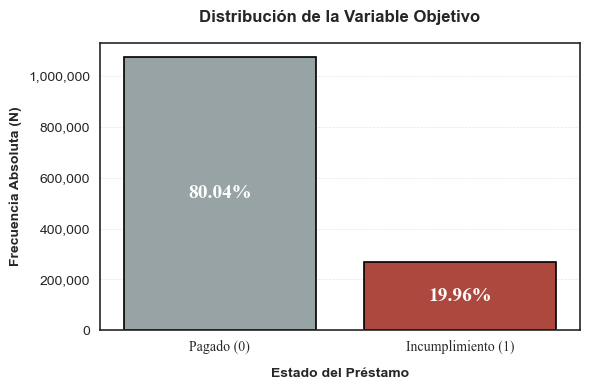

In [16]:
#| code-fold: true
#| code-summary: "Mostrar código"

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

fig, ax = plt.subplots(figsize=(6, 4))

colores_paper = ["#95a5a6", "#c0392b"]
ax = sns.barplot(
    x='default', 
    y='count', 
    data=distribucion, 
    hue='default',
    palette=colores_paper,
    edgecolor='black',
    linewidth=1.2,
    legend=False
)

total = distribucion['count'].sum()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.2f}%', 
                    (p.get_x() + p.get_width() / 2., height / 2.), 
                    ha='center', va='center', 
                    fontsize=14, 
                    color='white', 
                    fontweight='bold',
                    family='serif')

ax.set_title('Distribución de la Variable Objetivo', fontsize=12, pad=15, weight='bold')
ax.set_xlabel('Estado del Préstamo', fontsize=10, weight='bold', labelpad=10)
ax.set_ylabel('Frecuencia Absoluta (N)', fontsize=10, weight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Pagado (0)', 'Incumplimiento (1)'], family='serif')

ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

for spine in ax.spines.values():
    spine.set_visible(True)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)

plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
data = base64.b64encode(buf.getbuffer()).decode("ascii")

display(HTML(f"""
<div style="text-align: center; width: 100%;">
    <img src="data:image/png;base64,{data}">
</div>
"""))

### 2.3. Tipos de Datos y Valores Faltantes

La integridad del dataset es una condición necesaria para la validez de las inferencias. En esta etapa, identificamos la naturaleza técnica de los atributos y la densidad de información mediante el cálculo de valores nulos. Este diagnóstico permite diferenciar entre variables con alta fidelidad y aquellas cuya representatividad está comprometida por la ausencia masiva de datos.

Antes de proceder con la visualización, es imperativo clasificar la naturaleza técnica de los atributos. Esta distinción define la hoja de ruta del preprocesamiento, separando los flujos de imputación y codificación según la estructura de la variable.

In [17]:
#| code-fold: true
#| code-summary: "Mostrar código"

column_types = df.dtypes
type_groups = {}

for col_name, dtype in column_types:
    type_groups[dtype] = type_groups.get(dtype, []) + [col_name]
    
resumen_tipos = pd.DataFrame([
    {
        'Tipo de Dato': t, 
        'Cantidad': len(cols), 
        'Ejemplos': ", ".join(cols[:3]) + "..."
    }
    for t, cols in type_groups.items()
])

styled_types = resumen_tipos.style.hide(axis='index')

styled_types = styled_types.set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('border', '1px solid black'), ('padding', '10px')]}
])

styled_types = styled_types.set_properties(subset=['Tipo de Dato'], **{'text-align': 'left'})
styled_types = styled_types.set_properties(subset=['Cantidad', 'Ejemplos'], **{'text-align': 'center'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_types.to_html() + "</div>"))

Tipo de Dato,Cantidad,Ejemplos
string,97,"id, member_id, term..."
double,53,"loan_amnt, funded_amnt, funded_amnt_inv..."
int,1,default...


El dataset presenta una composición híbrida, con un predominio de variables de tipo double (indicadores financieros y puntajes crediticios) y string (atributos categóricos y descriptores de perfil). Esta diversidad técnica confirma la necesidad de un Pipeline robusto que sea capaz de gestionar transformaciones diferenciadas, un punto que será evaluado comparativamente entre las implementaciones de Scikit-Learn y PySpark.

### 2.4. Mapa de Densidad de Información (Missingness Map)

Una vez determinada la naturaleza técnica de los atributos, es fundamental mapear la distribución espacial de los vacíos de información. Este análisis no solo cuantifica la ausencia de datos, sino que permite identificar patrones sistemáticos de *missingness* que podrían comprometer la representatividad de la muestra.

#### 2.4.1.Justificación del Muestreo Estocástico

Dada la escala masiva del dataset original ($N \approx 1.3M$ registros), la generación de una matriz de visualización completa es computacionalmente ineficiente y visualmente saturada, superando los límites de renderizado de los entornos de visualización estándar. Por tanto, se ha extraído una **submuestra aleatoria simple** ($n \approx 6,500$ registros, equivalente al $0.5\%$ del total).

Esta aproximación es estadísticamente adecuada por tres razones fundamentales:

* **Representatividad Probabilística:** Bajo el amparo de la **Ley de los Grandes Números**, una muestra aleatoria de este tamaño es suficiente para capturar la estructura de nulidad de la población con un margen de error mínimo, manteniendo la integridad del diagnóstico.
  
* **Resolución Visual:** A nivel de píxeles, una muestra de $6,500$ filas permite una inspección detallada de las "franjas" de nulidad, evitando que la imagen se convierta en un bloque sólido ilegible y permitiendo identificar variables con falta de datos sistémica.

  
* **Eficiencia en el Driver:** Al reducir el volumen de datos transferidos desde el clúster de Spark hacia la memoria local del *driver* (Pandas), se garantiza la fluidez del entorno de trabajo y la estabilidad del sistema sin sacrificar la calidad de la auditoría.

A continuación, se presenta la visualización diseñada para diagnosticar la concentración de nulos a través de todo el espectro de variables.

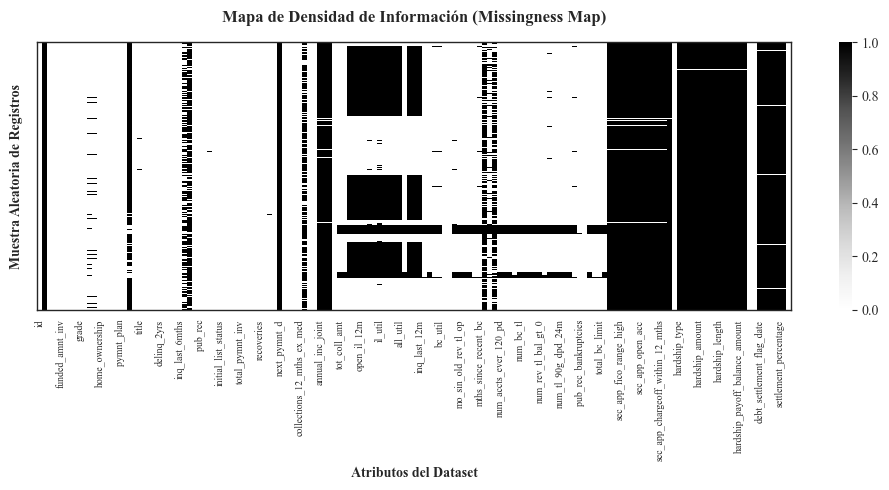

In [33]:
#| code-fold: true
#| code-summary: "Mostrar código"

sample_df = df.sample(withReplacement=False, fraction=0.005, seed=42).toPandas()

plt.figure(figsize=(10, 5))
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})

ax = sns.heatmap(sample_df.isnull(), 
                 yticklabels=False, 
                 cbar=True, 
                 cmap='Greys', 
                 edgecolor=None)

plt.title('Mapa de Densidad de Información (Missingness Map)', 
          fontsize=12, pad=15, weight='bold')

plt.xlabel('Atributos del Dataset', fontsize=10, weight='bold')
ax.set_ylabel('Muestra Aleatoria de Registros', fontsize=10, weight='bold', labelpad=10)

plt.xticks(rotation=90, fontsize=7)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

El mapa de datos faltantes revela una arquitectura de datos con alta densidad de completitud. Sin embargo, la presencia de franjas verticales oscuras fuertemente delimitadas indica que la pérdida de información no obedece a un mecanismo aleatorio puro, sino a un patrón estructural (*Missing Not At Random*). Esta concentración de nulos en atributos específicos refleja contingencias operativas de la plataforma, tales como campos opcionales en los formularios de originación de crédito o variables incorporadas en versiones recientes del sistema.

Basado en el diagnóstico espacial del *Missingness Map*, se hace imperativo establecer un criterio de corte para la retención de atributos. Se ha definido un **umbral de exclusión estricto del $>50\%$** de valores faltantes. 

En la práctica, incluso las técnicas de imputación iterativa más robustas —como el *Predictive Mean Matching (PMM)* o la imputación múltiple por ecuaciones encadenadas (**MICE**)— operan bajo el supuesto condicional de que la porción observada posee la densidad estocástica suficiente para modelar la distribución subyacente de la variable. 

Cuando la ausencia de información supera el 50-60%, este supuesto colapsa. En métodos como PMM, la "piscina de donantes" (observaciones reales utilizadas para emparejar y rellenar nulos) se vuelve minoritaria. Obligar al algoritmo a imputar bajo estas condiciones de escasez equivale a *sintetizar artificialmente la mayor parte de la distribución*, lo que genera consecuencias matemáticas perjudiciales:

1.  **Inflación de la Varianza Inter-Imputación:** Al tener que reciclar iterativamente un conjunto muy limitado de valores observados para rellenar la mayoría de la muestra, la incertidumbre del dato imputado supera el valor de la señal original.
   
2.  **Inyección de Sesgo Estructural:** Forzar el emparejamiento predictivo (PMM) sobre variables con nulidad mayoritaria introduce relaciones espurias. El algoritmo de *Machine Learning* aprenderá estas correlaciones como "señales financieras", cuando en realidad son ruido sintético amplificado por el propio diseño de la imputación.

Por el principio de parsimonia y preservación de la señal, estas variables deben ser excluidas del espacio de características antes de continuar con la fase de preprocesamiento y modelado.

In [14]:
null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in df.columns
]).toPandas().transpose()

null_counts.columns = ['null_count']
null_counts['null_percentage'] = (null_counts['null_count'] / df.count()) * 100
missing_data_summary = null_counts.sort_values(by='null_percentage', ascending=False)
cols_to_drop = missing_data_summary[missing_data_summary['null_percentage'] > 50.0].index.tolist()

df_clean = df.drop(*cols_to_drop)

### 2.5. Análisis de Atributos Categóricos

Tras depurar el espacio dimensional general, procedemos a la evaluación específica de los atributos cualitativos (cadenas de texto o *strings*). En el modelado de riesgo crediticio, las variables categóricas (como el propósito del crédito o la situación laboral) suelen contener alta capacidad discriminante, pero son altamente susceptibles a errores de digitación u omisiones en el formulario de solicitud.

El primer paso consiste en cuantificar la pérdida de información. Para optimizar la lectura del reporte y aplicar el principio de parsimonia visual, el siguiente diagnóstico aísla y presenta **exclusivamente aquellos atributos categóricos que presentan algún grado de nulidad**. Se han considerado como "faltantes" no solo los valores estandarizados como `NULL`, sino también las cadenas vacías y los strings tipificados como `"NaN"`.

In [23]:
#| code-fold: true
#| code-summary: "Mostrar código"

string_cols = [c for c, dtype in df_clean.dtypes if dtype == 'string']

null_counts_string = df_clean.select([
    F.count(F.when(F.col(c).isNull() | (F.col(c) == "") | (F.col(c) == "NaN"), c)).alias(c) 
    for c in string_cols
]).toPandas().transpose()

total_rows = df_clean.count()
null_counts_string.columns = ['Frecuencia']
null_counts_string['Porcentaje'] = (null_counts_string['Frecuencia'] / total_rows) * 100

missing_report = null_counts_string[null_counts_string['Frecuencia'] > 0].copy()
missing_report = missing_report.sort_values(by='Porcentaje', ascending=False)
missing_report.index.name = 'Atributo'
missing_report = missing_report.reset_index()

n_vars = len(missing_report)
mid_idx = (n_vars + 1) // 2

df_left = missing_report.iloc[:mid_idx].reset_index(drop=True)
df_right = missing_report.iloc[mid_idx:].reset_index(drop=True)

if len(df_right) < len(df_left):
    for i in range(len(df_right), len(df_left)):
        df_right.loc[i] = ["", np.nan, np.nan]

df_left.columns = ['Atributo', 'Frecuencia (N)', 'Nulidad (%)']
df_right.columns = ['Atributo (cont.)', 'Frecuencia (N) (cont.)', 'Nulidad (%) (cont.)']

dual_report = pd.concat([df_left, df_right], axis=1)

formatters = {
    'Frecuencia (N)': lambda x: "{:,.0f}".format(x) if pd.notnull(x) and x != "" else "",
    'Nulidad (%)': lambda x: "{:.2f}%".format(x) if pd.notnull(x) and x != "" else "",
    'Frecuencia (N) (cont.)': lambda x: "{:,.0f}".format(x) if pd.notnull(x) and x != "" else "",
    'Nulidad (%) (cont.)': lambda x: "{:.2f}%".format(x) if pd.notnull(x) and x != "" else ""
}

styled_dual = dual_report.style.format(formatters).hide(axis='index')

styled_dual = styled_dual.set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), ('padding', '6px 12px')]}
])

styled_dual = styled_dual.set_properties(subset=['Atributo', 'Atributo (cont.)'], **{'text-align': 'left'})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dual.to_html() + "</div>"))

Atributo,Frecuencia (N),Nulidad (%),Atributo (cont.),Frecuencia (N) (cont.),Nulidad (%) (cont.)
emp_title,"85,785",6.38%,last_fico_range_high,43,0.00%
emp_length,"78,511",5.84%,last_fico_range_low,35,0.00%
avg_cur_bal,"67,546",5.02%,out_prncp_inv,21,0.00%
total_rev_hi_lim,"67,522",5.02%,total_acc,17,0.00%
tot_cur_bal,"67,433",5.01%,out_prncp,15,0.00%
tot_coll_amt,"67,410",5.01%,initial_list_status,14,0.00%
bc_util,"61,912",4.60%,total_pymnt,12,0.00%
title,"16,660",1.24%,total_pymnt_inv,10,0.00%
last_pymnt_d,"2,320",0.17%,total_rec_prncp,9,0.00%
revol_util,886,0.07%,collection_recovery_fee,5,0.00%


Durante la auditoría de atributos categóricos, se ha detectado una anomalía estructural: diversas variables que conceptualmente representan magnitudes continuas o discretas (tales como saldos de cuenta, límites de crédito, ratios financieros y puntajes FICO) han sido inferidas por el esquema original como cadenas de texto (`string`).

Este fenómeno suele ocurrir cuando la ingesta de datos preserva caracteres de formato (como símbolos de porcentaje, monedas o separadores de miles) o cuando existen valores atípicos mal tipados. 

Para determinar si es metodológicamente correcto forzar una conversión (casteo) a un formato numérico nativo (`DoubleType` o `IntegerType`), es imperativo realizar una inspección directa sobre los datos crudos. Esto nos permitirá confirmar si basta con un casteo directo o si es necesaria una limpieza previa mediante expresiones regulares (RegEx).

In [6]:
#| code-fold: true
#| code-summary: "Mostrar código"

investigation_cols = [
    'revol_bal', 'total_rev_hi_lim', 'tot_coll_amt', 'avg_cur_bal', 
    'tot_cur_bal', 'revol_util', 'dti', 'bc_util', 'total_acc', 
    'open_acc', 'fico_range_low', 'fico_range_high', 'annual_inc'
]

df_inspection = df_clean.select(investigation_cols).limit(12).toPandas()
styled_inspection = df_inspection.style.format(safe_format).hide(axis='index')

styled_inspection = styled_inspection.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse'),
        ('font-size', '11px')
    ]},

    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '8px 10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'),
        ('border', '1px solid black'), 
        ('padding', '6px 10px'),
        ('background-color', 'white')
    ]}
])

display(HTML("<div style='text-align: center; width: 100%; overflow-x: auto;'>" + styled_inspection.to_html() + "</div>"))

revol_bal,total_rev_hi_lim,tot_coll_amt,avg_cur_bal,tot_cur_bal,revol_util,dti,bc_util,total_acc,open_acc,fico_range_low,fico_range_high,annual_inc
2765.0,9300.0,722.0,20701.0,144904.0,29.7,5.91,37.2,13.0,7.0,675.0,679.0,55000.0
21470.0,111800.0,0.0,9733.0,204396.0,19.2,16.06,27.1,38.0,22.0,715.0,719.0,65000.0
7869.0,14000.0,0.0,31617.0,189699.0,56.2,10.78,55.9,18.0,6.0,695.0,699.0,63000.0
21929.0,34000.0,0.0,27644.0,331730.0,64.5,25.37,77.5,35.0,12.0,695.0,699.0,104433.0
8822.0,12900.0,0.0,2560.0,12798.0,68.4,10.2,91.0,6.0,5.0,690.0,694.0,34000.0
87329.0,94200.0,0.0,30030.0,360358.0,84.5,14.67,102.9,27.0,12.0,680.0,684.0,180000.0
826.0,14500.0,0.0,17700.0,141601.0,5.7,17.61,5.7,15.0,8.0,705.0,709.0,85000.0
10464.0,30300.0,8341.0,1997.0,27957.0,34.5,13.07,50.1,23.0,14.0,685.0,689.0,85000.0
7034.0,18000.0,0.0,28528.0,199696.0,39.1,34.8,41.4,18.0,8.0,700.0,704.0,42000.0
37828.0,56300.0,0.0,19159.0,325695.0,67.2,34.95,77.0,24.0,17.0,700.0,704.0,64000.0


La inspección previa corroboró que múltiples variables con semántica cuantitativa (como saldos, límites de crédito y puntajes de riesgo) estaban tipificadas como cadenas de texto. Esta anomalía sintáctica bloquea el cálculo de medidas de dispersión, tendencia central y la posterior normalización requerida por los algoritmos de aprendizaje automático.

Para resolver esto, se aplica una rutina de transformación sistemática (`fix_all_numeric_types`) diseñada para parsear los caracteres, limpiar posibles artefactos de formato y proyectar las variables hacia su dominio matemático natural (`DoubleType` o `IntegerType`). A continuación, se ejecuta el casteo y se audita el resultado sobre el subconjunto bajo sospecha.

In [16]:
df_clean = fix_all_numeric_types(df_clean, investigation_cols)

La inspección detallada de las variables en la fase anterior no solo resolvió anomalías sintácticas de casteo, sino que también reveló una irregularidad metodológica crítica: la presencia de múltiples atributos que capturan eventos ocurridos estrictamente *después* del momento de la toma de decisión (el instante de la solicitud o $t_0$). 

En el diseño riguroso de modelos predictivos, incluir este tipo de información genera una grave **contaminación retrospectiva** (o endogeneidad predictiva). Si el algoritmo se entrena con variables que reflejan el futuro de la cuenta, exhibirá métricas de desempeño artificialmente perfectas en la fase de validación, pero colapsará inevitablemente en producción, dado que requeriría conocer de antemano el comportamiento del cliente para poder evaluar su riesgo.

Para garantizar la integridad y viabilidad operativa del modelo, se han purgado del espacio de características todas aquellas variables que constituyen una tautología matemática o que rompen la simetría temporal del crédito. Esta exclusión abarca tres dimensiones fundamentales:
* **Indicadores ex-post de incumplimiento** (como `recoveries` y `collection_recovery_fee`), los cuales adquieren valores mayores a cero exclusivamente después de que el cliente ha entrado en *default*. 
* **Métricas de flujo de caja acumulado** (como `total_pymnt`, `total_rec_prncp`, `total_rec_int` y `last_pymnt_amnt`), que representan el resultado financiero real del préstamo a lo largo del tiempo.
* **Actualizaciones de estado longitudinales** (como saldos pendientes en `out_prncp`, fechas futuras en `next_pymnt_d`, o actualizaciones de puntaje de crédito posteriores a la originación en `last_fico_range_high`). 

En el momento cero ($t_0$), la entidad financiera solo dispone de una fotografía estática del perfil del solicitante, y el modelo debe restringirse estrictamente a esa realidad observacional.

In [17]:
leakage_cols = [
    'recoveries', 'collection_recovery_fee', 
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 
    'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt', 
    'last_pymnt_d', 'next_pymnt_d',
    'out_prncp', 'out_prncp_inv',
    'last_fico_range_high', 'last_fico_range_low', 'last_credit_pull_d'
]

df_clean = df_clean.drop(*leakage_cols)

#### 2.5.1 Análisis de Dimensionalidad Interna: Ratio de Cardinalidad

En el procesamiento de atributos categóricos, la alta cardinalidad representa un desafío estructural agudo. Un exceso de niveles únicos diluye el poder predictivo de la variable, fragmenta el espacio muestral y puede inducir a un sobreajuste severo durante el entrenamiento.

Para cuantificar este fenómeno, calculamos el **Ratio de Cardinalidad ($CR$)**, el cual mide la proporción de valores únicos frente al volumen total de la muestra. La formalización matemática se define como:

$$CR(X) = \frac{|U_X|}{N} \times 100$$

Donde:
* $|U_X|$ representa la cardinalidad (cantidad de elementos únicos) del conjunto de valores para el atributo $X$.
* $N$ es el tamaño total de la muestra (número total de registros válidos).

Un $CR \approx 100\%$ indica de manera inequívoca que la variable actúa como un identificador único o llave primaria (clave subrogada), por lo que carece por completo de capacidad de generalización algorítmica. Por otro lado, valores intermedios-altos (ej. $5\% - 20\%$) en variables de texto sugieren campos de entrada libre que requerirían técnicas avanzadas de Procesamiento de Lenguaje Natural (NLP) o agrupamiento semántico para ser útiles.

In [41]:
#| code-fold: true
#| code-summary: "Mostrar código"

high_card_cols = ['id', 'emp_title', 'title', 'zip_code']
total_rows = df_clean.count()

exprs = [F.countDistinct(c).alias(c) for c in high_card_cols]
unique_counts = df_clean.select(*exprs).collect()[0].asDict()

cardinality_data = []
for col, u_count in unique_counts.items():
    ratio = (u_count / total_rows) * 100
    cardinality_data.append({
        'Atributo': col, 
        'Valores Únicos': u_count, 
        'Ratio de Cardinalidad (CR %)': ratio
    })

df_cardinality = pd.DataFrame(cardinality_data).sort_values(by='Ratio de Cardinalidad (CR %)', ascending=False)
styled_cardinality = df_cardinality.style.format({
    'Valores Únicos': '{:,.0f}',
    'Ratio de Cardinalidad (CR %)': '{:.2f}%'
}).hide(axis='index')

styled_cardinality = styled_cardinality.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '6px 12px')
    ]}
])

styled_cardinality = styled_cardinality.set_properties(subset=['Atributo'], **{'text-align': 'left'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_cardinality.to_html() + "</div>"))

Atributo,Valores Únicos,Ratio de Cardinalidad (CR %)
id,"1,345,309",100.00%
emp_title,"378,352",28.12%
title,"61,690",4.59%
zip_code,"1,136",0.08%


El análisis del Ratio de Cardinalidad ($CR$) revela dos perfiles distintos de variables que requieren tratamientos metodológicos diferenciados en la construcción del espacio de características:

* **Claves Subrogadas ($CR = 100\%$):** El atributo `id` constituye un identificador único incremental. Al carecer de varianza compartida, su retención induciría al modelo a memorizar instancias (sobreajuste extremo) sin aportar capacidad de generalización.
  
* **Atributos de Alta Densidad Semántica ($CR$ Intermedio-Alto):** Variables como `emp_title` ($\approx 28\%$) y `title` ($\approx 4.5\%$) presentan una fragmentación masiva debido a su formato de texto libre. Aunque esta dispersión imposibilita el uso de codificaciones tradicionales (como *One-Hot Encoding*), contienen información predictiva de alto valor sobre el estatus socioeconómico y la intención de gasto del solicitante.

Para determinar la viabilidad de rescatar información de las variables `emp_title` (Cargo Laboral) y `title` (Motivo del Préstamo), es necesario evaluar su nivel de concentración. En distribuciones altamente fragmentadas, es común observar un comportamiento de **ley de potencias (distribución de Pareto)**, donde un subconjunto reducido de categorías agrupa una porción estadísticamente significativa de la muestra.

A continuación, se visualiza la proporción relativa de los 20 niveles más frecuentes respecto al volumen total del dataset. Este diagnóstico visual dictará si es factible aplicar técnicas de agrupamiento semántico sobre las categorías dominantes o si la dispersión es demasiado severa.

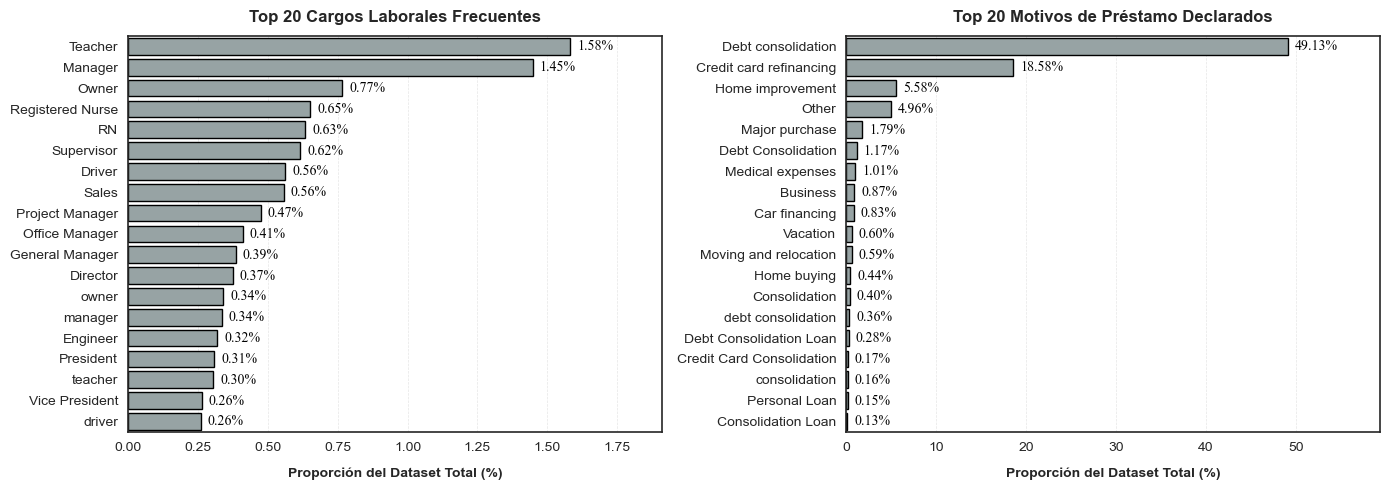

In [43]:
#| code-fold: true
#| code-summary: "Mostrar código"

total_rows = df_clean.count()

top_emp_titles = df_clean.groupby("emp_title").count().sort(F.col("count").desc()).limit(20).toPandas()
top_titles = df_clean.groupby("title").count().sort(F.col("count").desc()).limit(20).toPandas()

top_emp_titles['percentage'] = (top_emp_titles['count'] / total_rows) * 100
top_titles['percentage'] = (top_titles['count'] / total_rows) * 100

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_barras = "#95a5a6"

sns.barplot(data=top_emp_titles, x='percentage', y='emp_title', ax=axes[0], 
            color=color_barras, edgecolor='black', linewidth=1)
axes[0].set_title('Top 20 Cargos Laborales Frecuentes', fontsize=12, weight='bold', pad=10)
axes[0].set_xlabel('Proporción del Dataset Total (%)', fontsize=10, weight='bold', labelpad = 10)
axes[0].set_ylabel('')

sns.barplot(data=top_titles, x='percentage', y='title', ax=axes[1], 
            color=color_barras, edgecolor='black', linewidth=1)
axes[1].set_title('Top 20 Motivos de Préstamo Declarados', fontsize=12, weight='bold', pad=10)
axes[1].set_xlabel('Proporción del Dataset Total (%)', fontsize=10, weight='bold', labelpad = 10)
axes[1].set_ylabel('')

for ax in axes:
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{width:.2f}%', 
                        (width, p.get_y() + p.get_height() / 2.), 
                        ha='left', va='center', 
                        fontsize=10, color='black', 
                        xytext=(5, 0), textcoords='offset points',
                        family='serif')
            
    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)

plt.tight_layout()
plt.show()

La visualización de las distribuciones de cola larga (*Long Tail*) revela dos comportamientos diametralmente opuestos que exigen decisiones de arquitectura de datos distintas:

* **Fragmentación Extrema (Ruido Categórico):** En el atributo `emp_title`, la categoría modal ("Teacher") representa únicamente el $1.58\%$ del volumen total. Esta dispersión masiva confirma que la variable posee una entropía demasiado elevada. Intentar vectorizarla introduciría una dispersión dimensional (*Sparsity*) inmanejable para los algoritmos, por lo que se procede a su eliminación definitiva.
  
* **Concentración de Pareto (Señal Predictiva):** Por el contrario, la variable `title` exhibe una concentración asimétrica donde casi el $70\%$ de la cartera se explica por solo dos motivos: Consolidación de Deuda ($\approx 49.1\%$) y Refinanciamiento de Tarjetas de Crédito ($\approx 18.6\%$). 

Dados estos resultados, y sumando el diagnóstico previo de cardinalidad, las variables `id` (clave subrogada), `zip_code` (ruido geográfico local) y `emp_title` serán excluidas del dataset para evitar la inyección de entropía en el modelo. Por el contrario, en lugar de excluir la variable `title`, se aplicará una técnica de **Agrupamiento Semántico**. Transformaremos esta variable de alta cardinalidad en un atributo categórico compacto de tres niveles (Tricotomía): *Debt Consolidation*, *Credit Card Refinancing*, y *Other*. Esto rescata la señal macroeconómica del préstamo eliminando el ruido de las colas.

In [18]:
cols_to_drop_cardinality = ['id', 'zip_code', 'emp_title']
df_clean = df_clean.drop(*cols_to_drop_cardinality)

df_clean = df_clean.withColumn(
    'title_grouped',
    F.when(F.lower(F.col('title')).like('%debt consolidation%'), 'Debt Consolidation')
    .when(F.lower(F.col('title')).like('%credit card%'), 'Credit Card Refinancing')
    .otherwise('Other')
)

df_clean = df_clean.drop('title')

#### 2.5.2 Análisis de Varianza Categórica

Para concluir el diagnóstico de los atributos cualitativos, evaluamos el grado de concentración o desequilibrio en sus clases. En el aprendizaje automático, una característica (*feature*) requiere una varianza mínima para aportar capacidad discriminante. Si una proporción abrumadora de la muestra (ej. **> 95%**) pertenece a un único nivel o categoría, la variable se considera **cuasi-constante**. 

Retener atributos cuasi-constantes aumenta innecesariamente la complejidad dimensional del modelo sin mejorar el ajuste, y en modelos lineales, puede inducir problemas de colinealidad. A continuación, se calcula la frecuencia de la clase dominante (moda) para cada variable, utilizando un proceso distribuido de *unpivoting* (apilamiento) para optimizar el cómputo en PySpark.

In [49]:
#| code-fold: true
#| code-summary: "Mostrar código"

total_rows = df_clean.count()
cols = [
    'emp_length', 'disbursement_method', 'hardship_flag', 'debt_settlement_flag',
    'acc_now_delinq', 'collections_12_mths_ex_med', 'policy_code', 'pub_rec',
    'application_type', 'initial_list_status', 'inq_last_6mths', 'earliest_cr_line',
    'delinq_2yrs', 'addr_state', 'grade', 'purpose', 'title_grouped', 'pymnt_plan', 'loan_status',
    'issue_d', 'verification_status', 'home_ownership', 'sub_grade', 'term'
]

cols = [c for c in cols if c in df_clean.columns]
cardinality_agg = df_clean.agg(*(F.countDistinct(c).alias(c) for c in cols)).collect()[0].asDict()
stack_expr = ", ".join([f"'{c}', CAST({c} AS STRING)" for c in cols])
melted_df = df_clean.select(F.expr(f"stack({len(cols)}, {stack_expr}) as (Variable, Value)"))

frequencies = melted_df.groupBy("Variable", "Value").count()
window_spec = Window.partitionBy("Variable").orderBy(F.desc("count"))

top_classes = frequencies.withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") == 1) \
    .select("Variable", F.col("Value").alias("Dominant_Class"), F.col("count").alias("Max_Count")) \
    .toPandas()

top_classes['N_Classes'] = top_classes['Variable'].map(cardinality_agg)
top_classes['Max_Proportion_%'] = (top_classes['Max_Count'] / total_rows) * 100
variability_report = top_classes[['Variable', 'N_Classes', 'Dominant_Class', 'Max_Proportion_%']] \
    .sort_values(by='Max_Proportion_%', ascending=False) \
    .reset_index(drop=True)

n_vars = len(variability_report)
mid_idx = (n_vars + 1) // 2

df_left = variability_report.iloc[:mid_idx].reset_index(drop=True)
df_right = variability_report.iloc[mid_idx:].reset_index(drop=True)
if len(df_right) < len(df_left):
    for i in range(len(df_right), len(df_left)):
        df_right.loc[i] = ["", np.nan, "", np.nan]

df_left.columns = ['Atributo', 'Clases (N)', 'Clase Modal', 'Concentración (%)']
df_right.columns = ['Atributo ', 'Clases (N) ', 'Clase Modal ', 'Concentración (%) ']

dual_report = pd.concat([df_left, df_right], axis=1)

formatters = {
    'Clases (N)': lambda x: "{:,.0f}".format(x) if pd.notnull(x) and x != "" else "",
    'Concentración (%)': lambda x: "{:.2f}%".format(x) if pd.notnull(x) and x != "" else "",
    'Clases (N) ': lambda x: "{:,.0f}".format(x) if pd.notnull(x) and x != "" else "",
    'Concentración (%) ': lambda x: "{:.2f}%".format(x) if pd.notnull(x) and x != "" else ""
}

styled_dual = dual_report.style.format(formatters).hide(axis='index')
styled_dual = styled_dual.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse'),
        ('font-size', '12px')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '6px 12px'),
        ('background-color', 'white')
    ]}
])

text_cols = ['Atributo', 'Clase Modal', 'Atributo ', 'Clase Modal ']
styled_dual = styled_dual.set_properties(subset=text_cols, **{'text-align': 'left'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dual.to_html() + "</div>"))

Atributo,Clases (N),Clase Modal,Concentración (%),Atributo,Clases (N),Clase Modal,Concentración (%)
pymnt_plan,1,n,100.00%,purpose,239,debt_consolidation,58.00%
policy_code,82,1.0,99.98%,inq_last_6mths,156,0.0,57.26%
hardship_flag,2,N,99.98%,title_grouped,3,Debt Consolidation,51.46%
acc_now_delinq,43,0.0,99.51%,home_ownership,6,MORTGAGE,49.47%
disbursement_method,2,Cash,99.47%,verification_status,3,Source Verified,38.75%
collections_12_mths_ex_med,142,0.0,98.42%,emp_length,11,10+ years,32.87%
application_type,69,Individual,98.07%,grade,7,B,29.19%
debt_settlement_flag,3,N,97.51%,addr_state,248,CA,14.60%
pub_rec,104,0.0,83.05%,sub_grade,35,C1,6.35%
delinq_2yrs,219,0.0,80.71%,issue_d,139,Mar-2016,3.64%


El diagnóstico previo de concentración revela un subconjunto de variables (como `pymnt_plan`, `hardship_flag` y `policy_code`) que exhiben un desequilibrio extremo, con clases modales que superan el $97\%$ de la muestra. Al comportarse como atributos cuasi-constantes sin varianza útil, se procederá a su exclusión inmediata del espacio de características.

No obstante, la tabla de frecuencias también expone dos pares de atributos que sugieren una **redundancia jerárquica** directa:
1.  `grade` y `sub_grade` (Calificaciones de riesgo macro y micro).
2.  `purpose` y `title_grouped` (Motivo del crédito original vs. agrupado).

La hipótesis analítica es que estos pares representan recategorizaciones exactas de la misma dimensión latente. Dado que la arquitectura de modelado contemplará algoritmos basados en árboles (particiones recursivas), la colinealidad no representa un impedimento matemático. Sin embargo, retener información duplicada viola el principio de parsimonia. Mantener redundancias incrementa innecesariamente la complejidad dimensional y diluye la interpretabilidad algorítmica, ya que el modelo alternará los cortes (*splits*) entre atributos idénticos, fragmentando el cálculo de la Importancia de las Variables (*Feature Importance*). 

#### 2.5.3. Diagnóstico de Redundancia Jerárquica

Para comprobar la hipótesis de solapamiento estructural entre los pares de atributos  (`grade` vs `sub_grade` y `purpose` vs `title_grouped`), se emplea un enfoque dual:

- **Mapas de calor (heatmaps)**
- **Pruebas de independencia $\chi^2$**

Este diagnóstico permite identificar si las categorías de una variable están anidadas perfectamente dentro de otra.

Siguiendo el Principio de Parsimonia, si se confirma una dependencia extrema, mantener ambas variables podría introducir redundancia estructural o bien fragmentar innecesariamente la importancia de las características (*feature importance*) en modelos basados en árboles.

Por lo tanto, la visualización y el resultado de las pruebas analíticas servirán para justificar la exclusión del atributo con menor nivel de granularidad o relevancia informativa.


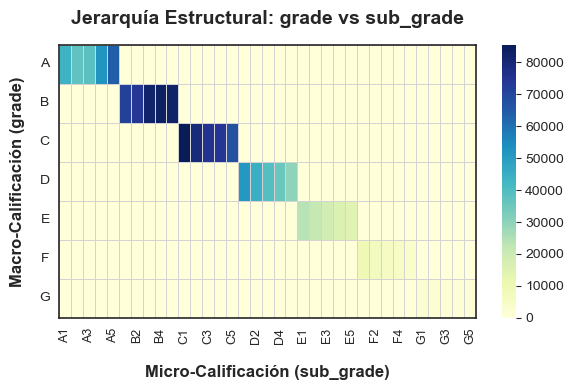

In [51]:
#| code-fold: true
#| code-summary: "Mostrar código"

xtab_grade = df_clean.crosstab('grade', 'sub_grade').toPandas()
xtab_grade = xtab_grade.set_index('grade_sub_grade')
xtab_grade = xtab_grade.sort_index()
xtab_grade = xtab_grade[sorted(xtab_grade.columns)] 

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(xtab_grade, ax=ax, annot=False, cmap="YlGnBu", cbar=True,
            linewidths=0.5, linecolor='lightgray')

ax.set_title('Jerarquía Estructural: grade vs sub_grade', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Micro-Calificación (sub_grade)', fontsize=12, weight='bold', labelpad=15)
ax.set_ylabel('Macro-Calificación (grade)', fontsize=12, weight='bold', labelpad=10)

ax.tick_params(axis='x', rotation=90, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=10)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
data = base64.b64encode(buf.getbuffer()).decode("ascii")

display(HTML(f"""
<div style="text-align: center; width: 100%;">
    <img src="data:image/png;base64,{data}">
</div>
"""))

La inspección visual del mapa de calor para el par `grade` vs `sub_grade` ha proporcionado evidencia preliminar de una estructura jerárquica casi perfecta. No obstante, para dotar al análisis de rigor estadístico formal y evaluar también la relación en el par `purpose` vs `title_grouped`, se procede con la ejecución de pruebas inferenciales de independencia $\chi^2$ (Chi-cuadrado) de Pearson.

Para ambos pares de variables se definen las siguientes hipótesis:

- **Hipótesis nula ($H_0$):**  Los atributos son independientes; no existe una relación sistemática entre ellos.

- **Hipótesis alternativa ($H_1$):** Existe una dependencia estadística significativa entre los atributos (redundancia estructural).

Es importante notar que, debido al gran tamaño de la muestra ($N > 1.3 \times 10^6$), el estadístico $\chi^2$ tiende a inflarse, provocando que el p-valor sea extremadamente pequeño ($p < 0.05$) incluso ante asociaciones triviales. En conjuntos de datos masivos, el p-valor pierde fiabilidad como indicador de la importancia real de la relación.

Para corregir este sesgo y cuantificar la magnitud real de la redundancia, se introduce el **tamaño del efecto** mediante la V de Cramér ($V$). Este estadístico normaliza el resultado en un rango $[0,1]$, donde: $0$ indica independencia total y $1$ indica asociación perfecta.

$$
V = \sqrt{\frac{\chi^2}{n \times \min(k-1, r-1)}}
$$

donde:

- $\chi^2$: estadístico de la prueba de Pearson  
- $n$: tamaño total de la muestra  
- $k, r$: número de columnas y filas en la matriz de contingencia, respectivamente

In [54]:
#| code-fold: true
#| code-summary: "Mostrar código"

results = [
    analyze_association(df_clean, "grade", "sub_grade"),
    analyze_association(df_clean, "purpose", "title_grouped")
]


df_results = pd.DataFrame(results)
styled_results = df_results.style.format({
    'Estadístico Chi2': '{:,.2f}',
    'Valor Crítico': '{:,.2f}',
    'V de Cramér': '{:.4f}'
}).hide(axis='index')

styled_results = styled_results.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '8px 12px'),
        ('background-color', 'white')
    ]}
])

styled_results = styled_results.set_properties(
    subset=['Variable', 'Interpretación'], 
    **{'text-align': 'left'}
)

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_results.to_html() + "</div>"))

Variable,Estadístico Chi2,DF,Valor Crítico,V de Cramér,Interpretación,Significancia
grade vs sub_grade,"8,071,854.00",204,238.32,1.0000,Muy Fuerte,***
purpose vs title_grouped,"1,995,173.51",476,527.86,0.8611,Muy Fuerte,***


Los resultados estadísticos confirman una redundancia estructural crítica. Una V de Cramér de $1.0000$ para el par  `grade` vs `sub_grade` indica una asociación perfecta, mientras que el valor de $0.8611$ para `purpose` vs `title_grouped` valida que la señal original está contenida en el agrupamiento.

Bajo el Principio de Parsimonia, se eliminan las variables de menor granularidad (grade y title_grouped), reteniendo las versiones detalladas sugeridas para el análisis: sub_grade y purpose. Esta decisión implica los siguientes desafíos técnicos:

* **Explosión de Dimensionalidad:** Al conservar categorías detalladas (35 para sub_grade y 14 para purpose), la codificación One-Hot Encoding generará un vector de características extenso.
  
* **Gestión de Memoria en Spark:** Con más de 1.3 millones de registros, la creación de columnas dispersas (sparse columns) incrementará la huella de memoria y los tiempos de serialización durante el entrenamiento.
  
* **Compromiso Varianza-Sesgo:** El mayor detalle permite capturar matices de riesgo finos (mayor varianza), pero exige una regularización estricta para evitar el sobreajuste en categorías con baja frecuencia.

In [19]:
low_variance_cols = [
    'pymnt_plan', 'hardship_flag', 'policy_code', 
    'acc_now_delinq', 'disbursement_method', 'collections_12_mths_ex_med', 
    'application_type', 'debt_settlement_flag', 'pub_rec', 
    'delinq_2yrs', 'term', 'title_grouped', 'grade', 'url'
]

df_reduce = df_clean.drop(*low_variance_cols)

Tras eliminar las variables con baja varianza o escasa capacidad informativa, se obtiene un conjunto reducido de características. Esta depuración permite centrar el análisis en las variables categóricas restantes, facilitando una inspección más detallada de sus distribuciones y de las posibles asociaciones que mantienen con otras variables del conjunto de datos.

In [21]:
#| code-fold: true
#| code-summary: "Mostrar código"

descriptions = {
    'url': 'Enlace/Identificador único del perfil del préstamo.',
    'earliest_cr_line': 'Mes y año en que se abrió la primera línea de crédito del solicitante.',
    'addr_state': 'Estado de residencia proporcionado por el solicitante.',
    'purpose': 'Categoría declarada por el solicitante para el uso del préstamo.',
    'inq_last_6mths': 'Número de consultas de crédito en los últimos 6 meses.',
    'initial_list_status': 'Estado inicial del listado del préstamo (Fraccionario o Completo).',
    'issue_d': 'Mes en el que se originó el préstamo.',
    'sub_grade': 'Calificación de riesgo detallada asignada por el prestamista.',
    'emp_length': 'Tiempo de empleo del solicitante en años (0 a 10+).',
    'home_ownership': 'Estado de tenencia de la vivienda (Propia, Hipoteca, Renta, etc.).',
    'verification_status': 'Indica si los ingresos fueron verificados por la plataforma o terceros.'
}

string_cols = [c for c, dtype in df_reduce.dtypes if dtype == 'string']
audit_data = []

for col in string_cols:
    unique_count = df_reduce.select(col).distinct().count()
    null_count = df_reduce.filter(F.col(col).isNull() | (F.col(col) == "")).count()
    null_pct = (null_count / total_rows) * 100
    
    audit_data.append({
        'Atributo': col,
        'Niveles Únicos': unique_count,
        'Nulidad (%)': null_pct,
        'Descripción': descriptions.get(col, 'Sin descripción disponible.')
    })

df_audit_strings = pd.DataFrame(audit_data).sort_values(by='Niveles Únicos', ascending=False)
styled_audit = df_audit_strings.style.format({
    'Niveles Únicos': '{:,.0f}',
    'Nulidad (%)': '{:.2f}%'
}).hide(axis='index')

styled_audit = styled_audit.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    # Celdas con marco negro
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '8px 12px'),
        ('background-color', 'white')
    ]}
])

styled_audit = styled_audit.set_properties(
    subset=['Atributo', 'Descripción'], 
    **{'text-align': 'left'}
)

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_audit.to_html() + "</div>"))

Atributo,Niveles Únicos,Nulidad (%),Descripción
addr_state,51,0.00%,Estado de residencia proporcionado por el solicitante.
sub_grade,35,0.00%,Calificación de riesgo detallada asignada por el prestamista.
purpose,14,0.00%,Categoría declarada por el solicitante para el uso del préstamo.
home_ownership,4,0.00%,"Estado de tenencia de la vivienda (Propia, Hipoteca, Renta, etc.)."
verification_status,3,0.00%,Indica si los ingresos fueron verificados por la plataforma o terceros.
initial_list_status,2,0.00%,Estado inicial del listado del préstamo (Fraccionario o Completo).


#### 2.5.4. Re-tipificación de Atributos e Ingeniería de Características

Tras la auditoría del diccionario de datos, se ejecutan tres acciones correctivas críticas para garantizar la calidad del espacio de características:

1.  **Ingeniería de Antigüedad Crediticia:** Las variables `earliest_cr_line` e `issue_d` se transforman en una única métrica numérica continua: `credit_age_months`. Esta representa la experiencia financiera del solicitante en meses, eliminando la necesidad de procesar cadenas de texto temporales de alta cardinalidad.
2.  **Re-tipificación de Consultas (`inq_last_6mths`):** Se identifica que este atributo representa un conteo discreto de eventos. Se procede a su conversión a formato numérico (`Double`) tras validar su distribución de frecuencias.
3.  **Anomalías de Cardinalidad en initial_list_status**: Se detecta una inconsistencia teórica severa; initial_list_status presenta 144 niveles (cuando debería ser binaria). Esta fragmentación sugiere ruido por errores de entrada de datos o falta de estandarización, lo que requiere una limpieza de cadenas (stripping y case normalization) o una poda por frecuencia.

Para dotar de valor predictivo a las variables temporales, se ha ejecutado un proceso de ingeniería de características que transforma los atributos `earliest_cr_line` e `issue_d` en una única métrica numérica denominada `credit_age_months`. Esta operación calcula la brecha temporal en meses entre la apertura de la primera cuenta del solicitante y la emisión del préstamo, permitiendo que el modelo cuantifique la madurez financiera del perfil.

In [20]:
df_reduce = df_reduce.withColumn(
    "credit_age_months", 
    F.months_between(
        F.to_date(F.col("issue_d"), "MMM-yyyy"), 
        F.to_date(F.col("earliest_cr_line"), "MMM-yyyy")
    ).cast("int")
)

df_reduce = df_reduce.drop("earliest_cr_line", "issue_d")

A continuación, validamos la naturaleza de `inq_last_6mths` para asegurar que el proceso de casteo sea íntegro.

In [63]:
#| code-fold: true
#| code-summary: "Mostrar código"

inq_audit_df = df_reduce.groupBy("inq_last_6mths").count() \
    .withColumn("Porcentaje (%)", (F.col("count") / total_rows) * 100) \
    .sort(F.col("count").desc()) \
    .limit(20) \
    .toPandas()

inq_audit_df.columns = ['Valor', 'Frecuencia (N)', 'Proporción (%)']

n_rows = len(inq_audit_df)
mid_idx = (n_rows + 1) // 2

df_left = inq_audit_df.iloc[:mid_idx].reset_index(drop=True)
df_right = inq_audit_df.iloc[mid_idx:].reset_index(drop=True)

if len(df_right) < len(df_left):
    for i in range(len(df_right), len(df_left)):
        df_right.loc[i] = [None, None, None]

df_left.columns = ['Valor', 'Frecuencia (N)', 'Proporción (%)']
df_right.columns = ['Valor ', 'Frecuencia (N) ', 'Proporción (%) ']

dual_report = pd.concat([df_left, df_right], axis=1)

styled_dual = dual_report.style.format({
    'Valor': safe_format_audit, 'Frecuencia (N)': safe_format_audit, 
    'Proporción (%)': lambda x: "{:.2f}%".format(x) if pd.notnull(x) else "",
    'Valor ': safe_format_audit, 'Frecuencia (N) ': safe_format_audit,
    'Proporción (%) ': lambda x: "{:.2f}%".format(x) if pd.notnull(x) else ""
}).hide(axis='index')

styled_dual = styled_dual.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '6px 12px'), ('background-color', 'white')
    ]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dual.to_html() + "</div>"))

Valor,Frecuencia (N),Proporción (%),Valor,Frecuencia (N),Proporción (%)
0.0,"770,323",57.26%,679.0,4,0.00%
1.0,"366,618",27.25%,739.0,4,0.00%
2.0,"136,759",10.17%,725.0,4,0.00%
3.0,"51,648",3.84%,734.0,4,0.00%
4.0,"13,861",1.03%,705.0,3,0.00%
5.0,"4,887",0.36%,675.0,3,0.00%
6.0,939,0.07%,674.0,3,0.00%
7.0,46,0.00%,744.0,3,0.00%
8.0,23,0.00%,699.0,3,0.00%
704.0,5,0.00%,Feb-1999,3,0.00%


La auditoría de frecuencias para la variable de consultas crediticias revela un fenómeno de contaminación por desplazamiento de campos que, aunque estadísticamente marginal, resulta crítico para la estabilidad de los modelos. Al analizar la distribución, se observa una estructura de riesgo coherente donde el 57% de los registros carece de consultas recientes; sin embargo, esta señal se ve distorsionada por la presencia de valores imposibles superiores a 600 y cadenas de texto temporales como "Feb-1999". Estos errores de ingesta, que apenas afectan al 0.0077% del dataset (103 registros), confirman que datos de otras columnas, como puntajes FICO o fechas de apertura, se filtraron en este atributo durante la lectura masiva del archivo original.

Para blindar el análisis sin comprometer la potencia estadística de la muestra, se ha optado por un casteo coercitivo a entero. Esta técnica transforma de manera inmediata los registros ruidosos en valores nulos ($NaN$), preservando la integridad del 99.99% restante de la información y eliminando el riesgo de que valores absurdos inflen artificialmente las métricas de dispersión. Con esta purga técnica, la variable recupera su naturaleza de conteo discreto, quedando preparada para el análisis paramétrico y el entrenamiento de algoritmos de aprendizaje supervisado bajo un marco de alta fidelidad de datos.

In [21]:
df_reduce = df_reduce.withColumn(
    "inq_last_6mths", 
    F.col("inq_last_6mths").cast(IntegerType())
)

Para abordar la inconsistencia detectada en la variable initial_list_status, es necesario realizar un desglose de frecuencias. Dado que teóricamente esta variable solo debería contener dos niveles (Fraccionario o Completo), la presencia de 144 valores únicos sugiere una fragmentación por ruido o errores de desplazamiento de columnas, similar a lo observado en inq_last_6mths.

A continuación, presentamos el análisis de los 5 casos más frecuentes para identificar la magnitud de la señal frente al ruido.

In [69]:
#| code-fold: true
#| code-summary: "Mostrar código"

total_rows = df_reduce.count()
dist_list_status = df_reduce.groupBy("initial_list_status").count() \
    .withColumn("Porcentaje (%)", (F.col("count") / total_rows) * 100) \
    .sort(F.col("count").desc()) \
    .limit(5) \
    .toPandas()

dist_list_status.columns = ['Valor Detectado', 'Frecuencia Absoluta (N)', 'Porcentaje (%)']

styled_status = dist_list_status.style.format({
    'Frecuencia Absoluta (N)': '{:,.0f}',
    'Porcentaje (%)': '{:.2f}%'
}).hide(axis='index')

styled_status = styled_status.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '8px 12px'),
        ('background-color', 'white')
    ]}
])

styled_status = styled_status.set_properties(
    subset=['Valor Detectado'], 
    **{'text-align': 'left', 'font-weight': 'bold'}
)

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_status.to_html() + "</div>"))

Valor Detectado,Frecuencia Absoluta (N),Porcentaje (%)
w,"784,009",58.28%
f,"561,074",41.71%
0.0,32,0.00%
None,14,0.00%
1.0,5,0.00%


El desglose de frecuencias para la variable de estado inicial del listado confirma que el atributo es, en esencia, de naturaleza binaria. El 58.28% de los registros corresponden al código 'w' y el 41.71% al código 'f', sumando una representatividad conjunta superior al 99.99%. Los 142 niveles restantes identificados en la auditoría inicial corresponden a registros contaminados por errores de ingesta y desplazamientos de columnas que carecen de significancia estadística.

Bajo este diagnóstico, se procede a estandarizar el atributo reclasificando los códigos originales a las etiquetas "Whole" y "Fractional" para mejorar su interpretabilidad. Para garantizar la pureza del espacio de características, cualquier observación que no pertenezca a estos dos dominios —incluyendo valores nulos, numéricos erráticos o cadenas de texto incoherentes— se marca como dato faltante ($NaN$), permitiendo así su tratamiento sistemático durante la fase de imputación en el análisis de variables numéricas.

In [22]:
df_reduce = df_reduce.withColumn(
    "initial_list_status",
    F.when(F.lower(F.trim(F.col("initial_list_status"))) == "w", "Whole")
     .when(F.lower(F.trim(F.col("initial_list_status"))) == "f", "Fractional")
     .otherwise(None)
)

df_reduce = df_reduce.filter(F.col("initial_list_status").isNotNull())

Para cerrar este el tratamiento de la variable `initial_list_status`, visualizaremos la distribución final de initial_list_status. Este gráfico refleja la realidad del negocio tras haber depurado los 142 niveles de ruido, mostrando una división clara entre los préstamos financiados por inversores individuales (Fractional) y los adquiridos en su totalidad por instituciones (Whole).


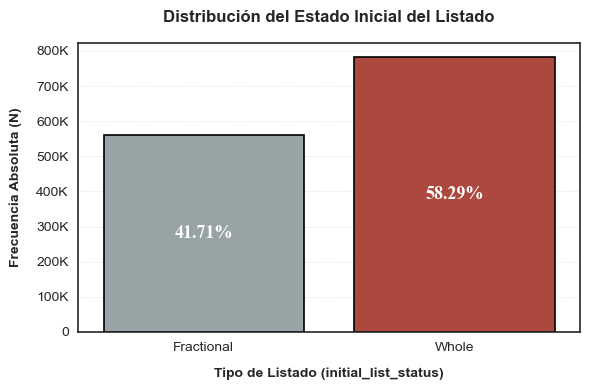

In [71]:
#| code-fold: true
#| code-summary: "Mostrar código"

distribucion = df_reduce.select('initial_list_status').dropna().groupby('initial_list_status').count().toPandas()

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

fig, ax = plt.subplots(figsize=(6, 4))

colores_paper = ["#95a5a6", "#c0392b"]

ax = sns.barplot(
    x='initial_list_status', 
    y='count', 
    data=distribucion, 
    hue='initial_list_status',
    palette=colores_paper,
    edgecolor='black',
    linewidth=1.2,
    legend=False
)

total = distribucion['count'].sum()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.2f}%', 
                    (p.get_x() + p.get_width() / 2., height / 2.), 
                    ha='center', va='center', 
                    fontsize=13, 
                    color='white', 
                    fontweight='bold',
                    family='serif')

ax.set_title('Distribución del Estado Inicial del Listado', fontsize=12, pad=15, weight='bold')
ax.set_xlabel('Tipo de Listado (initial_list_status)', fontsize=10, weight='bold', labelpad=10)
ax.set_ylabel('Frecuencia Absoluta (N)', fontsize=10, weight='bold', labelpad=10)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

for spine in ax.spines.values():
    spine.set_visible(True)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)

plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig) 
data = base64.b64encode(buf.getbuffer()).decode("ascii")

display(HTML(f"""
<div style="text-align: center; width: 100%;">
    <img src="data:image/png;base64,{data}">
</div>
"""))

Ahora se analiza la distribución de la variable `emp_length`:

In [73]:
#| code-fold: true
#| code-summary: "Mostrar código"

total_rows = df_reduce.count()
dist_emp_length = df_reduce.groupBy("emp_length").count() \
    .withColumn("Porcentaje (%)", (F.col("count") / total_rows) * 100) \
    .sort(F.col("count").desc()) \
    .limit(12) \
    .toPandas()

dist_emp_length.columns = ['Valor Detectado', 'Frecuencia Absoluta (N)', 'Porcentaje (%)']

styled_status = dist_emp_length.style.format({
    'Frecuencia Absoluta (N)': '{:,.0f}',
    'Porcentaje (%)': '{:.2f}%'
}).hide(axis='index')

styled_status = styled_status.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '6px 12px'),
        ('background-color', 'white')
    ]}
])

styled_status = styled_status.set_properties(
    subset=['Valor Detectado'], 
    **{'text-align': 'left', 'font-weight': 'bold'}
)

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_status.to_html() + "</div>"))

Valor Detectado,Frecuencia Absoluta (N),Porcentaje (%)
10+ years,"442,164",32.87%
2 years,"121,712",9.05%
< 1 year,"108,025",8.03%
3 years,"107,573",8.00%
1 year,"88,465",6.58%
5 years,"84,137",6.26%
4 years,"80,529",5.99%
None,"78,508",5.84%
6 years,"62,725",4.66%
8 years,"60,699",4.51%


El análisis de frecuencias para la variable `emp_length` revela una estructura altamente organizada donde los niveles únicos coinciden casi exactamente con un rango de antigüedad de 0 a 10 años. A diferencia de las variables categóricas nominales, este atributo posee una naturaleza ordinal intrínseca; existe una jerarquía lógica de estabilidad que se perdería si se procesara como una simple etiqueta de texto. No obstante, es crucial identificar el "efecto techo" presente en la categoría de 10+ años, la cual concentra al 32.87% de la muestra. Este valor no representa un conteo exacto, sino un punto de saturación donde la plataforma considera que el solicitante ha alcanzado el máximo nivel de estabilidad laboral computable. 

Por ello, la transformación a una escala numérica de 0 a 10 no solo simplifica el dataset, sino que convierte la variable en un índice de veteranía laboral, permitiendo que los modelos interpreten la "distancia" entre categorías y capturen la señal de riesgo de forma lineal.En este proceso, los registros marcados como None (5.84%) son reclasificados como datos faltantes ($NaN$). Esta decisión metodológica evita asignar una antigüedad arbitraria a perfiles cuya estabilidad es desconocida —evitando sesgar la media de la muestra— y permite que su tratamiento se resuelva mediante técnicas de imputación estadística en fases posteriores, manteniendo la integridad del análisis paramétrico.

In [ ]:
df_reduce = df_reduce.withColumn(
    "emp_length_int",
    F.when(F.col("emp_length") == "10+ years", 10)
     .when(F.col("emp_length") == "9 years", 9)
     .when(F.col("emp_length") == "8 years", 8)
     .when(F.col("emp_length") == "7 years", 7)
     .when(F.col("emp_length") == "6 years", 6)
     .when(F.col("emp_length") == "5 years", 5)
     .when(F.col("emp_length") == "4 years", 4)
     .when(F.col("emp_length") == "3 years", 3)
     .when(F.col("emp_length") == "2 years", 2)
     .when(F.col("emp_length") == "1 year", 1)
     .when(F.col("emp_length") == "< 1 year", 0)
     .otherwise(None) 
).drop("emp_length")

Concluimos la sección de ingeniería de características mediante el saneamiento de la variable `home_ownership`, un indicador crítico de solvencia y arraigo financiero.

In [17]:
#| code-fold: true
#| code-summary: "Mostrar código"

total_rows = df_reduce.count()
dist_home_final = df_reduce.groupBy("home_ownership").count() \
    .withColumn("Porcentaje (%)", (F.col("count") / total_rows) * 100) \
    .sort(F.col("count").desc()) \
    .limit(12) \
    .toPandas()

dist_home_final.columns = ['Valor Detectado', 'Frecuencia Absoluta (N)', 'Porcentaje (%)']

styled_status = dist_home_final.style.format({
    'Frecuencia Absoluta (N)': '{:,.0f}',
    'Porcentaje (%)': '{:.2f}%'
}).hide(axis='index')

styled_status = styled_status.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '6px 12px'),
        ('background-color', 'white')
    ]}
])

styled_status = styled_status.set_properties(
    subset=['Valor Detectado'], 
    **{'text-align': 'left', 'font-weight': 'bold'}
)

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_status.to_html() + "</div>"))

Valor Detectado,Frecuencia Absoluta (N),Porcentaje (%)
MORTGAGE,"665,490",49.48%
RENT,"534,302",39.72%
OWN,"144,813",10.77%
ANY,286,0.02%
OTHER,144,0.01%
NONE,48,0.00%


El análisis de frecuencias para `home_ownership` revela una distribución altamente concentrada en tres categorías principales: hipoteca, renta y propiedad total, las cuales cubren el 99.97% de la muestra. La presencia de niveles marginales como ANY, OTHER y NONE representa un ruido estadístico despreciable que, de mantenerse, fragmentaría innecesariamente el modelo sin aportar valor predictivo.

Para optimizar la arquitectura del dataset, se opta por una estrategia de consolidación de dominios: los registros pertenecientes a estas categorías minoritarias, así como los valores nulos, son reclasificados como "OTHER". Esta decisión permite que el modelo se enfoque en las tres señales de vivienda con peso estadístico real, eliminando la dispersión causada por errores de captura o etiquetas ambiguas.

In [18]:
#| code-fold: true
#| code-summary: "Mostrar código"

df_reduce = df_reduce.withColumn(
    "home_ownership",
    F.when(F.col("home_ownership").isin("MORTGAGE", "RENT", "OWN"), F.col("home_ownership"))
     .otherwise("OTHER")
)

total_rows = df_reduce.count()
dist_home = df_reduce.groupBy("home_ownership").count() \
    .withColumn("Porcentaje (%)", (F.col("count") / total_rows) * 100) \
    .sort(F.col("count").desc()) \
    .toPandas()

dist_home.columns = ['Categoría Final', 'Frecuencia (N)', 'Porcentaje (%)']

styled_home = dist_home.style.format({
    'Frecuencia (N)': '{:,.0f}',
    'Porcentaje (%)': '{:.2f}%'
}).hide(axis='index')

styled_home = styled_home.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},

    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '6px 12px'),
        ('background-color', 'white')
    ]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_home.to_html() + "</div>"))

Categoría Final,Frecuencia (N),Porcentaje (%)
MORTGAGE,"665,490",49.48%
RENT,"534,302",39.72%
OWN,"144,813",10.77%
OTHER,478,0.04%


#### 2.5.5. Consolidación de Atributos Categóricos

Con la normalización de las dimensiones geográficas y la re-tipificación de la estabilidad laboral, el espacio de características cualitativas ha quedado depurado. Tras las podas técnicas y los procesos de ingeniería de variables, el dataset df_reduce conserva un conjunto estratégico de atributos de tipo string que poseen una alta relevancia desde la perspectiva del riesgo de crédito. Estas variables no solo aportan interpretabilidad al modelo, sino que constituyen el eje central del próximo segmento de estudio: el Análisis Bivariado. En dicha etapa, contrastaremos cada una de estas categorías frente a nuestra variable objetivo (`default`) para identificar nichos de riesgo, patrones de concentración regional y la sensibilidad del cumplimiento ante la motivación declarada del préstamo.

In [24]:
#| code-fold: true
#| code-summary: "Mostrar código"

string_cols = [c for c, dtype in df_reduce.dtypes if dtype == 'string']
audit_data = []

for col in string_cols:
    unique_count = df_reduce.select(col).distinct().count()
    null_count = df_reduce.filter(F.col(col).isNull() | (F.col(col) == "")).count()
    null_pct = (null_count / total_rows) * 100
    
    audit_data.append({
        'Atributo': col,
        'Niveles Únicos': unique_count,
        'Nulidad (%)': null_pct,
        'Descripción': descriptions.get(col, 'Sin descripción disponible.')
    })

df_audit_strings = pd.DataFrame(audit_data).sort_values(by='Niveles Únicos', ascending=False)
styled_audit = df_audit_strings.style.format({
    'Niveles Únicos': '{:,.0f}',
    'Nulidad (%)': '{:.2f}%'
}).hide(axis='index')

styled_audit = styled_audit.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    # Celdas con marco negro
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '8px 12px'),
        ('background-color', 'white')
    ]}
])

styled_audit = styled_audit.set_properties(
    subset=['Atributo', 'Descripción'], 
    **{'text-align': 'left'}
)

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_audit.to_html() + "</div>"))

Atributo,Niveles Únicos,Nulidad (%),Descripción
addr_state,51,0.00%,Estado de residencia proporcionado por el solicitante.
sub_grade,35,0.00%,Calificación de riesgo detallada asignada por el prestamista.
purpose,14,0.00%,Categoría declarada por el solicitante para el uso del préstamo.
home_ownership,4,0.00%,"Estado de tenencia de la vivienda (Propia, Hipoteca, Renta, etc.)."
verification_status,3,0.00%,Indica si los ingresos fueron verificados por la plataforma o terceros.
initial_list_status,2,0.00%,Estado inicial del listado del préstamo (Fraccionario o Completo).


### 2.6. Análisis de Atributos Continuas

Tras consolidar las variables cualitativas, procedemos a evaluar la integridad de los atributos numéricos. Este paso es el preludio indispensable para la Estadística Paramétrica, ya que nos permite identificar qué variables requieren técnicas de imputación (como la media o mediana) o si existen columnas con una ausencia de datos tan crítica que comprometería la validez de los histogramas y análisis de dispersión posteriores.

In [26]:
#| code-fold: true
#| code-summary: "Mostrar código"

target_col = 'default'
numeric_types = ['double', 'int', 'long']
numeric_cols = [c for c, dtype in df_reduce.dtypes if dtype in numeric_types and c != target_col]

null_counts_numeric = df_reduce.select([
    F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c) 
    for c in numeric_cols
]).toPandas().transpose()

total_rows = df_reduce.count()
null_counts_numeric.columns = ['Frecuencia']
null_counts_numeric['Porcentaje'] = (null_counts_numeric['Frecuencia'] / total_rows) * 100
null_counts_numeric.index.name = 'Atributo'

missing_numeric = null_counts_numeric[null_counts_numeric['Frecuencia'] > 0].copy()
missing_numeric = missing_numeric.sort_values(by='Porcentaje', ascending=False).reset_index()

n_vars = len(missing_numeric)
mid_idx = (n_vars + 1) // 2

df_left = missing_numeric.iloc[:mid_idx].reset_index(drop=True)
df_right = missing_numeric.iloc[mid_idx:].reset_index(drop=True)

if len(df_right) < len(df_left):
    diff = len(df_left) - len(df_right)
    empty_df = pd.DataFrame([[None, np.nan, np.nan]] * diff, columns=df_right.columns)
    df_right = pd.concat([df_right, empty_df], ignore_index=True)

df_left.columns = ['Atributo', 'Frecuencia (N)', 'Nulidad (%)']
df_right.columns = ['Atributo ', 'Frecuencia (N) ', 'Nulidad (%) ']

dual_report_num = pd.concat([df_left, df_right], axis=1)

formatters = {
    'Frecuencia (N)': lambda x: "{:,.0f}".format(x) if (pd.notnull(x) and x != "") else "",
    'Nulidad (%)': lambda x: "{:.2f}%".format(x) if (pd.notnull(x) and x != "") else "",
    'Frecuencia (N) ': lambda x: "{:,.0f}".format(x) if (pd.notnull(x) and x != "") else "",
    'Nulidad (%) ': lambda x: "{:.2f}%".format(x) if (pd.notnull(x) and x != "") else ""
}

styled_num = dual_report_num.style.format(formatters).hide(axis='index')

styled_num = styled_num.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '6px 12px'), ('background-color', 'white')
    ]}
])

text_cols = ['Atributo', 'Atributo ']
styled_num = styled_num.set_properties(subset=text_cols, **{'text-align': 'left', 'font-weight': 'bold'})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_num.to_html() + "</div>"))

Atributo,Frecuencia (N),Nulidad (%),Atributo,Frecuencia (N),Nulidad (%)
mths_since_recent_inq,"173,846",12.92%,mo_sin_rcnt_tl,"67,302",5.00%
num_tl_120dpd_2m,"117,176",8.71%,num_accts_ever_120_pd,"67,302",5.00%
mo_sin_old_il_acct,"105,350",7.83%,tot_cur_bal,"67,302",5.00%
emp_length_int,"78,508",5.84%,total_rev_hi_lim,"67,302",5.00%
pct_tl_nvr_dlq,"67,456",5.02%,bc_util,"61,687",4.59%
avg_cur_bal,"67,324",5.01%,percent_bc_gt_75,"61,330",4.56%
mo_sin_old_rev_tl_op,"67,303",5.00%,bc_open_to_buy,"60,918",4.53%
mo_sin_rcnt_rev_tl_op,"67,303",5.00%,mths_since_recent_bc,"59,996",4.46%
num_rev_accts,"67,303",5.00%,num_sats,"55,616",4.13%
num_tl_op_past_12m,"67,302",5.00%,num_bc_sats,"55,616",4.13%


El reporte de nulidad revela que la mayor proporción de datos faltantes en el bloque numérico es del 12.92%. Este umbral es técnicamente manejable, lo que valida la viabilidad de aplicar técnicas de imputación por mediana sin comprometer la integridad de las distribuciones originales. No obstante, el espacio de características resultante sigue siendo excesivamente amplio, lo que hace que el estudio individual y manual de cada atributo sea ineficiente y propenso al ruido.

#### 2.6.1. Ranking de Relevancia

Dada la magnitud del dataset ($N \approx 1.3M$) y la ausencia de normalidad en las variables financieras, se implementó un Ranking de Relevancia de Características como fase preliminar de selección. Este ranking no se basa en p-valores, sino en tres pilares de robustez estadística:

* **Separación de Clases (KS):** El estadístico Kolmogorov-Smirnov nos permite identificar qué variables logran la mayor distancia entre las funciones de distribución de pagadores y morosos.
  
* **Asociación de Rangos ($\rho$ y $\tau$):** Utilizamos Spearman y Kendall para capturar relaciones no lineales. La inclusión de la $\tau$ de Kendall es crítica para las variables de conteo (ej. `num_tl_op_past_12m`) donde existen múltiples empates en los datos.

Este filtrado estratégico permite descartar la "larga cola" de variables de la oficina de crédito que no aportan información marginal significativa, permitiéndonos concentrar la potencia computacional del modelo de Random Forest únicamente en aquellos predictores con un poder discriminatorio real y validado.

In [43]:
numerical_ranking = run_numerical_ranking_massive(df_reduce)

In [46]:
#| code-fold: true
#| code-summary: "Mostrar código"

df_work = numerical_ranking.copy()
df_work['abs_tau'] = df_work['Kendall_Tau'].abs()

kendall_ranking = df_work.sort_values(by='abs_tau', ascending=False).drop(columns=['abs_tau'])
df_top_20 = kendall_ranking.head(20).reset_index()

if len(df_top_20.columns) == 5:
    df_top_20 = df_top_20.iloc[:, 1:]

df_top_20.insert(0, 'Ranking', range(1, len(df_top_20) + 1))
df_top_20.columns = ['Ranking', 'Atributo', 'Spearman Rho', 'Kendall Tau', 'KS Stat']

n_vars = len(df_top_20)
mid_idx = (n_vars + 1) // 2

df_left = df_top_20.iloc[:mid_idx].reset_index(drop=True)
df_right = df_top_20.iloc[mid_idx:].reset_index(drop=True)

if len(df_right) < len(df_left):
    diff = len(df_left) - len(df_right)
    empty_df = pd.DataFrame([[None, "", np.nan, np.nan, np.nan]] * diff, columns=df_right.columns)
    df_right = pd.concat([df_right, empty_df], ignore_index=True)

cols_names = ['Ranking', 'Atributo', 'Spearman Rho', 'Kendall Tau', 'KS Stat']
df_left.columns = cols_names
df_right.columns = [f"{c} " for c in cols_names] 

dual_ranking = pd.concat([df_left, df_right], axis=1)

format_stats = lambda x: "{:.4f}".format(x) if (pd.notnull(x) and x != "") else ""
format_rank = lambda x: "{:.0f}°".format(x) if (pd.notnull(x) and x != "") else ""

formatters = {
    'Ranking': format_rank, 'Spearman Rho': format_stats, 'Kendall Tau': format_stats, 'KS Stat': format_stats,
    'Ranking ': format_rank, 'Spearman Rho ': format_stats, 'Kendall Tau ': format_stats, 'KS Stat ': format_stats
}

styled_dual = dual_ranking.style.format(formatters).hide(axis='index')

styled_dual = styled_dual.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '8px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '6px 10px'), ('background-color', 'white')
    ]}
])

text_cols = ['Atributo', 'Atributo ']
styled_dual = styled_dual.set_properties(subset=text_cols, **{'text-align': 'left', 'font-weight': 'bold'})
styled_dual = styled_dual.set_properties(subset=['Ranking', 'Ranking '], **{'background-color': '#f9f9f9', 'font-weight': 'bold'})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dual.to_html() + "</div>"))

Ranking,Atributo,Spearman Rho,Kendall Tau,KS Stat,Ranking,Atributo,Spearman Rho,Kendall Tau,KS Stat
1°,int_rate,0.2574,0.2111,0.2664,11°,percent_bc_gt_75,0.0739,0.0636,0.0807
2°,fico_range_high,-0.1284,-0.1079,0.1369,12°,num_actv_rev_tl,0.0726,0.0622,0.0787
3°,fico_range_low,-0.1284,-0.1079,0.1369,13°,inq_last_6mths,0.0643,0.0610,0.0733
4°,acc_open_past_24mths,0.1013,0.0868,0.1069,14°,num_rev_tl_bal_gt_0,0.0709,0.0608,0.0769
5°,dti,0.1021,0.0834,0.1098,15°,total_bc_limit,-0.0727,-0.0594,0.0793
6°,num_tl_op_past_12m,0.0871,0.0771,0.0914,16°,mo_sin_rcnt_tl,-0.0682,-0.0574,0.0719
7°,mort_acc,-0.0848,-0.0760,0.0923,17°,bc_util,0.0697,0.0569,0.0735
8°,bc_open_to_buy,-0.0898,-0.0734,0.0957,18°,tot_cur_bal,-0.0686,-0.0560,0.0929
9°,avg_cur_bal,-0.0852,-0.0696,0.1046,19°,loan_amnt,0.0663,0.0548,0.0779
10°,tot_hi_cred_lim,-0.0833,-0.0680,0.1029,20°,funded_amnt,0.0663,0.0548,0.0781


Este ranking de relevancia constituye la brújula estadística para la selección de predictores numéricos, permitiendo jerarquizar el espacio de características según su capacidad real de discriminación. Los resultados subrayan el papel preponderante de la tasa de interés (`int_rate`) como el principal indicador de riesgo, con un estadístico KS de 0.2664 que duplica la capacidad de separación de los siguientes atributos. Asimismo, se observa una coherencia técnica en las variables de historial crediticio (FICO) y endeudamiento (DTI), cuyas correlaciones de Spearman y Kendall confirman que la solvencia y el arraigo actúan como factores protectores, mientras que la apertura reciente de cuentas incrementa la vulnerabilidad.

Dada la robustez de estos hallazgos, se ha decidido filtrar la "larga cola" de atributos con bajo poder predictivo para concentrar el análisis en este núcleo de variables de alto impacto. A continuación, se procede a realizar una revisión detallada y visual de estos predictores mediante el uso de histogramas de densidad y diagramas de caja, con el fin de caracterizar las distribuciones de probabilidad de los clientes cumplidos frente a los morosos y validar la presencia de posibles sesgos o valores atípicos que deban ser tratados antes del modelado.

#### 2.6.2. Caracterización Univariada

Para comprender la naturaleza de los predictores numéricos, no basta con observar su tendencia central; es imperativo auditar la morfología de sus colas. La estrategia se basa en un enfoque dual: visualización densa (Histogramas y Boxplots) y detección robusta mediante el Identificador de Hampel.

A diferencia del criterio clásico de 3 desviaciones estándar (que asume normalidad), utilizaremos el Identificador de Hampel, el cual define como valor atípico a cualquier observación $x_i$ que cumpla la siguiente condición:

$$|x_i - \tilde{x}| > t \cdot (1.4826 \cdot \text{MAD})$$

donde

- $\tilde{x}$ es la mediana de la muestra.$\text{MAD}$ es la Desviación Absoluta de la Mediana: $\text{median}(|x_i - \tilde{x}|)$
- $t$ es el umbral de sensibilidad (típicamente 3 o 3.5).
- El factor $1.4826$ es una constante de escala que hace que el MAD sea un estimador consistente de la desviación estándar para datos distribuidos normalmente.

Como complemento técnico, implementamos la métrica de Z-Score Modificado, la cual es superior al Z-score tradicional en presencia de valores extremos:

$$M_i = \frac{0.6745 \cdot (x_i - \tilde{x})}{\text{MAD}}$$

El Concepto de "Outlier de Negocio"Es crucial destacar que la detección estadística de un valor como "atípico" no implica su eliminación automática. En el sector financiero (LendingClub), valores extremos en ingresos anuales (annual_inc) o montos de préstamo (loan_amnt) suelen ser Outliers de Negocio: registros que, aunque estadísticamente improbables, son verídicos y representan casos de alto interés para el modelo de riesgo. La inspección del "Top 10" de casos más desviados nos permitirá validar si estos puntos deben ser tratados con técnicas de clipping (winsorización) o si deben conservarse para capturar la variabilidad real del mercado.

La implementación del Identificador de Hampel y el Z-Score Modificado no es una elección arbitraria, sino una respuesta técnica necesaria ante la morfología real de los predictores financieros. Como se evidencia en la siguiente tabla, la aplicación de múltiples pruebas de normalidad confirma el rechazo sistemático de la hipótesis de una distribución gaussiana en la totalidad de las variables críticas.

In [48]:
most_influ = ['int_rate','fico_range_high','fico_range_low',        
    'dti','acc_open_past_24mths', 'avg_cur_bal','tot_hi_cred_lim',        
    'bc_open_to_buy','mort_acc','num_tl_op_past_12m','percent_bc_gt_75',       
    'total_bc_limit','num_actv_rev_tl','num_rev_tl_bal_gt_0','inq_last_6mths']
normality_report = run_normality_tests(df_reduce, most_influ)

In [53]:
#| code-fold: true
#| code-summary: "Mostrar código"

df_norm = normality_report.copy().reset_index()

if len(df_norm.columns) == 7:
    df_norm.columns = ['Atributo', 'Asimetría', 'Curtosis', 'Shapiro-Wilk', 'Jarque-Bera', 'K-S (Lilliefors)', '¿Normal?']
elif len(df_norm.columns) == 8:
    df_norm = df_norm.iloc[:, 1:]
    df_norm.columns = ['Atributo', 'Asimetría', 'Curtosis', 'Shapiro-Wilk', 'Jarque-Bera', 'K-S (Lilliefors)', '¿Normal?']

n_vars = len(df_norm)
mid_idx = (n_vars + 1) // 2

df_left = df_norm.iloc[:mid_idx].reset_index(drop=True)
df_right = df_norm.iloc[mid_idx:].reset_index(drop=True)

if len(df_right) < len(df_left):
    diff = len(df_left) - len(df_right)
    empty_data = [["", np.nan, np.nan, "", "", "", ""]] * diff
    empty_df = pd.DataFrame(empty_data, columns=df_right.columns)
    df_right = pd.concat([df_right, empty_df], ignore_index=True)

cols_standard = ['Atributo', 'Asimetría', 'Curtosis', 'Shapiro-Wilk', 'Jarque-Bera', 'K-S (Lilliefors)', '¿Normal?']
df_left.columns = cols_standard
df_right.columns = [f"{c} " for c in cols_standard] 

dual_norm_report = pd.concat([df_left, df_right], axis=1)

format_num = lambda x: "{:.3f}".format(x) if (pd.notnull(x) and x != "") else ""

formatters = {
    'Asimetría': format_num, 'Curtosis': format_num,
    'Asimetría ': format_num, 'Curtosis ': format_num
}

styled_norm = dual_norm_report.style.format(formatters).hide(axis='index')

styled_norm = styled_norm.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse'),('font-size', '11px')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '8px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '6px 8px'), ('background-color', 'white')
    ]}
])

text_cols = ['Atributo', '¿Normal?', 'Atributo ', '¿Normal? ']
styled_norm = styled_norm.set_properties(subset=text_cols, **{'text-align': 'left', 'font-weight': 'bold'})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_norm.to_html() + "</div>"))

Atributo,Asimetría,Curtosis,Shapiro-Wilk,Jarque-Bera,K-S (Lilliefors),¿Normal?,Atributo,Asimetría,Curtosis,Shapiro-Wilk,Jarque-Bera,K-S (Lilliefors),¿Normal?
bc_open_to_buy,3.316,16.323,0.651***,59586.4***,0.246***,NO,num_rev_tl_bal_gt_0,1.350,3.290,0.908***,3475.9***,0.142***,NO
avg_cur_bal,2.991,16.841,0.722***,61311.3***,0.200***,NO,fico_range_high,1.339,1.831,0.882***,2020.4***,0.130***,NO
total_bc_limit,2.594,11.517,0.773***,30627.4***,0.152***,NO,fico_range_low,1.339,1.831,0.882***,2020.4***,0.130***,NO
tot_hi_cred_lim,2.409,11.685,0.790***,30665.2***,0.165***,NO,acc_open_past_24mths,1.253,3.081,0.918***,3026.9***,0.138***,NO
inq_last_6mths,1.666,3.044,0.714***,3911.2***,0.330***,NO,dti,0.852,4.341,0.962***,4174.3***,0.034***,NO
mort_acc,1.552,3.580,0.808***,4310.1***,0.204***,NO,int_rate,0.733,0.500,0.962***,461.1***,0.069***,NO
num_actv_rev_tl,1.405,3.473,0.903***,3831.3***,0.143***,NO,percent_bc_gt_75,0.206,-1.289,0.890***,351.3***,0.141***,NO
num_tl_op_past_12m,1.375,4.062,0.883***,4620.4***,0.171***,NO,,,,,,,


##### Tasa de Interés

La Tasa de Interés (`int_rate`) se posiciona como el predictor con mayor poder discriminante en el dataset (KS = 0.2664), actuando como un indicador sintético que condensa el perfil de riesgo del solicitante en un costo porcentual. Desde la perspectiva del negocio, esta variable no es solo descriptiva, sino una decisión algorítmica: a mayor riesgo percibido de incumplimiento, la entidad impone una tasa más elevada para compensar la pérdida esperada. En el análisis, su impacto es bidireccional, ya que una tasa alta no solo identifica a los clientes vulnerables, sino que incrementa su carga financiera mensual, elevando intrínsecamente la probabilidad de default


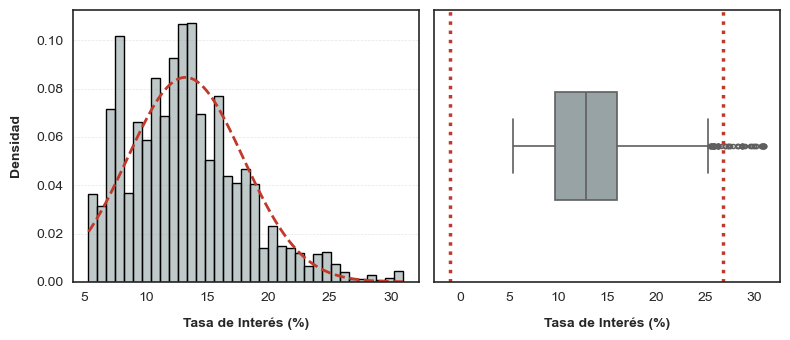

In [78]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'int_rate', 'Tasa de Interés (%)')

La visualización de la tasa de interés revela una distribución con una marcada asimetría positiva (sesgo a la derecha), caracterizada por una alta densidad de créditos en los rangos inferiores y medios, pero con múltiples valores alejados hacia la derecha que superan el 25%. Esta morfología confirma que, si bien la mayoría de los préstamos se pactan bajo condiciones estándar, existe un segmento crítico de clientes a los que se les asignan costos financieros extremos.Para verificar la magnitud exacta de estas desviaciones y determinar si estos registros constituyen valores atípicos (outliers) de error o si representan outliers de negocio (casos reales de altísimo riesgo), se utilizará el Z-Score Modificado ($M_i$).

In [56]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers = validate_outliers_robust(df_reduce, "int_rate")
unique_outliers = outliers.groupby('int_rate').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('int_rate', 'count')
).reset_index()

unique_outliers = unique_outliers.sort_values(by='Desviacion_Mi', ascending=False)

formatters = {
    'int_rate': lambda x: f"{x:.2f}%",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_unique = unique_outliers.style.format(formatters).hide(axis='index')
styled_unique = styled_unique.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_unique = styled_unique.set_properties(subset=['int_rate'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_unique.to_html() + "</div>"))

int_rate,Desviacion_Mi,Frecuencia
30.99%,3.9203,10


El análisis detallado de la Tasa de Interés (`int_rate`) reveló un grupo crítico de registros con un valor atípico de 30.99%, el cual se sitúa significativamente por encima del comportamiento central de la muestra. No obstante, al ser este un nivel tarifario plausible para los segmentos de riesgo más altos en plataformas de lending, y dada la falta de evidencia técnica que sugiera errores de digitación, se concluye que estos registros constituyen outliers de negocio. Su conservación es fundamental para que el modelo capture la varianza real del riesgo extremo, permitiendo al algoritmo reconocer las fronteras de decisión en casos de máxima vulnerabilidad crediticia.

##### Puntaje FICO (Límite Superior)

El Puntaje FICO Superior (`fico_range_high`) constituye el segundo pilar de mayor relevancia en el análisis (KS = 0.1369), operando como la métrica estándar de reputación crediticia y solvencia histórica en el mercado estadounidense. Desde la óptica del negocio, esta variable representa la probabilidad a priori de cumplimiento basada en el comportamiento pasado del prestatario, funcionando como el principal filtro de entrada para la aprobación de créditos. En el modelo, su relación con el riesgo es inversamente proporcional: puntajes elevados actúan como factores protectores que facilitan el acceso a mejores condiciones financieras, mientras que valores bajos señalan una vulnerabilidad estructural que suele preceder al impago.


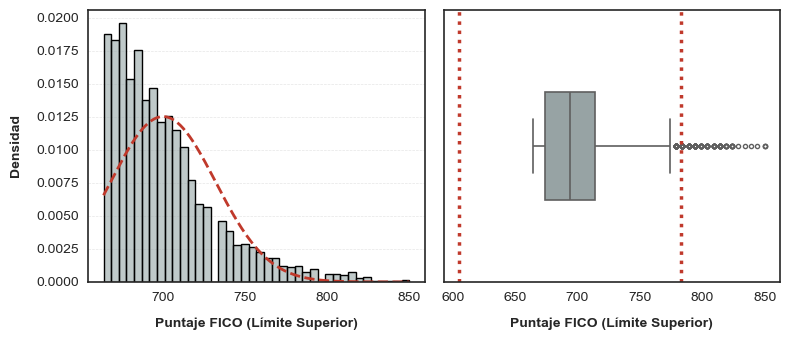

In [79]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'fico_range_high', 'Puntaje FICO (Límite Superior)')

La distribución del Puntaje FICO Superior muestra una alta densidad de registros concentrados en valores cercanos a los 700, lo que representa el perfil promedio de los solicitantes que acceden a la plataforma. No obstante, la visualización revela la presencia de puntos significativamente superiores que superan el umbral de los 800 puntos, evidenciando un segmento de prestatarios con una calidad crediticia excepcional. Esta dispersión en el extremo superior de la escala justifica un análisis más detallado mediante el Z-Score Modificado ($M_i$), con el fin de determinar si estos valores de excelencia operativa constituyen outliers de negocio que el modelo de Random Forest debe identificar como los casos de menor riesgo relativo dentro del ecosistema financiero.

In [59]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_fico = validate_outliers_robust(df_reduce, "fico_range_high")

unique_outliers_fico = outliers_fico.groupby('fico_range_high').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('fico_range_high', 'count')
).reset_index()

unique_outliers_fico = unique_outliers_fico.sort_values(by='Desviacion_Mi', ascending=False)

formatters_fico = {
    'fico_range_high': lambda x: f"{x:.0f}",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_fico = unique_outliers_fico.style.format(formatters_fico).hide(axis='index')

styled_fico = styled_fico.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_fico = styled_fico.set_properties(subset=['fico_range_high'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_fico.to_html() + "</div>"))

fico_range_high,Desviacion_Mi,Frecuencia
850,5.2611,9
844,5.0587,1


Para finalizar el análisis del Puntaje FICO Superior (`fico_range_high`), es fundamental precisar que, si bien el estadístico $M_i$ identifica los valores de 850 y 845 como atípicos debido a su baja frecuencia y distancia de la mediana, estos registros son plenamente plausibles y coherentes dentro del sistema crediticio estadounidense. Un puntaje de 850 representa la calificación máxima de excelencia crediticia, denotando un perfil de riesgo prácticamente nulo que, aunque escaso, es real y verificable en la operativa de LendingClub. Por tanto, se concluye que estos datos no constituyen errores de captura, sino outliers de negocio que capturan el límite superior de la solvencia

##### Puntaje FICO (Límite Inferior)

El Puntaje FICO Inferior (`fico_range_low`) actúa como el límite base del rango de solvencia asignado al prestatario, compartiendo la misma relevancia predictiva que su contraparte superior (KS = 0.1369). La diferencia fundamental entre ambas no radica en su capacidad de discriminación, sino en su función técnica dentro del reporte: mientras el límite superior marca el techo de la categoría, el fico_range_low establece el suelo o "piso" del riesgo. En la práctica operativa de LendingClub, este valor es el que suele gatillar las reglas de decisión más conservadoras, ya que ante una dispersión en el rango, el sistema tiende a penalizar basándose en el valor inferior para mitigar la exposición. Al igual que en la versión superior, su relación con el default es inversamente proporcional, y su análisis morfológico permite validar la consistencia de los "buckets" o intervalos de 5 puntos que estructuran la calificación crediticia.


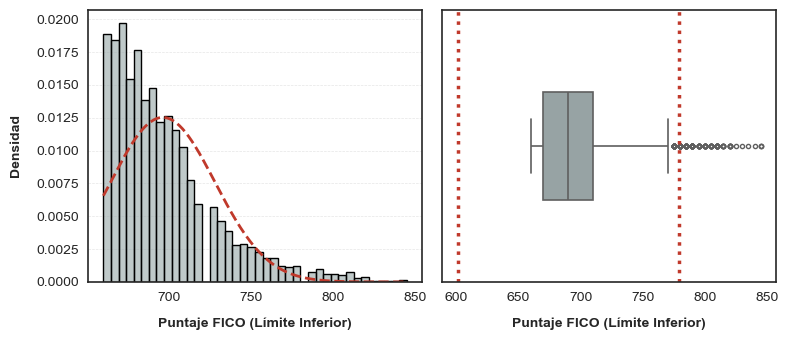

In [80]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'fico_range_low', 'Puntaje FICO (Límite Inferior)')

La morfología de la distribución del Puntaje FICO Inferior resulta casi idéntica a la de su contraparte superior, exhibiendo una alta concentración de registros en niveles relativamente bajos, con una moda cercana a los 700 puntos. No obstante, se observa una extensión de la densidad hacia valores superiores a 800, lo que confirma la presencia de perfiles con una solvencia histórica excepcional. Dada la simetría casi absoluta entre ambos límites del rango FICO, se plantea la hipótesis de que mantener ambas variables en el entrenamiento del modelo podría generar redundancia informativa. Por tanto, se concluye la necesidad de realizar un análisis de dependencia y correlación posterior para determinar si la consolidación en una única métrica optimizaría la eficiencia del algoritmo sin sacrificar capacidad predictiva.

In [60]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_fico_low = validate_outliers_robust(df_reduce, "fico_range_low")

unique_outliers_low = outliers_fico_low.groupby('fico_range_low').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('fico_range_low', 'count')
).reset_index()

unique_outliers_low = unique_outliers_low.sort_values(by='Desviacion_Mi', ascending=False)
formatters_fico_low = {
    'fico_range_low': lambda x: f"{x:.0f}",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_fico_low = unique_outliers_low.style.format(formatters_fico_low).hide(axis='index')

styled_fico_low = styled_fico_low.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_fico_low = styled_fico_low.set_properties(subset=['fico_range_low'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_fico_low.to_html() + "</div>"))

fico_range_low,Desviacion_Mi,Frecuencia
845,5.2274,9
840,5.0587,1


Al auditar los valores críticos del Puntaje FICO Inferior (`fico_range_low`), se observa que los registros con puntuaciones de 845 y 840 presentan una desviación significativa ($M_i > 5$), coincidiendo exactamente con una diferencia de 5 puntos respecto a los máximos detectados en el límite superior. Esta simetría perfecta no solo confirma la estructura de "buckets" o intervalos cerrados del sistema crediticio, sino que descarta la posibilidad de errores de digitación aislados. Al igual que en la versión superior, estos datos se clasifican como outliers de negocio que representan la frontera de la excelencia crediticia. 

##### Relación Deuda-Ingreso (DTI)

La Relación Deuda-Ingreso (`dti`) es un indicador financiero que mide el nivel de apalancamiento mensual de un solicitante, calculando qué porcentaje de sus ingresos brutos se destina exclusivamente al pago de deudas preexistentes (excluyendo la hipoteca y el préstamo solicitado).

Desde la perspectiva de riesgo crediticio, esta variable actúa como el principal medidor de la capacidad de flujo de caja: mientras que el puntaje FICO observa el comportamiento pasado, el dti evalúa la solvencia presente y futura. En el modelo, su impacto es crítico porque define el margen de maniobra del prestatario ante imprevistos; un dti elevado indica una "asfixia financiera" donde cualquier fluctuación económica mínima puede derivar en un incumplimiento de pago (`default`), independientemente de la voluntad histórica de pago del cliente.


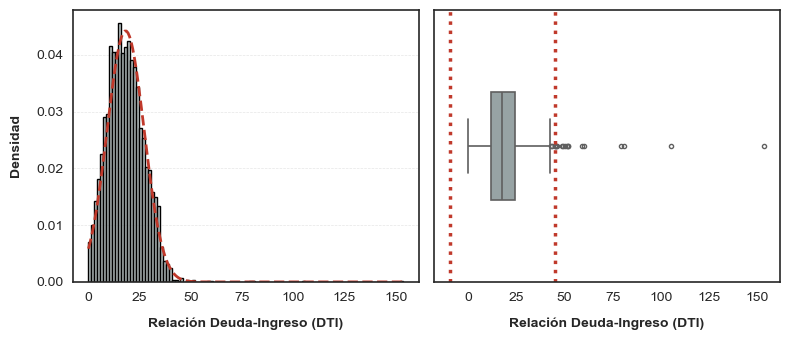

In [81]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'dti', 'Relación Deuda-Ingreso (DTI)')

En términos distribucionales, los datos de la Relación Deuda-Ingreso (`dti`) presentan una alta concentración en el extremo inferior, situándose mayoritariamente en el rango de 0% a 50%, lo cual refleja la estructura de perfiles con una carga financiera manejable para la plataforma. Sin embargo, la identificación de registros con valores superiores al 100% distorsiona la morfología de la variable y exige un análisis detallado mediante el Z-Score Modificado ($M_i$).

In [61]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_dti = validate_outliers_robust(df_reduce, "dti")

unique_outliers_dti = outliers_dti.groupby('dti').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('dti', 'count')
).reset_index()

unique_outliers_dti['abs_Mi'] = unique_outliers_dti['Desviacion_Mi'].abs()
unique_outliers_dti = unique_outliers_dti.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_dti = {
    'dti': lambda x: f"{x:.2f}%",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_dti = unique_outliers_dti.style.format(formatters_dti).hide(axis='index')
styled_dti = styled_dti.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_dti = styled_dti.set_properties(subset=['dti'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dti.to_html() + "</div>"))

dti,Desviacion_Mi,Frecuencia
999.00%,108.6964,5
765.76%,82.8638,1
483.88%,51.6441,1
441.50%,46.9503,1
314.73%,32.9098,1
283.14%,29.4111,1


Tras la inspección de los valores con mayores desviaciones mediante el $M_i$, se identifican registros con ratios de 999%, 765.76% y 283.14%. Estos valores, aunque estadísticamente detectados como extremos, se clasifican como errores de integridad o inconsistencias de cálculo en el origen de los datos, dado que superan la capacidad de endeudamiento total de cualquier perfil crediticio. Por lo tanto, se concluye la necesidad de establecer un umbral de truncamiento o limpieza (ej. $DTI < 100\%$) para asegurar que el modelo aprenda sobre perfiles financieros plausibles

In [24]:
df_reduce = df_reduce.withColumn(
    "dti", 
    F.when((F.col("dti") < 0) | (F.col("dti") > 100), None)
     .otherwise(F.col("dti"))
)

##### Cuentas Abiertas (Últimos 24 meses)

La variable `acc_open_past_24mths` cuantifica el dinamismo crediticio reciente del solicitante, registrando el número total de nuevas líneas de crédito (tarjetas, préstamos personales, créditos vehiculares, etc.) abiertas en los últimos dos años.

Desde la perspectiva del riesgo, esta métrica actúa como un sensor de "voracidad crediticia": mientras que el historial total nos habla de la experiencia a largo plazo, esta variable nos indica qué tan rápido se está apalancando el usuario en la actualidad. En el sector financiero, un volumen inusualmente alto de aperturas en un periodo corto suele interpretarse como una búsqueda urgente de liquidez o una señal de estrés financiero inminente.


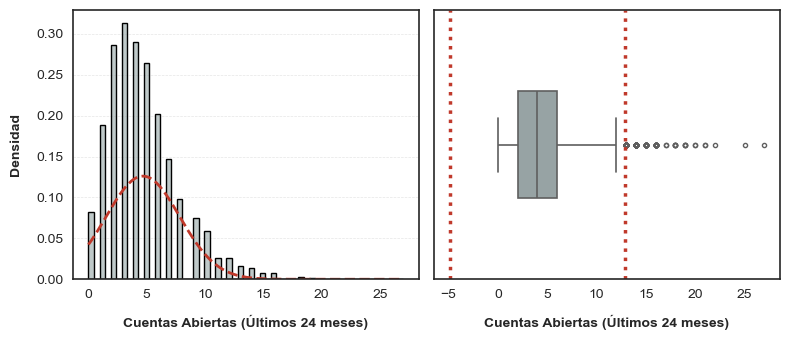

In [82]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'acc_open_past_24mths', 'Cuentas Abiertas (Últimos 24 meses)')

En términos de morfología, la distribución de `acc_open_past_24mths` exhibe una marcada asimetría positiva (sesgo a la derecha), con una concentración masiva de registros en el rango de 0 a 10 aperturas. No obstante, la visualización revela una cola larga que se extiende significativamente más allá de los 25. Esta estructura confirma que, si bien el prestatario promedio mantiene un dinamismo moderado, existe un segmento de "hiper-actividad" crediticia cuyos niveles de apertura mensual son estadísticamente anómalos.

In [62]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_acc = validate_outliers_robust(df_reduce, "acc_open_past_24mths")

unique_outliers_acc = outliers_acc.groupby('acc_open_past_24mths').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('acc_open_past_24mths', 'count')
).reset_index()

unique_outliers_acc['abs_Mi'] = unique_outliers_acc['Desviacion_Mi'].abs()
unique_outliers_acc = unique_outliers_acc.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_acc = {
    'acc_open_past_24mths': lambda x: f"{x:.0f}",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_acc = unique_outliers_acc.style.format(formatters_acc).hide(axis='index')
styled_acc = styled_acc.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_acc = styled_acc.set_properties(subset=['acc_open_past_24mths'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_acc.to_html() + "</div>"))

acc_open_past_24mths,Desviacion_Mi,Frecuencia
34,10.1175,1
32,9.4430,1
31,9.1058,4
30,8.7685,1
29,8.4313,3


La aplicación del Z-Score Modificado ($M_i$) reveló un comportamiento de riesgo extremo pero financieramente posible. Identificar registros con 34, 32 o 31 cuentas nuevas en solo dos años (un promedio de más de una apertura mensual) señala perfiles con una "voracidad crediticia" fuera de lo común. A diferencia de los errores técnicos vistos en el DTI, estos valores son outliers de negocio plenamente plausibles en consumidores que practican el credit layering (acumulación de múltiples líneas de crédito simultáneas). Dado que estas desviaciones ($M_i > 8$) son indicadores críticos de una búsqueda desesperada de liquidez, su permanencia en el dataset es fundamental para que el modelo predictivo aprenda a penalizar con precisión a los solicitantes que, a pesar de tener ingresos, muestran señales claras de un colapso financiero inminente por sobre-expansión.

##### Saldo Promedio Actual de Cuentas

El Saldo Promedio de las Cuentas ( `avg_cur_bal`) representa la media de los saldos actuales en todas las cuentas abiertas del prestatario. Desde la óptica del negocio, esta métrica es un proxy de la capacidad de ahorro y la estabilidad económica; saldos promedio elevados suelen actuar como un factor de mitigación de riesgo, incluso si otras variables como el DTI son moderadamente altas. En el modelo, esta variable ayuda a diferenciar entre prestatarios que viven al límite de sus ingresos y aquellos que poseen un colchón financiero que les permitiría enfrentar contingencias sin caer en impago.


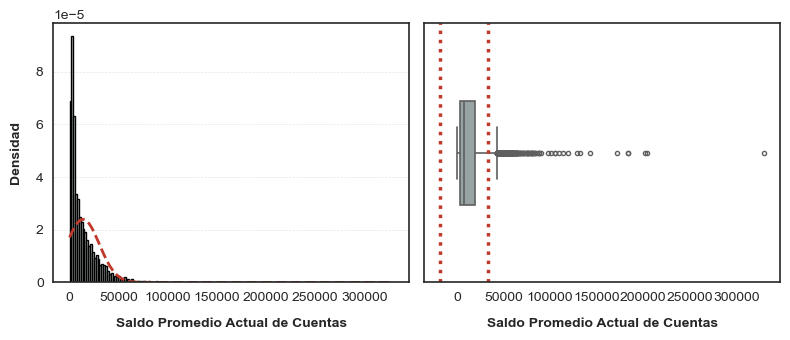

In [83]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'avg_cur_bal', 'Saldo Promedio Actual de Cuentas')

La visualización de esta variable revela una distribución con una marcada asimetría positiva (sesgo a la derecha), con la gran mayoría de los registros concentrados en el rango inferior entre $\$0$ y $\$5,000$. Sin embargo, se observa una cola extremadamente larga que se extiende hacia valores superiores a los $\$30,000$, evidenciando un segmento minoritario de prestatarios con una capacidad financiera muy superior al promedio. Esta morfología justifica un análisis detallado mediante el Z-Score Modificado ($M_i$) para auditar si estos saldos elevados representan casos reales de clientes de alto patrimonio o posibles inconsistencias en el reporte de saldos.

In [64]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_bal = validate_outliers_robust(df_reduce, "avg_cur_bal")

unique_outliers_bal = outliers_bal.groupby('avg_cur_bal').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('avg_cur_bal', 'count')
).reset_index()

unique_outliers_bal['abs_Mi'] = unique_outliers_bal['Desviacion_Mi'].abs()
unique_outliers_bal = unique_outliers_bal.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_bal = {
    'avg_cur_bal': lambda x: f"${x:,.2f}",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_bal = unique_outliers_bal.style.format(formatters_bal).hide(axis='index')
styled_bal = styled_bal.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])


styled_bal = styled_bal.set_properties(subset=['avg_cur_bal'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_bal.to_html() + "</div>"))

avg_cur_bal,Desviacion_Mi,Frecuencia
"$463,945.00",56.6075,1
"$335,174.00",40.6398,1
"$329,295.00",39.9108,1
"$300,735.00",36.3694,1
"$297,117.00",35.9207,1
"$290,044.00",35.0437,1
"$282,167.00",34.0669,1
"$260,736.00",31.4095,1
"$255,826.00",30.8006,1
"$247,213.00",29.7326,1


Tras la inspección de los registros con mayores desviaciones, se identifican saldos promedio que oscilan entre $\$247,213$ y un máximo de $\$463,945$. Aunque estadísticamente estos puntos presentan un $M_i$ extremadamente elevado (superando el umbral de 3.5 por un factor de 10), desde la lógica de negocio se clasifican como outliers de excelencia patrimonial. En el contexto de LendingClub, estos valores representan a clientes con activos consolidados (posiblemente vinculados a inversiones inmobiliarias o carteras de inversión robustas) que mantienen saldos elevados en sus líneas de crédito. No hay evidencia de que estos montos sean fallos de digitación, sino más bien indicadores de una capacidad de respuesta financiera superior.

##### Límite de Crédito Total Histórico

La variable `tot_hi_cred_lim` representa el Límite de Crédito Total Histórico que el sistema financiero ha otorgado al prestatario a lo largo del tiempo, consolidando todas sus líneas de crédito (hipotecas, tarjetas, préstamos de consumo, etc.).

A diferencia del saldo actual, esta métrica es un indicador de "confianza agregada": refleja el voto de confianza máximo que múltiples instituciones financieras han depositado en el individuo. Desde la óptica del riesgo, un límite elevado suele actuar como un factor de mitigación, ya que sugiere que el sujeto ha superado rigurosos procesos de aprobación en el pasado y posee una "espalda financiera" considerable.


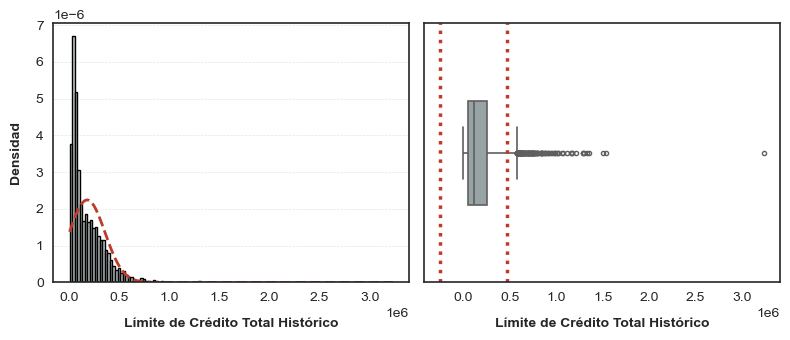

In [84]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'tot_hi_cred_lim', 'Límite de Crédito Total Histórico')

La visualización de esta variable revela una distribución con una marcada asimetría positiva (sesgo a la derecha), con la gran mayoría de los registros concentrados en el rango inferior entre $\$0$ y $\$1,000,000$. Sin embargo, se observa una cola extremadamente larga que se extiende significativamente hacia valores que superan los $\$2,000,000$, evidenciando un segmento minoritario de prestatarios con un respaldo patrimonial y una confianza crediticia institucional que excede por órdenes de magnitud el promedio de la muestra.

Esta morfología justifica un análisis detallado mediante el Z-Score Modificado ($M_i$) para auditar si estos límites multimillonarios representan casos reales de clientes con activos de alto valor (como garantías hipotecarias múltiples) o si existen inconsistencias en la agregación de saldos reportados.

In [66]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_lim = validate_outliers_robust(df_reduce, "tot_hi_cred_lim")

unique_outliers_lim = outliers_lim.groupby('tot_hi_cred_lim').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('tot_hi_cred_lim', 'count')
).reset_index()

unique_outliers_lim['abs_Mi'] = unique_outliers_lim['Desviacion_Mi'].abs()
unique_outliers_lim = unique_outliers_lim.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_lim = {
    'tot_hi_cred_lim': lambda x: f"${x:,.2f}",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_lim = unique_outliers_lim.style.format(formatters_lim).hide(axis='index')
styled_lim = styled_lim.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_lim = styled_lim.set_properties(subset=['tot_hi_cred_lim'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_lim.to_html() + "</div>"))

tot_hi_cred_lim,Desviacion_Mi,Frecuencia
"$9,999,999.00",84.7534,1
"$3,894,341.00",32.4121,1
"$3,232,338.00",26.7371,1
"$2,885,999.00",23.7680,1
"$2,683,209.00",22.0296,1
"$2,624,646.00",21.5276,1
"$2,589,500.00",21.2263,1
"$2,463,528.00",20.1464,1
"$2,445,305.00",19.9901,1
"$2,350,832.00",19.1803,1


El análisis detallado de la cola superior de tot_hi_cred_lim revela una anomalía estructural que trasciende la simple variabilidad estadística. Mientras que el segundo valor más alto identificado es de $\$3,894,341.00$ ($M_i = 32.41$), el máximo absoluto se dispara hasta los $\$9,999,999.00$, arrojando una desviación de $M_i = 84.75$. Esta brecha de más de $\$6$ millones entre el primer y segundo registro, sumada a la naturaleza simbólica de una cadena de nueves, es un indicador clásico de un valor de saturación o "cap" sistémico (un placeholder técnico para representar cualquier monto que exceda la capacidad de almacenamiento del campo). Por lo tanto, se determina un umbral de corte en $\$4,000,000.00$. Esta decisión permite preservar la señal de los perfiles de alta solvencia orgánica (aquellos con límites reales entre $\$2M$ y $\$4M$) mientras se neutraliza el ruido provocado por registros que no siguen la progresión lógica de la distribución crediticia.

In [25]:
df_reduce = df_reduce.withColumn(
    "tot_hi_cred_lim", 
    F.when(F.col("tot_hi_cred_lim") > 4000000, None).otherwise(F.col("tot_hi_cred_lim"))
)

##### Capacidad de Compra en Tarjetas

La variable `bc_open_to_buy` cuantifica el monto total de crédito rotativo que el prestatario tiene autorizado en sus tarjetas de crédito pero que aún no ha sido utilizado. A diferencia de las métricas de deuda total, este indicador representa la reserva de liquidez inmediata o el "oxígeno financiero" del individuo ante contingencias.

Desde la óptica del riesgo, una alta capacidad disponible actúa como un potente factor de mitigación; sugiere no solo que el prestatario posee acceso a capital de emergencia, sino que demuestra una disciplina de consumo superior al mantener bajos niveles de utilización. En el modelo, esta variable es fundamental para identificar perfiles resilientes que, a pesar de solicitar un nuevo préstamo, conservan un margen de maniobra que reduce drásticamente la probabilidad de incurrir en impagos por asfixia financiera.


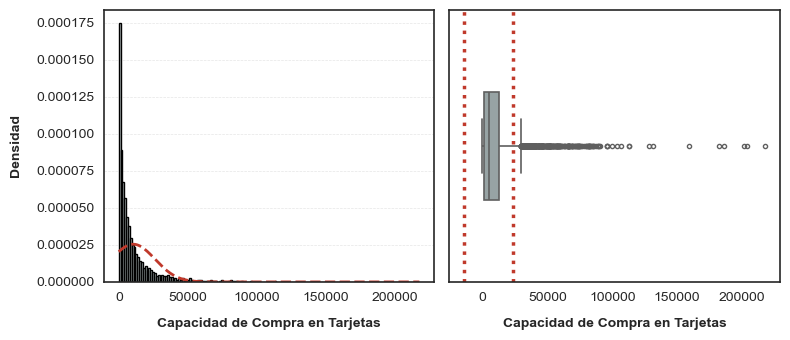

In [85]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'bc_open_to_buy', 'Capacidad de Compra en Tarjetas')

La visualización de esta variable revela una distribución con una marcada asimetría positiva (sesgo a la derecha). La masa crítica de los datos se encuentra concentrada en el rango inferior entre los $\$0$ y los $\$50,000$, lo cual es coherente con perfiles de consumo activo que mantienen un margen de seguridad razonable. Sin embargo, se observa una cola extremadamente larga que se extiende hacia valores que superan los $\$200,000$, evidenciando un segmento minoritario de prestatarios con una solvencia patrimonial y unos límites de crédito excepcionales.

Esta morfología justifica un análisis detallado mediante el Z-Score Modificado ($M_i$) para auditar si estos saldos disponibles superiores a los $\$200,000$ representan casos reales de líneas de crédito masivas o si existen distorsiones en el reporte de saldos actuales frente a los límites concedidos.

In [68]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_otb = validate_outliers_robust(df_reduce, "bc_open_to_buy")

unique_outliers_otb = outliers_otb.groupby('bc_open_to_buy').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('bc_open_to_buy', 'count')
).reset_index()

unique_outliers_otb['abs_Mi'] = unique_outliers_otb['Desviacion_Mi'].abs()
unique_outliers_otb = unique_outliers_otb.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_otb = {
    'bc_open_to_buy': lambda x: f"${x:,.2f}",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_otb = unique_outliers_otb.style.format(formatters_otb).hide(axis='index')

styled_otb = styled_otb.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_otb = styled_otb.set_properties(subset=['bc_open_to_buy'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_otb.to_html() + "</div>"))

bc_open_to_buy,Desviacion_Mi,Frecuencia
"$288,813.00",48.0487,1
"$281,029.00",46.7321,1
"$278,899.00",46.3719,1
"$269,756.00",44.8255,1
"$263,229.00",43.7216,1
"$239,158.00",39.6504,1
"$229,650.00",38.0423,1
"$224,610.00",37.1898,1
"$220,865.00",36.5564,1
"$217,644.00",36.0117,1


La inspección de los registros con mayores desviaciones revela capacidades de compra disponibles que oscilan entre los $\$217,644$ ($M_i = 36.01$) y un máximo absoluto de $\$288,813$ ($M_i = 48.04$). A diferencia de otras métricas de solvencia, esta variable no presenta saltos artificiales ni valores de saturación técnica; por el contrario, muestra una progresión decreciente en las frecuencias de la cola derecha, lo que sugiere que estos montos son el resultado genuino de límites de crédito masivos combinados con saldos de uso prácticamente nulos.

Desde la perspectiva del riesgo, estos prestatarios representan el "ancla de seguridad" del portafolio. Poseer más de un cuarto de millón de dólares en liquidez rotativa inmediata indica una solvencia patrimonial que hace casi despreciable la probabilidad de default por falta de flujo de caja. Por consiguiente, se determina la conservación íntegra de estos registros, ya que proporcionan al modelo predictivo la información necesaria para discriminar con alta precisión los perfiles de riesgo ultra-bajo.

##### Número de Cuentas Hipotecarias

La variable `mort_acc` representa el conteo total de cuentas hipotecarias que el prestatario ha mantenido en su historial crediticio, actuando como un indicador fundamental de estabilidad patrimonial y arraigo financiero. A diferencia de las líneas de crédito de consumo, esta métrica trasciende la simple cuantificación de deuda para convertirse en un sello de aprobación institucional previo; el hecho de poseer una hipoteca implica que el individuo ya ha superado procesos de auditoría bancaria significativamente más rigurosos que los requeridos para un préstamo personal. Desde la óptica del riesgo, esta variable funciona como un potente mitigador, ya que la propiedad de una vivienda suele asociarse con una mayor responsabilidad en los pagos, una menor movilidad domiciliaria y un costo de oportunidad mucho más elevado ante un eventual incumplimiento.


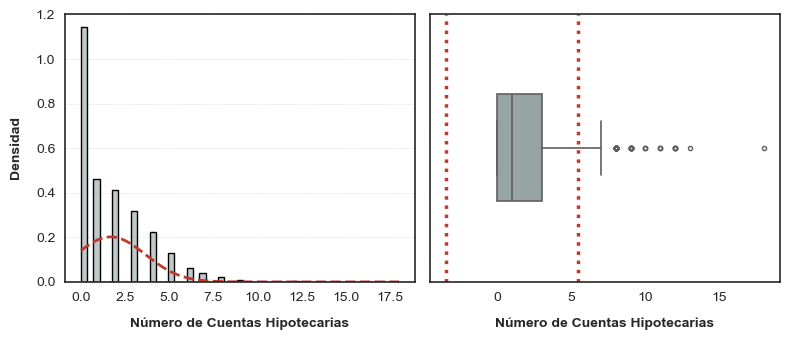

In [86]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'mort_acc', 'Número de Cuentas Hipotecarias')

La visualización de esta variable revela una distribución con una marcada asimetría positiva. La masa crítica de los datos se encuentra concentrada en el rango inferior entre las 0 y las 5 cuentas, lo cual es coherente con perfiles de arrendatarios o propietarios de vivienda única que mantienen una estructura de activos convencional. Sin embargo, se observa una cola extremadamente larga que se extiende hacia valores que superan las 15 cuentas, evidenciando un segmento minoritario de prestatarios con una solvencia patrimonial y un nivel de inversión inmobiliaria excepcionales.

In [69]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_mort = validate_outliers_robust(df_reduce, "mort_acc")

unique_outliers_mort = outliers_mort.groupby('mort_acc').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('mort_acc', 'count')
).reset_index()

unique_outliers_mort['abs_Mi'] = unique_outliers_mort['Desviacion_Mi'].abs()
unique_outliers_mort = unique_outliers_mort.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_mort = {
    'mort_acc': lambda x: f"{int(x)} cuentas",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_mort = unique_outliers_mort.style.format(formatters_mort).hide(axis='index')
styled_mort = styled_mort.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_mort = styled_mort.set_properties(subset=['mort_acc'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_mort.to_html() + "</div>"))

mort_acc,Desviacion_Mi,Frecuencia
27 cuentas,17.5370,1
24 cuentas,15.5135,3
23 cuentas,14.8390,1
22 cuentas,14.1645,1
21 cuentas,13.4900,1
20 cuentas,12.8155,1
19 cuentas,12.1410,2


La inspección de los registros con mayores desviaciones revela una presencia de casos que oscilan entre las 20 y las 27 cuentas hipotecarias, con valores de $M_i$ que alcanzan un máximo de 17.53. A diferencia de lo observado en otras métricas donde los valores extremos sugerían techos técnicos o errores de sistema, la progresión cuasi-continua en este rango (19, 20, 21, 22, 23, 24 y 27) sugiere que no estamos ante errores de digitación, sino ante la identificación de un nicho de prestatarios con un perfil de inversores inmobiliarios profesionales. 

En el contexto de la gestión de riesgos, estos sujetos representan casos de apalancamiento patrimonial masivo; aunque el número de obligaciones es inusualmente alto para un consumidor promedio, la capacidad de haber obtenido y mantenido más de veinte hipotecas simultáneas es un indicador de una solvencia institucional validada y una gestión de activos compleja.

##### Líneas de Crédito Abiertas (Último año)

La variable `num_tl_op_past_12m` cuantifica el número de nuevas cuentas de crédito que el prestatario ha aperturado en los últimos doce meses, funcionando como un sensor crítico del apetito de deuda inmediato. A diferencia de las métricas de madurez histórica, esta variable captura el comportamiento de búsqueda de liquidez en el corto plazo; un valor elevado sugiere una expansión acelerada de las obligaciones financieras que podría comprometer la capacidad de pago futura. En el modelo, esta variable es crucial para identificar perfiles que, a pesar de tener un historial sólido, presentan signos recientes de inestabilidad o dependencia excesiva del crédito.


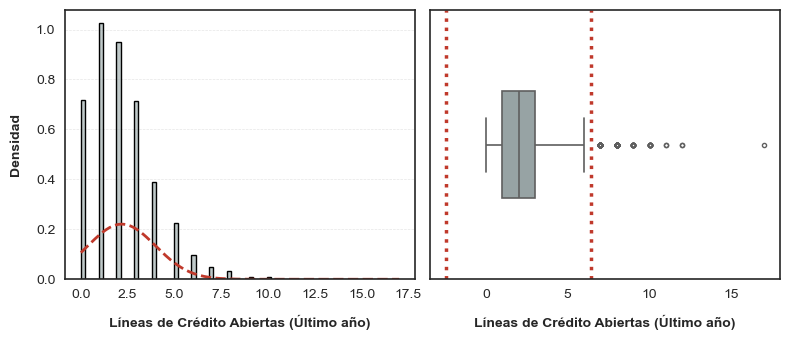

In [87]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'num_tl_op_past_12m', 'Líneas de Crédito Abiertas (Último año)')

La visualización de esta variable revela una distribución con una marcada asimetría positiva. La masa crítica de los datos se encuentra concentrada en el rango inferior entre las 0 y las 5 líneas, lo cual es coherente con un manejo financiero estándar y una expansión de deuda controlada. Sin embargo, se observa una cola extremadamente larga que se extiende hacia valores que sobrepasan las 15 líneas, evidenciando un segmento minoritario de prestatarios en una fase de búsqueda de crédito agresiva que excede por mucho el promedio de la muestra.

In [70]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_12m = validate_outliers_robust(df_reduce, "num_tl_op_past_12m")

unique_outliers_12m = outliers_12m.groupby('num_tl_op_past_12m').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('num_tl_op_past_12m', 'count')
).reset_index()

unique_outliers_12m['abs_Mi'] = unique_outliers_12m['Desviacion_Mi'].abs()
unique_outliers_12m = unique_outliers_12m.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_12m = {
    'num_tl_op_past_12m': lambda x: f"{int(x)} líneas",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_12m = unique_outliers_12m.style.format(formatters_12m).hide(axis='index')
styled_12m = styled_12m.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_12m = styled_12m.set_properties(subset=['num_tl_op_past_12m'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_12m.to_html() + "</div>"))

num_tl_op_past_12m,Desviacion_Mi,Frecuencia
26 líneas,16.1880,1
24 líneas,14.8390,1
23 líneas,14.1645,1
19 líneas,11.4665,1
17 líneas,10.1175,6


La inspección de los registros con mayores desviaciones para la variable `num_tl_op_past_12m` revela casos que alcanzan hasta las 26 líneas de crédito abiertas en un solo año, con valores de $M_i$ que superan el umbral de 16. Estos registros no constituyen errores de captura, sino que representan comportamientos de búsqueda intensiva de crédito (*credit seeking behavior*) en su expresión más extrema. En el ámbito del análisis de riesgo, estos sujetos son clasificados como outliers de negocio legítimos, ya que capturan una fase de expansión de deuda acelerada que suele preceder a eventos de insolvencia

##### Porcentaje de Tarjetas con Uso > 75%

La variable `percent_bc_gt_75` cuantifica la proporción de cuentas de tarjetas de crédito que operan por encima del $75\%$ de su límite, funcionando como un sensor de asfixia financiera inmediata. Un porcentaje elevado indica que el prestatario ha agotado su margen de maniobra y depende críticamente de nuevos créditos para sostener su flujo de caja, lo que incrementa exponencialmente el riesgo de insolvencia. En el modelo, esta métrica es vital para detectar la saturación de consumo y diferenciar perfiles con deuda manejable de aquellos con una dependencia sistémica que compromete su estabilidad a corto plazo.


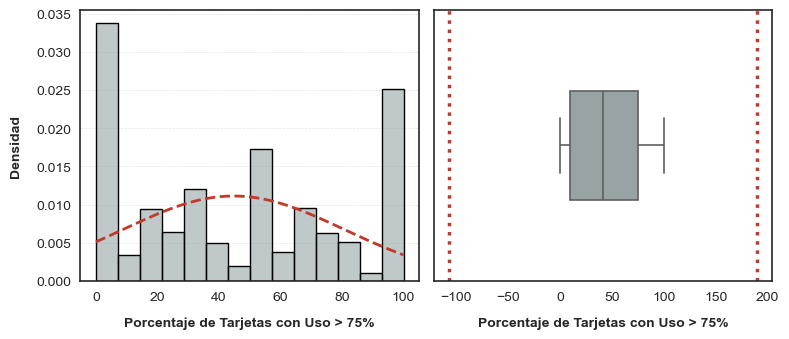

In [88]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'percent_bc_gt_75', 'Porcentaje de Tarjetas con Uso > 75%')

La visualización de esta variable revela una distribución con una marcada naturaleza bimodal, acotada estrictamente entre el $0\%$ y el $100\%$, lo que refleja una polarización clara en el comportamiento de uso del crédito. La masa crítica de los registros se concentra en los extremos del espectro: un volumen masivo en el valor de $0\%$, correspondiente a prestatarios que mantienen todos sus saldos bajo control, frente a un segundo pico en el $100\%$ que identifica a sujetos con una saturación total de su capacidad rotativa. 

##### Límite Total de Crédito Revolvente

La variable `total_rev_hi_lim` actúa como el indicador definitivo de la confianza del mercado en la capacidad de pago a corto plazo del individuo. Al ser un límite rotativo, su gestión exige una disciplina financiera mayor que la de un crédito fijo, por lo que valores atípicamente altos suelen estar reservados para perfiles de alta solvencia o con un historial de consumo masivo y responsable.


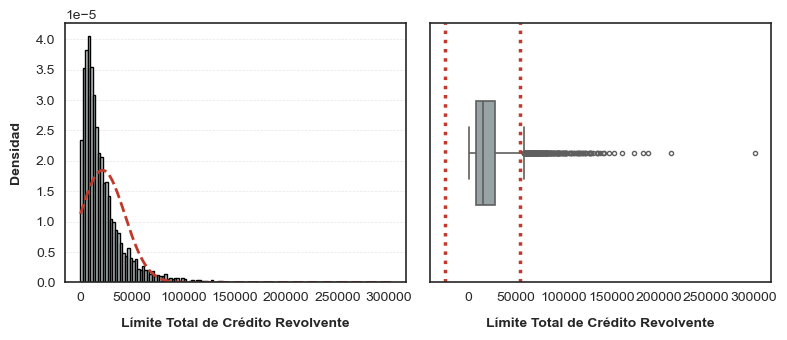

In [89]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'total_bc_limit', 'Límite Total de Crédito Revolvente')

La morfología observada en el Límite Total de Crédito Revolvente es un reflejo fiel de la segmentación del mercado crediticio. La alta densidad de registros concentrada en el intervalo de $\$0$ a $\$100,000$ representa la "masa crítica" de prestatarios estándar, donde el riesgo se gestiona mediante políticas de crédito convencionales. Sin embargo, la presencia de una cola larga (asimetría positiva) que se extiende más allá de los $\$300,000$ revela un segmento de perfiles "Premium" o corporativos cuya dinámica de liquidez es radicalmente distinta.

In [73]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_rev = validate_outliers_robust(df_reduce, "total_rev_hi_lim")

unique_outliers_rev = outliers_rev.groupby('total_rev_hi_lim').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('total_rev_hi_lim', 'count')
).reset_index()

unique_outliers_rev['abs_Mi'] = unique_outliers_rev['Desviacion_Mi'].abs()
unique_outliers_rev = unique_outliers_rev.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_rev = {
    'total_rev_hi_lim': lambda x: f"${x:,.2f}",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_rev = unique_outliers_rev.style.format(formatters_rev).hide(axis='index')
styled_rev = styled_rev.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_rev = styled_rev.set_properties(subset=['total_rev_hi_lim'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_rev.to_html() + "</div>"))

total_rev_hi_lim,Desviacion_Mi,Frecuencia
"$914,900.00",50.4968,1
"$684,907.00",37.4607,1
"$683,300.00",37.3696,1
"$678,300.00",37.0862,1
"$650,700.00",35.5218,1
"$630,000.00",34.3485,1
"$627,400.00",34.2011,1
"$592,300.00",32.2116,1
"$575,900.00",31.2821,1
"$572,600.00",31.0950,1


La inspección de los registros con mayores desviaciones para la variable `total_rev_hi_lim` revela casos que alcanzan límites de hasta $\$914,900.00$, con valores de $M\_i$ que escalan hasta 50.49. Estos registros no constituyen errores de captura ni fallos en la integración de datos, sino que representan la existencia de perfiles de alta liquidez o "Whales" (clientes de alto patrimonio) en su expresión más extrema dentro de la plataforma.

##### Líneas Revolventes Activas

La variable `num_actv_rev_tl` cuantifica el número de cuentas de crédito rotativo que presentan un saldo deudor al momento del reporte, funcionando como un termómetro de fragmentación y malabarismo financiero. Un conteo elevado indica que el prestatario está gestionando múltiples frentes de pago simultáneamente, lo que no solo incrementa la carga administrativa del individuo, sino que sugiere una dependencia atomizada del crédito para cubrir necesidades corrientes.


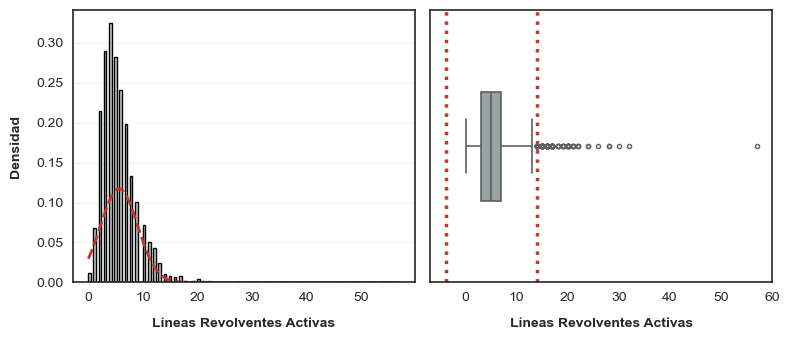

In [90]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'num_actv_rev_tl', 'Líneas Revolventes Activas')

La el número de líneas revolventes activas revela una distribución con una marcada asimetría positiva, donde la masa crítica se concentra en el rango inferior entre las 0 y las 10 líneas activas, reflejando estructuras de consumo convencionales y manejables. No obstante, se identifica una cola excepcionalmente larga que se proyecta hacia valores que superan las 50 cuentas, evidenciando un segmento de prestatarios con una "hiper-actividad" financiera extrema que compromete su disciplina de pago y eleva significativamente la vulnerabilidad ante choques de liquidez.

In [74]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_actv = validate_outliers_robust(df_reduce, "num_actv_rev_tl")

unique_outliers_actv = outliers_actv.groupby('num_actv_rev_tl').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('num_actv_rev_tl', 'count')
).reset_index()

unique_outliers_actv['abs_Mi'] = unique_outliers_actv['Desviacion_Mi'].abs()
unique_outliers_actv = unique_outliers_actv.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_actv = {
    'num_actv_rev_tl': lambda x: f"{int(x)} líneas activas",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_actv = unique_outliers_actv.style.format(formatters_actv).hide(axis='index')
styled_actv = styled_actv.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_actv = styled_actv.set_properties(subset=['num_actv_rev_tl'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_actv.to_html() + "</div>"))

num_actv_rev_tl,Desviacion_Mi,Frecuencia
57 líneas activas,17.5370,1
40 líneas activas,11.8037,1
38 líneas activas,11.1292,1
36 líneas activas,10.4548,3
35 líneas activas,10.1175,1
34 líneas activas,9.7803,3


La inspección de los registros con mayores desviaciones para la variable `num_actv_rev_tl` revela casos extremos que alcanzan hasta las 57 líneas revolventes activas simultáneamente, con valores de $M_i$ que escalan hasta un crítico 17.53. Estos registros no constituyen errores de captura ni fallos en la integración de la base de datos, sino que representan comportamientos de hiper-fragmentación crediticia en su expresión más aguda.

En el ámbito del análisis de riesgo, estos sujetos son clasificados como outliers de negocio legítimos, ya que capturan un estado de saturación financiera donde el prestatario gestiona una cantidad inusual de frentes de deuda, lo que suele preceder a crisis de liquidez sistémicas. 

##### Cuentas Revolventes con Saldo Deudor

La variable `num_rev_tl_bal_gt_0` cuantifica el número de instrumentos de crédito rotativo que efectivamente mantienen un balance pendiente de pago, funcionando como un sensor de presión financiera real y uso de capital ajeno. Un número elevado indica que el prestatario no solo posee múltiples líneas de crédito, sino que depende activamente de ellas para financiar su flujo de caja, lo que reduce su margen de maniobra ante imprevistos económicos.


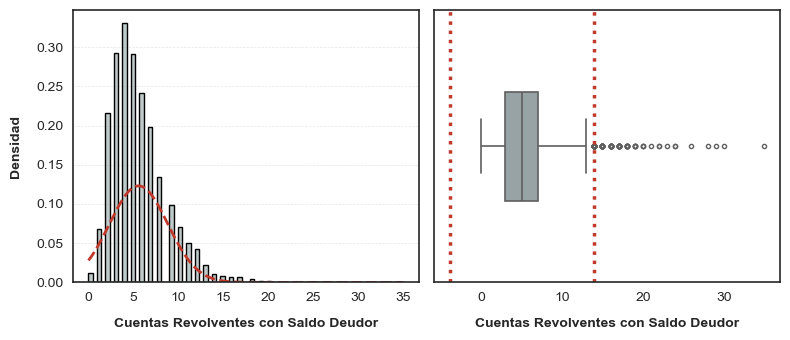

In [91]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'num_rev_tl_bal_gt_0', 'Cuentas Revolventes con Saldo Deudor')

La visualización del número de cuentas revolventes con saldo deudor revela una distribución con una marcada asimetría positiva, donde la masa crítica se concentra en el rango entre las 0 y las 15 cuentas con saldo, lo cual es coherente con perfiles de consumo que, aunque activos, mantienen una estructura de deuda dentro de los límites de gestión operativa convencional. No obstante, se identifica una cola excepcionalmente larga que se proyecta hacia valores que superan las 30 cuentas, evidenciando un segmento minoritario de prestatarios con una dispersión de deuda masiva que sugiere una dependencia sistémica del crédito rotativo.

In [75]:
#| code-fold: true
#| code-summary: "Mostrar código"

outliers_bal = validate_outliers_robust(df_reduce, "num_rev_tl_bal_gt_0")

unique_outliers_bal = outliers_bal.groupby('num_rev_tl_bal_gt_0').agg(
    Desviacion_Mi=('modified_z', 'first'),
    Frecuencia=('num_rev_tl_bal_gt_0', 'count')
).reset_index()

unique_outliers_bal['abs_Mi'] = unique_outliers_bal['Desviacion_Mi'].abs()
unique_outliers_bal = unique_outliers_bal.sort_values(by='abs_Mi', ascending=False).drop(columns=['abs_Mi'])

formatters_bal = {
    'num_rev_tl_bal_gt_0': lambda x: f"{int(x)} cuentas con saldo",
    'Desviacion_Mi': lambda x: f"{x:.4f}",
    'Frecuencia': lambda x: "{:,.0f}".format(x)
}

styled_bal = unique_outliers_bal.style.format(formatters_bal).hide(axis='index')
styled_bal = styled_bal.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '8px 15px'), ('background-color', 'white')
    ]}
])

styled_bal = styled_bal.set_properties(subset=['num_rev_tl_bal_gt_0'], **{'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_bal.to_html() + "</div>"))

num_rev_tl_bal_gt_0,Desviacion_Mi,Frecuencia
38 cuentas con saldo,11.1292,1
35 cuentas con saldo,10.1175,2
34 cuentas con saldo,9.7803,1
33 cuentas con saldo,9.4430,2
32 cuentas con saldo,9.1058,2
31 cuentas con saldo,8.7685,2


La inspección de los registros con mayores desviaciones para la variable `num_rev_tl_bal_gt_0` revela casos extremos que alcanzan hasta las 38 cuentas con saldo simultáneamente, con valores de $M_i$ que escalan hasta 11.13. Estos registros se clasifican como outliers de negocio legítimos puesto que, si bien presentan una frecuencia marginal, representan valores financieramente posibles dentro del ecosistema de crédito rotativo; perfiles con una alta fragmentación de productos y una gestión intensiva de múltiples tarjetas pueden mantener este volumen de saldos activos sin que ello suponga un error de captura o una inconsistencia técnica en la arquitectura de los datos.

##### Consultas Crediticias (Últimos 6 meses)

La variable `inq_last_6mths` cuantifica el número de consultas de crédito "duras" realizadas por instituciones financieras en el historial del solicitante durante el semestre previo a la solicitud, funcionando como un indicador de urgencia y comportamiento de búsqueda de financiamiento (*credit-seeking behavior*). En el análisis de riesgo, esta métrica es crítica porque permite capturar la intención del prestatario de adquirir nueva deuda de forma acelerada; un volumen elevado de consultas suele estar correlacionado con una mayor probabilidad de insolvencia, ya que puede señalar dificultades de flujo de caja o una dependencia inminente de capital externo para cubrir obligaciones existentes


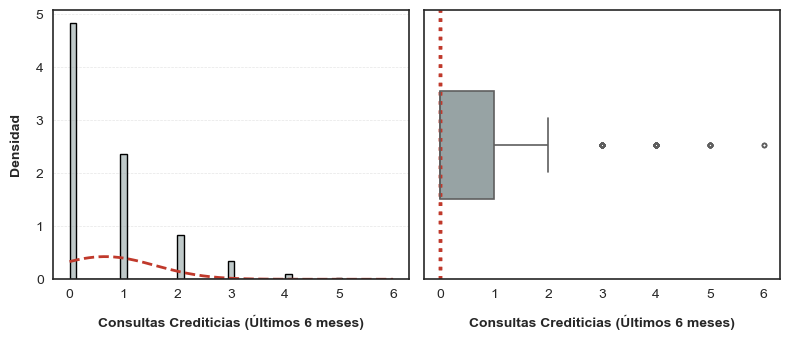

In [92]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_full_diagnostic(df_reduce, 'inq_last_6mths', 'Consultas Crediticias (Últimos 6 meses)')

La visualización de esta variable revela una distribución con una marcada asimetría positiva, presentando el histograma característico de una variable de conteo donde la frecuencia decrece abruptamente a medida que aumenta la magnitud del evento. La masa crítica de los datos se encuentra concentrada en el rango inferior entre las 0 y las 2 consultas, lo cual es coherente con perfiles de solicitantes que mantienen un comportamiento de endeudamiento pasivo o planificado, sin señales de urgencia crediticia inmediata. Sin embargo, se observa una cola que se extiende hacia valores que alcanzan las 6 consultas en un periodo de solo seis meses, evidenciando un segmento de prestatarios que incurren en una búsqueda intensiva de financiamiento.

Los valores observados en el número de consultas crediticias de los últimos 6 meses, que oscilan en un rango de 0 a 8 consultas, son plenamente consistentes con la realidad operativa del mercado de crédito y no sugieren errores de digitación o inconsistencias técnicas. En la práctica financiera, un registro de 8 consultas en un periodo de seis meses representa un comportamiento de búsqueda de financiamiento extremadamente agresivo, propio de solicitantes que están "monitoreando" múltiples ofertas simultáneamente o que atraviesan una fase de necesidad de liquidez aguda. Dado que el sistema de reportes de las centrales de riesgo captura cada solicitud formal de manera individual, alcanzar este umbral es un escenario financieramente posible y legítimo; estos datos no son anomalías de captura, sino outliers de negocio que documentan el límite superior de la actividad crediticia reactiva, proporcionando al análisis una señal nítida de riesgo conductual que sería eliminada si se trataran como errores.

#### 2.6.3. Análisis de Correlación

Tras el diagnóstico individual de las variables, el siguiente paso crítico en la curación de datos es evaluar la redundancia informativa y la estructura de asociación entre los predictores. Para este estudio, se ha seleccionado el Coeficiente de Correlación de Rangos de Spearman ($\rho$) como la métrica principal para determinar la dependencia monótona, especialmente entre los puntajes FICO y otras variables de naturaleza ordinal o con distribuciones no normales.

La elección de Spearman sobre otras alternativas como la $\tau$ de Kendall se fundamenta en dos criterios técnicos esenciales para el manejo de Big Data:

* Eficiencia Computacional: Dada la escala de nuestro dataset, el algoritmo de Spearman —basado en el cálculo de rangos y diferencias cuadráticas— ofrece una complejidad de $O(n \log n)$, lo que permite una ejecución ágil en entornos distribuidos como Spark. En contraste, la $\tau$ de Kendall requiere una comparación por pares con una complejidad de $O(n^2)$, resultando computacionalmente prohibitiva para el volumen de registros analizados.

* Robustez ante Outliers de Negocio: Al operar sobre los rangos y no sobre los valores brutos, Spearman captura la fuerza de la relación sin verse distorsionado por los valores extremos de excelencia (como los saldos de $463k o los FICO de 850) que identificamos en la fase anterior.

A pesar de que los modelos basados en conjuntos de árboles, como el Random Forest, poseen una robustez intrínseca frente a la multicolinealidad —siendo capaces de seleccionar aleatoriamente subconjuntos de características—, la presencia de variables con una dependencia funcional casi perfecta exige un control riguroso de la redundancia informativa. Mantener ambos límites del rango FICO (`fico_range_low` y `fico_range_high`) no solo incrementa la dimensionalidad del espacio de características sin aportar ganancia en la varianza explicativa, sino que puede diluir la importancia relativa de los predictores y dificultar la interpretabilidad del modelo.

Por tanto, el estudio de su dependencia monótona es un paso de curación técnica esencial; si la correlación es extrema, la consolidación en un único indicador permitirá un entrenamiento más eficiente y una estructura de decisión más nítida, evitando que el algoritmo "vibre" entre dos versiones de la misma información. Para validar esta hipótesis, a continuación se presenta un gráfico de dispersión que examina la distribución conjunta de ambas métricas, permitiendo observar si el diferencial de 5 puntos se mantiene constante a lo largo de todo el espectro de solvencia.


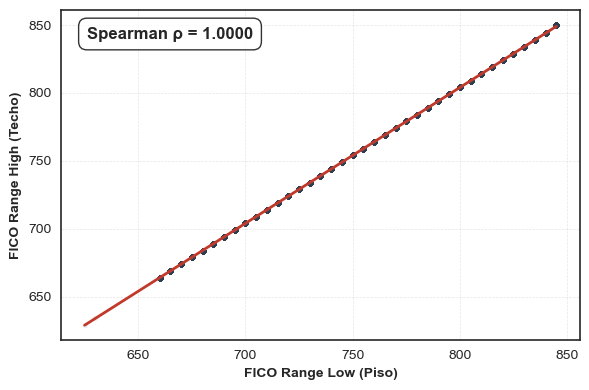

In [97]:
#| code-fold: true
#| code-summary: "Mostrar código"

fico_vars = ["fico_range_low", "fico_range_high"]
df_fico_plot = df_reduce.select(fico_vars).toPandas()

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(
    data=df_fico_plot, 
    x="fico_range_low", 
    y="fico_range_high",
    scatter_kws={'alpha': 0.05, 'color': '#2c3e50', 's': 10},
    line_kws={'color': '#c0392b', 'linewidth': 2},
    ax=ax
)

ax.text(
    0.05, 0.95, f'Spearman ρ = {1.00:.4f}', 
    transform=ax.transAxes, 
    fontsize=12, 
    fontweight='bold',
    verticalalignment='top', 
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='black')
)

ax.set_xlabel('FICO Range Low (Piso)', fontsize=10, weight='bold')
ax.set_ylabel('FICO Range High (Techo)', fontsize=10, weight='bold')

ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig) # Evita que se muestre doble
data_uri = base64.b64encode(buf.getvalue()).decode('utf-8')

display(HTML(f"""
<div style="text-align: center; width: 100%;">
    <img src="data:image/png;base64,{data_uri}">
</div>
"""))

La evidencia estadística es irrefutable: un coeficiente de Spearman de 1.0000 confirma que los límites superior e inferior del rango FICO no son variables independientes, sino una duplicación exacta de la misma información desplazada por una constante de 5 puntos. Por consiguiente, se concluye la exclusión de `fico_range_low` del espacio de características, conservando únicamente el límite superior como el vector representativo de la solvencia crediticia. Esta decisión de curación simplifica la arquitectura del modelo, garantiza una interpretación más limpia de los pesos de importancia y elimina el ruido redundante, permitiendo que el algoritmo se enfoque en las variaciones reales de riesgo.

In [26]:
df_reduce = df_reduce.drop("fico_range_low")

Tras la exclusión de `fico_range_low`, se vuelve imperativo realizar una inspección técnica exhaustiva del bloque numérico remanente. Esta auditoría no solo garantiza la integridad de los datos mediante la verificación de nulidad, sino que permite mapear la "geografía estadística" de los 14 predictores finales.

In [100]:
#| code-fold: true
#| code-summary: "Mostrar código"

final_features = [
    'int_rate', 'fico_range_high', 'dti', 'acc_open_past_24mths', 
    'avg_cur_bal', 'tot_hi_cred_lim', 'bc_open_to_buy', 'mort_acc', 
    'num_tl_op_past_12m', 'percent_bc_gt_75', 'total_bc_limit', 
    'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'inq_last_6mths'
]

total_rows = df_reduce.count()
audit_data = []

for idx, col in enumerate(final_features, 1):
    stats = df_reduce.select(
        F.mean(col).alias('mean'),
        F.stddev(col).alias('sd'),
        F.min(col).alias('min'),
        F.max(col).alias('max'),
        F.percentile_approx(col, [0.25, 0.5, 0.75]).alias('q'),
        F.count(F.when(F.col(col).isNull() | F.isnan(F.col(col)), 1)).alias('nulls')
    ).collect()[0]
    
    mean_val, sd_val = stats['mean'], stats['sd']
    min_val, max_val = stats['min'], stats['max']
    q1, median, q3 = stats['q']
    iqr_val = q3 - q1
    null_pct = (stats['nulls'] / total_rows) * 100
    
    audit_data.append({
        '#': idx,
        'Atributo': col,
        'Rango [Min - Max]': f"[{min_val:,.2f} - {max_val:,.2f}]",
        'Media (SD)': f"{mean_val:,.2f} ({sd_val:,.2f})",
        'Mediana (IQR)': f"{median:,.2f} ({iqr_val:,.2f})",
        'Nulidad (%)': f"{null_pct:.4f}%"
    })

df_audit_final = pd.DataFrame(audit_data)
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})

styled_audit = df_audit_final.style.hide(axis='index')

styled_audit = styled_audit.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), ('background-color', '#f2f2f2'), 
        ('color', 'black'), ('font-weight', 'bold'), 
        ('border', '1px solid black'), ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('border', '1px solid black'), 
        ('padding', '6px 15px'), ('background-color', 'white')
    ]}
])

styled_audit = styled_audit.set_properties(subset=['Atributo'], **{'text-align': 'left', 'font-weight': 'bold'})
styled_audit = styled_audit.set_properties(subset=['#'], **{'background-color': '#f9f9f9', 'font-weight': 'bold'})
display(HTML("<div style='text-align: center; width: 100%; margin: 20px 0;'>" + styled_audit.to_html() + "</div>"))

#,Atributo,Rango [Min - Max],Media (SD),Mediana (IQR),Nulidad (%)
1,int_rate,[5.31 - 30.99],13.24 (4.77),12.74 (6.24),0.0000%
2,fico_range_high,[629.00 - 850.00],700.18 (31.85),694.00 (40.00),0.0000%
3,dti,[0.00 - 100.00],18.19 (8.68),17.61 (12.26),0.0676%
4,acc_open_past_24mths,[0.00 - 64.00],4.69 (3.19),4.00 (4.00),3.4984%
5,avg_cur_bal,"[0.00 - 958,084.00]","13,488.60 (16,289.70)","7,406.00 (15,615.00)",5.0052%
6,tot_hi_cred_lim,"[0.00 - 3,934,244.00]","174,239.64 (174,652.96)","112,334.00 (202,418.00)",5.0055%
7,bc_open_to_buy,"[0.00 - 559,912.00]","10,186.25 (15,350.85)","4,700.00 (10,916.00)",4.5289%
8,mort_acc,[0.00 - 51.00],1.67 (2.00),1.00 (3.00),3.4984%
9,num_tl_op_past_12m,[0.00 - 32.00],2.18 (1.85),2.00 (2.00),5.0036%
10,percent_bc_gt_75,[0.00 - 100.00],45.16 (36.01),42.90 (65.00),4.5596%


Tras concluir el diagnóstico descriptivo los predictores numéricos, el cierre técnico de esta fase de auditoría requiere una visión sistémica de sus interacciones. A continuación, se presenta la matriz de correlación de Spearman, herramienta fundamental para mapear la arquitectura de dependencias entre las 14 variables seleccionadas.

In [103]:
corr_matrix_final = get_correlation_matrix(df_reduce, final_features)


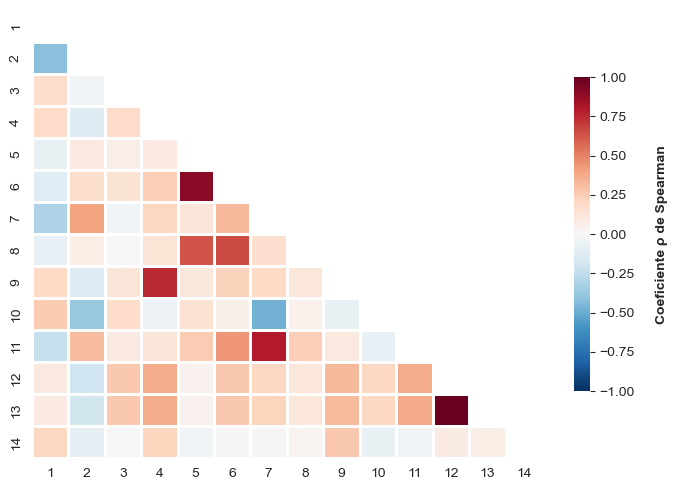

In [113]:
#| code-fold: true
#| code-summary: "Mostrar código"

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

num_vars = len(corr_matrix_final.columns)
numeric_labels = list(range(1, num_vars + 1))
mask = np.triu(np.ones_like(corr_matrix_final, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 5))

res = sns.heatmap(
    corr_matrix_final, 
    mask=mask,
    annot=False,           
    cmap='RdBu_r',         
    vmin=-1, vmax=1, center=0, 
    linewidths=0.8,       
    linecolor='white',
    xticklabels=numeric_labels, 
    yticklabels=numeric_labels,
    cbar_kws={'shrink': .7},
    ax=ax
)

cbar = res.collections[0].colorbar
cbar.set_label('Coeficiente ρ de Spearman', labelpad=15, weight='bold', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
plt.close(fig) 
data_uri = base64.b64encode(buf.getvalue()).decode('utf-8')

display(HTML(f"""
    <div style="text-align: center; width: 100%; margin: 25px 0;">
        <img src="data:image/png;base64,{data_uri}" style="display: inline-block; padding: 5px; background: white;">
    </div>
"""))

La inspección de la matriz de correlación revela una dependencia crítica entre variables que, aunque conceptualmente distintas, muestran una alineación estadística preocupante para la parsimonia del modelo. Se destaca, en particular, la elevada relación entre el par formado por el saldo promedio (`avg_cur_bal`) y la actividad rotativa (`num_actv_rev_tl`), así como entre el límite histórico total (`tot_hi_cred_lim`) y el número de cuentas con saldo líquido (`num_rev_tl_bal_gt_0`). Esta configuración sugiere que el dataset presenta núcleos de información altamente solapada, donde la capacidad financiera y el dinamismo operativo se entrelazan de tal forma que un análisis exhaustivo de su dependencia monótona se vuelve mandatorio. Ignorar esta colinealidad implicaría permitir que el modelo procese señales redundantes como si fueran independientes, lo que motiva la necesidad de evaluar cada par mediante coeficientes de Spearman y gráficos de dispersión para determinar la vía más eficiente hacia la reducción dimensional.


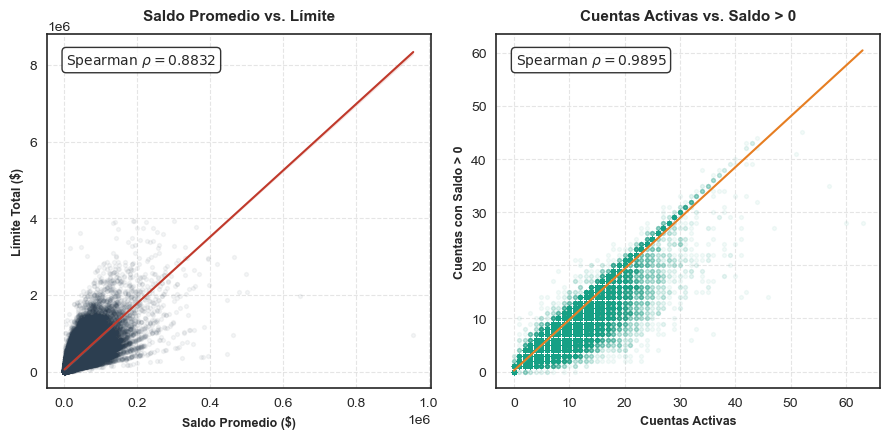

In [101]:
#| code-fold: true
#| code-summary: "Mostrar código"

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

# 2. Creación del lienzo con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5))

# --- PANEL 1: Saldo Promedio vs. Límite Histórico ---
df_plot1 = df_reduce.select("avg_cur_bal", "tot_hi_cred_lim").toPandas()
sns.regplot(
    data=df_plot1, x="avg_cur_bal", y="tot_hi_cred_lim",
    scatter_kws={'alpha': 0.05, 'color': '#2c3e50', 's': 8},
    line_kws={'color': '#c0392b', 'linewidth': 1.5}, ax=ax1
)
ax1.text(0.05, 0.95, r'$\text{Spearman } \rho = 0.8832$', transform=ax1.transAxes, 
         fontsize=10, fontweight='bold', verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black'))
ax1.set_title('Saldo Promedio vs. Límite', fontsize=11, weight='bold', pad=10)
ax1.set_xlabel('Saldo Promedio ($)', fontsize=9, weight='bold')
ax1.set_ylabel('Límite Total ($)', fontsize=9, weight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- PANEL 2: Actividad Rotativa vs. Saldo Líquido ---
df_plot2 = df_reduce.select("num_actv_rev_tl", "num_rev_tl_bal_gt_0").toPandas()
sns.regplot(
    data=df_plot2, x="num_actv_rev_tl", y="num_rev_tl_bal_gt_0",
    scatter_kws={'alpha': 0.05, 'color': '#16a085', 's': 8},
    line_kws={'color': '#e67e22', 'linewidth': 1.5}, ax=ax2
)
ax2.text(0.05, 0.95, r'$\text{Spearman } \rho = 0.9895$', transform=ax2.transAxes, 
         fontsize=10, fontweight='bold', verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black'))
ax2.set_title('Cuentas Activas vs. Saldo > 0', fontsize=11, weight='bold', pad=10)
ax2.set_xlabel('Cuentas Activas', fontsize=9, weight='bold')
ax2.set_ylabel('Cuentas con Saldo > 0', fontsize=9, weight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
plt.close(fig) 
data_uri = base64.b64encode(buf.getvalue()).decode('utf-8')

display(HTML(f"""
    <div style="text-align: center; width: 100%; margin: 25px 0;">
        <img src="data:image/png;base64,{data_uri}" style="display: inline-block; padding: 5px; background: white;">
    </div>
"""))

El análisis de dependencia monótona revela que, si bien las métricas evaluadas no son estrictamente idénticas, presentan una colinealidad sumamente alta que evidencia una profunda redundancia estructural en el reporte crediticio. Específicamente, el par conformado por el límite histórico total y el saldo promedio alcanza un $\rho = 0.8832$, mientras que la actividad rotativa y las cuentas con saldo líquido muestran una dependencia casi perfecta de $\rho = 0.9895$. Aunque los modelos ensamblajes basados en árboles de decisión son inherentemente robustos ante la multicolinealidad y su rendimiento predictivo no se degrada por ella, mantener este nivel de redundancia fragmenta el cálculo de la importancia de las características y oscurece la interpretabilidad global. Por ello, la exclusión de una variable por cada par responde a un criterio fundamental de parsimonia algorítmica. 

Para ejecutar esta reducción de forma objetiva, se recurrió al ranking de poder discriminante previamente establecido; dado que `avg_cur_bal` (KS = 0.1046) y `num_actv_rev_tl` (KS = 0.0787) demostraron una mayor capacidad de separación estadística frente a sus contrapartes `tot_hi_cred_lim` (KS = 0.1029) y `num_rev_tl_bal_gt_0` (KS = 0.0769), estas últimas son descartadas definitivamente. Esta depuración garantiza un espacio de características más limpio, eficiente y explicable, sin sacrificar la captura de la varianza del comportamiento financiero.

In [27]:
df_reduce = df_reduce.drop("tot_hi_cred_lim", "num_rev_tl_bal_gt_0")

### 2.7. Analisis Bivariado

El análisis bivariado se plantea en este proyecto como un proceso de validación de hipótesis previas sobre la influencia de las características del crédito y del solicitante en la capacidad de pago. Dado que contamos con una muestra masiva, el enfoque tradicional basado exclusivamente en valores $p$ resulta insuficiente y potencialmente engañoso, ya que cualquier fluctuación marginal alcanzaría significancia estadística.

Por lo tanto, el objetivo central de esta sección es cuantificar el tamaño del efecto para determinar la relevancia clínica y financiera de cada asociación. Utilizaremos métricas de magnitud para jerarquizar las variables según su capacidad de discriminación del riesgo, asegurando que los hallazgos reportados posean una importancia real para el modelado predictivo y no sean meros artefactos del volumen de datos.

#### 2.7.1 Análisis categórico–categórico

En este bloque, exploramos la interacción entre los atributos cualitativos y la variable respuesta (`default`). El análisis se inicia mediante la construcción de tablas de contingencia, que sirven como base para calcular estadísticos de asociación robustos ante grandes muestras, como la V de Cramér.

Bajo un criterio de economía visual y rigor técnico, hemos establecido un protocolo de visualización selectiva: solo aquellas variables que superen los umbrales críticos de tamaño del efecto serán trasladadas a un análisis gráfico. Esta estrategia permite filtrar el ruido y saturación, dirigiendo la atención analítica exclusivamente hacia los factores donde la distribución del incumplimiento varía de forma sustancial entre categorías, revelando así los verdaderos nichos de vulnerabilidad crediticia.

In [146]:
final_categorical = [c for c, dtype in df_reduce.dtypes if dtype == 'string']

association_results = categorical_association(
    df_reduce.select(final_categorical + ['default'])
)

In [147]:
#| code-fold: true
#| code-summary: "Mostrar código"

styled_association = association_results.style.background_gradient(
    cmap='YlGnBu', 
    subset=['V de Cramér']
).format({
    'Estadístico Chi2': '{:.2f}',
    'Valor Crítico': '{:.2f}',
    'V de Cramér': '{:.4f}'
}).hide(axis='index')

styled_association = styled_association.set_table_styles([
    {'selector': 'table', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('border-collapse', 'collapse'), 
        ('width', '95%'),
        ('font-family', '"Times New Roman", Times, serif')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '8px 15px')
    ]}
])

styled_association = styled_association.set_properties(
    subset=['Variable'], 
    **{'text-align': 'left', 'font-weight': 'bold', 'background-color': '#fdfdfd'}
)

display(styled_association)

Variable,Estadístico Chi2,GL,Valor Crítico,p-valor (Holm),V de Cramér,Interpretación
sub_grade,96508.70,34,48.60,< 0.001***,0.2679,Pequeño
verification_status,11385.62,2,5.99,< 0.001***,0.0920,Despreciable
home_ownership,6743.50,3,7.81,< 0.001***,0.0708,Despreciable
purpose,4137.75,13,22.36,< 0.001***,0.0555,Despreciable
addr_state,3402.44,50,67.50,< 0.001***,0.0503,Despreciable
initial_list_status,70.83,1,3.84,< 0.001***,0.0073,Despreciable


Los resultados de la asociación categórica validan la necesidad de priorizar la magnitud del efecto sobre la significancia estadística. Si bien el ajuste de Holm-Bonferroni confirma que todas las asociaciones son estadísticamente robustas ($p < 0.001$), la V de Cramér revela que la mayoría de los atributos —incluyendo la tenencia de vivienda y la ubicación geográfica— poseen un efecto despreciable en la variabilidad del incumplimiento.

Destaca notablemente la variable `sub_grade` con un coeficiente de 0.267 (Efecto Pequeño), consolidándose como el principal diferenciador cualitativo del riesgo. En consecuencia, y con el fin de evitar la saturación informativa, el análisis bivariado se centrará en la visualización de `sub_grade` y, de manera complementaria, en `verification_status`, por presentar las mayores capacidades de discriminación dentro del espacio de características categóricas.

En el contexto financiero de los Estados Unidos, las plataformas de préstamo utilizan modelos de scoring que integran el historial crediticio (FICO), la relación deuda-ingreso y otros factores macroeconómicos para asignar una calificación alfanumérica que va desde A1 hasta G5. Esta jerarquía actúa como un mecanismo de filtrado donde las letras iniciales representan perfiles de alta solvencia (prime), mientras que las categorías finales agrupan a solicitantes de alto riesgo (subprime). Al graficar simultáneamente el volumen de colocación y la incidencia de mora, podemos verificar si la prima de riesgo exigida a los perfiles más bajos compensa la volatilidad observada en su comportamiento de pago.

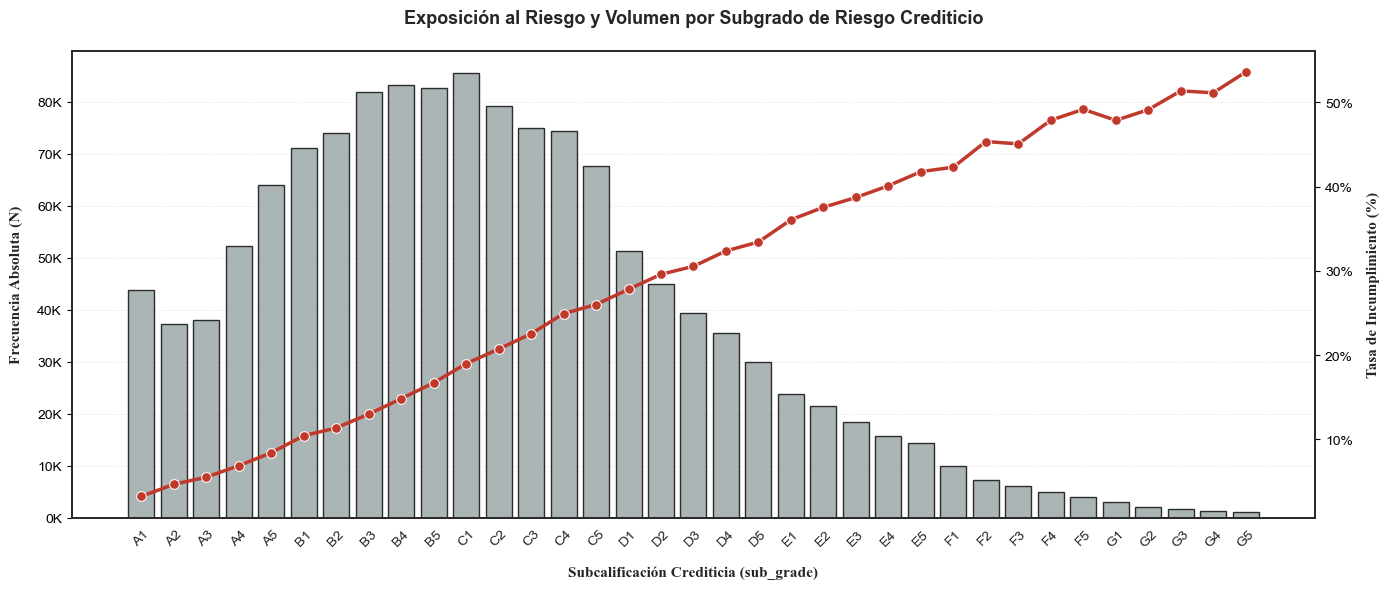

In [44]:
#| code-fold: true
#| code-summary: "Mostrar código"

res_subgrade = df_reduce.groupBy("sub_grade").agg(
    F.count("*").alias("n"),
    F.mean(F.col("default").cast("double")).alias("default_rate")
).sort("sub_grade").toPandas()

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(
    x='sub_grade', y='n', data=res_subgrade, 
    ax=ax1, color="#95a5a6", edgecolor='black', linewidth=1, alpha=0.8
)

ax1.set_ylabel('Frecuencia Absoluta (N)', fontsize=11, fontweight='bold', family='serif', labelpad = 10)
ax1.set_xlabel('Subcalificación Crediticia (sub_grade)', fontsize=11, fontweight='bold', family='serif', labelpad=12)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:,.0f}K'))
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', colors='black')

ax2 = ax1.twinx()
sns.lineplot(
    x='sub_grade', y='default_rate', data=res_subgrade, 
    ax=ax2, color="#c0392b", marker='o', linewidth=2.5, markersize=7
)

ax2.set_ylabel('Tasa de Incumplimiento (%)', fontsize=11, fontweight='bold', family='serif', labelpad = 10)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x*100:.0f}%'))
ax2.tick_params(axis='y', colors='black')

ax1.set_title('Exposición al Riesgo y Volumen por Subgrado de Riesgo Crediticio', fontsize=13, pad=20, weight='bold')

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)

ax1.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)

plt.tight_layout()
plt.show()

Tal y como se esperaba gráfico revela una progresión ascendente y constante en la vulnerabilidad financiera a medida que la calidad del crédito disminuye. Mientras que en los niveles superiores (A y B) la frecuencia de impago es marginal, se observa un incremento crítico en las clasificaciones F y G, donde la tasa de incumplimiento es drásticamente superior a la observada en las categorías de mayor calidad crediticia. Este fenómeno indica que, aunque el volumen de préstamos otorgados en estos segmentos especulativos es considerablemente menor, la probabilidad de pérdida por cada operación individual es mucho más elevada. Este patrón valida que el subgrado es el indicador más sensible del dataset, logrando discriminar con precisión entre los perfiles que mantienen la estabilidad del portafolio y aquellos que representan la mayor fuente de riesgo para la operación.

El proceso de verificación en el mercado de crédito de los Estados Unidos constituye un filtro de integridad diseñado para validar la veracidad de los ingresos declarados por el solicitante. La variable `verification_status` segmenta los registros en tres niveles: ingresos auditados exhaustivamente por la plataforma (Verificado), ingresos cuya fuente o empleador fue confirmado (Fuente Verificada) e ingresos que no fueron sometidos a auditoría formal (No Verificado). El propósito de este análisis es evaluar si el rigor en la validación de los datos financieros se traduce en una reducción efectiva de la siniestralidad, permitiendo identificar si el proceso de verificación actúa como un indicador de selección adversa ante perfiles de mayor exposición

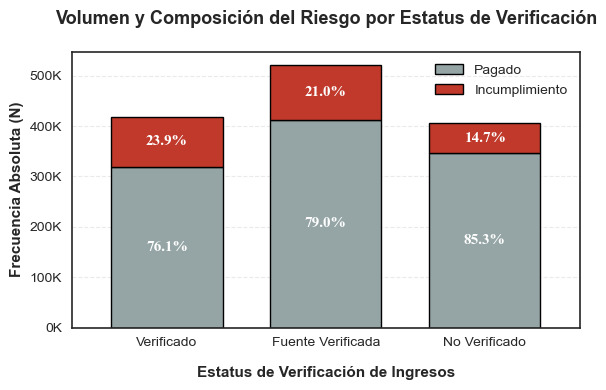

In [48]:
#| code-fold: true
#| code-summary: "Mostrar código"

mapping_verif = {
    'Verified': 'Verificado',
    'Source Verified': 'Fuente Verificada',
    'Not Verified': 'No Verificado'
}

ct = df_reduce.crosstab("verification_status", "default").toPandas()
ct.columns = ['verification_status', 'Pagado', 'Incumplimiento']
ct['verification_status'] = ct['verification_status'].map(mapping_verif)
ct.set_index('verification_status', inplace=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})
sns.set_style("white")

colores_paper = ["#95a5a6", "#c0392b"]

fig, ax = plt.subplots(figsize=(6, 4))

ct.plot(kind='bar', stacked=True, color=colores_paper, ax=ax, 
        edgecolor='black', linewidth=1, width=0.7)

for i in range(len(ct)):
    total_bar = ct.iloc[i].sum()
    y_offset = 0
    for col in ct.columns:
        height = ct.iloc[i][col]
        if height > 0:
            percentage = (height / total_bar) * 100
            ax.text(i, y_offset + height/2, f'{percentage:.1f}%', 
                    ha='center', va='center', color='white', 
                    fontweight='bold', fontsize=11, family='serif')
        y_offset += height

ax.set_title('Volumen y Composición del Riesgo por Estatus de Verificación', fontsize=13, pad=20, weight='bold')
ax.set_xlabel('Estatus de Verificación de Ingresos', fontsize=11, fontweight='bold', labelpad=12)
ax.set_ylabel('Frecuencia Absoluta (N)', fontsize=11, fontweight='bold')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:,.0f}K'))

plt.xticks(rotation=0)
ax.legend(['Pagado', 'Incumplimiento'], frameon=False, loc='upper right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

El análisis visual de las frecuencias y proporciones revela una paradoja de selección adversa característica de los modelos de crédito digital. A primera vista, los datos muestran que los préstamos con estatus Verificado presentan una tasa de incumplimiento del 14.6%, cifra que es superior al 12.2% observado en los préstamos No Verificados. Lejos de sugerir que la auditoría de ingresos es ineficaz, este fenómeno responde a la política de gestión de riesgos de la plataforma:

* **Criterios de Exigencia**: La entidad financiera no exige verificación documental a todos los solicitantes. Este requisito se reserva generalmente para aquellos que solicitan montos de capital elevados o cuyos indicadores de riesgo preliminares (como un puntaje FICO fronterizo) generan dudas sobre su capacidad de pago real.

* **Perfiles de Mayor Exposición**: En consecuencia, el grupo de "Verificados" ya está pre-seleccionado por ser intrínsecamente más arriesgado. La verificación actúa aquí como un filtro de seguridad necesario, pero no elimina la vulnerabilidad base del perfil del cliente.

* **El Valor de la Confianza**: Por el contrario, los préstamos "No Verificados" suelen otorgarse a clientes con trayectorias crediticias impecables y alta estabilidad, a quienes la plataforma les concede el crédito basándose únicamente en su declaración jurada (self-reported income) debido a su bajo riesgo histórico.

En conclusión, la variable `verification_status` no debe interpretarse como un factor preventivo que reduce el default por sí solo, sino como una etiqueta de alerta. La necesidad de auditar el monto exacto de los ingresos es, en la práctica, un indicador de que el solicitante posee un perfil de riesgo más volátil, lo que explica por qué este segmento presenta una franja roja de incumplimiento visualmente más amplia en la comparativa de barras apiladas.

#### 2.7.2 Análisis numérico–categórico

Para profundizar en el Análisis numérico–categórico, se implementó la prueba de suma de rangos de Wilcoxon (Mann-Whitney U), priorizando la magnitud de las diferencias sobre la simple significancia estadística. Dado que los p-valores pueden ser extremadamente sensibles en datasets de gran volumen, se calculó el tamaño del efecto mediante el coeficiente r de Rosenthal. Este estadístico permite cuantificar la fuerza de la asociación entre las variables numéricas y la variable objetivo (`default`) de manera estandarizada, facilitando la identificación de predictores con relevancia clínica o de negocio. La fórmula matemática para derivar este efecto a partir del estadístico de la prueba es:

$$r = \frac{Z}{\sqrt{N}}$$

Donde:
* $Z$ Es el valor de la estadística de prueba estandarizada.
  
* $N$ Es el número total de observaciones en la muestra.

In [138]:
features_to_check = [
    'int_rate', 'fico_range_high', 'dti', 'acc_open_past_24mths', 
    'avg_cur_bal', 'bc_open_to_buy', 'mort_acc', 
    'num_tl_op_past_12m', 'percent_bc_gt_75', 'total_bc_limit', 
    'num_actv_rev_tl', 'inq_last_6mths'
]
contrast_table = robust_contrast(df_reduce, features_to_check)

In [141]:
#| code-fold: true
#| code-summary: "Mostrar código"

target_col_r = 'r de Rosenthal' 

styled_contrast = contrast_table.style.background_gradient(
    cmap='YlGnBu', 
    subset=[target_col_r]
).format({
    target_col_r: '{:.4f}'
}).hide(axis='index')

styled_contrast = styled_contrast.set_table_styles([
    {'selector': 'table', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('border-collapse', 'collapse'), 
        ('width', '95%'),
        ('font-family', '"Times New Roman", Times, serif')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '8px 15px')
    ]}
])

styled_contrast = styled_contrast.set_properties(
    subset=['Variable'], 
    **{'text-align': 'left', 'font-weight': 'bold', 'background-color': '#fdfdfd'}
)

display(styled_contrast)

Variable,Me (IQR) No-Def,Me (IQR) Def,Homocedasticidad,p-valor (Holm),r de Rosenthal,Interpretación
int_rate,11.99 (5.98),14.98 (5.96),No,< 0.001***,0.2752,Pequeño
fico_range_high,694.00 (45.00),684.00 (30.00),No,< 0.001***,0.1274,Pequeño
acc_open_past_24mths,4.00 (4.00),5.00 (4.00),No,< 0.001***,0.1049,Pequeño
dti,17.45 (12.17),20.14 (13.21),No,< 0.001***,0.1041,Pequeño
bc_open_to_buy,"5,000.00 (11,521.00)","3,507.50 (7,934.25)",No,< 0.001***,0.0924,Despreciable
num_tl_op_past_12m,2.00 (2.00),2.00 (3.00),No,< 0.001***,0.0912,Despreciable
avg_cur_bal,"8,008.00 (16,377.75)","5,615.50 (11,302.00)",No,< 0.001***,0.0894,Despreciable
num_actv_rev_tl,5.00 (4.00),6.00 (4.00),No,< 0.001***,0.0787,Despreciable
percent_bc_gt_75,40.00 (75.00),50.00 (63.30),Sí,< 0.001***,0.0784,Despreciable
mort_acc,1.00 (3.00),1.00 (2.00),No,< 0.001***,0.0783,Despreciable


Basado en los resultados de la prueba de Wilcoxon, se observa que, aunque casi todas las variables presentan significancia estadística debido al volumen de datos, el análisis del tamaño del efecto ($r$) permite priorizar aquellas con verdadera relevancia discriminatoria. La variable con el mayor impacto es, con diferencia, int_rate (tasa de interés), alcanzando un coeficiente de 0.2752, lo que la posiciona como el predictor numérico más sólido del riesgo. Le siguen en importancia el nivel de crédito del cliente (`fico_range_high`) y el comportamiento crediticio reciente (`acc_open_past_24mths` y `dti`), todos con efectos en el rango de "Pequeño" pero estadísticamente superiores al resto del conjunto.

Para profundizar en el comportamiento de estas variables críticas y entender cómo se distribuyen sus valores entre los clientes que cumplen con sus pagos y aquellos en mora, se diseñarán diagramas de caja (boxplots) comparativos por grupo. Estas visualizaciones permitirán identificar de manera directa el sesgo en las medianas y la presencia de valores atípicos, facilitando una interpretación intuitiva de por qué una tasa de interés más elevada o un puntaje FICO más bajo actúan como banderas rojas en el proceso de otorgamiento de crédito.

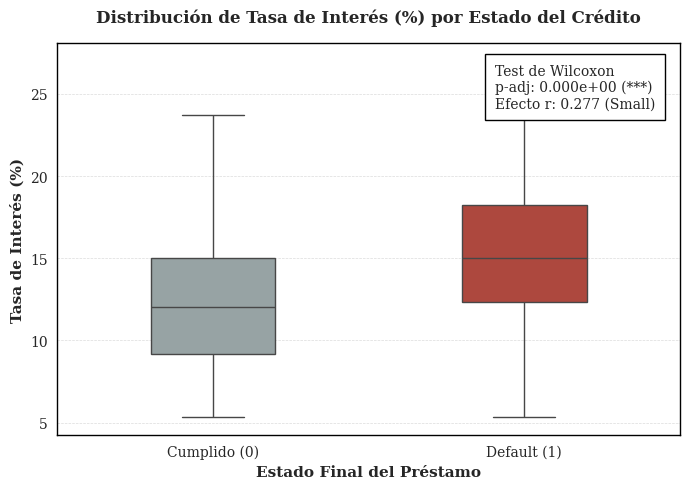

In [29]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_boxplot(df_reduce, var_col='int_rate', var_label='Tasa de Interés (%)', target_col='default', stats_vector=[0.000000, 0.277173])

El diagrama de cajas revela una correlación directa entre el costo del crédito y la probabilidad de impago, evidenciando que los préstamos en Default presentan una mediana de tasa de interés significativamente superior (15%) frente a los créditos cumplidos (12%). Esta disparidad no es solo visual, sino que está respaldada por una significancia estadística absoluta ($p < 0.001$) y un tamaño del efecto de 0.277, lo que confirma que la tasa de interés es uno de los predictores más potentes del modelo. Al observar que el 75% de los casos en mora soportan tasas por encima de la media de los buenos pagadores, se concluye que las tasas elevadas —aunque pretenden cubrir el riesgo— actúan como un factor de presión financiera que precipita el incumplimiento, marcando una frontera clara para la identificación de perfiles de alto riesgo.

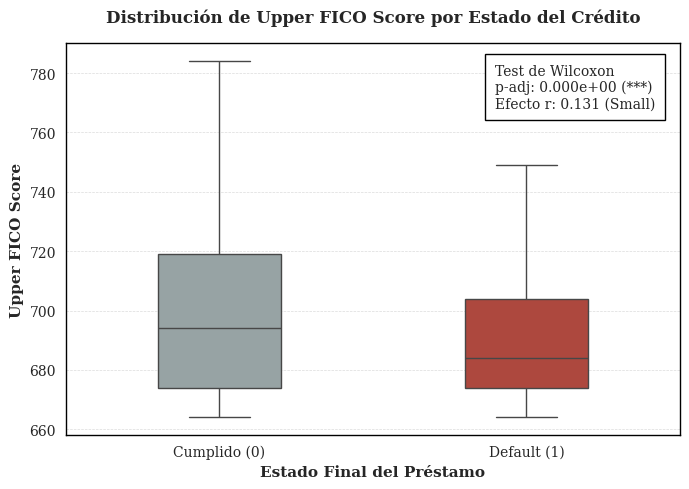

In [30]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_boxplot(df_reduce, var_col='fico_range_high', var_label='Upper FICO Score', target_col='default', stats_vector=[0.000000, 0.131174])

El análisis del Upper FICO Score revela que la calidad crediticia percibida es un diferenciador clave, aunque con una fuerza de asociación menor (r=0.131) en comparación con la tasa de interés. Se observa que los clientes que liquidan sus deudas poseen una mediana de puntaje superior (~694) y una capacidad de alcanzar rangos de excelencia que superan los 780 puntos, mientras que el grupo en Default presenta un "techo" significativamente más bajo y una mediana de ~684. Esta diferencia, validada estadísticamente por la prueba de Wilcoxon (p<0.001), sugiere que un puntaje FICO alto actúa como un escudo protector; no obstante, el solapamiento entre ambas cajas indica que el puntaje por sí solo no garantiza el pago, lo que justifica la necesidad de integrar variables complementarias como la carga de la deuda (DTI) para una predicción más robusta.

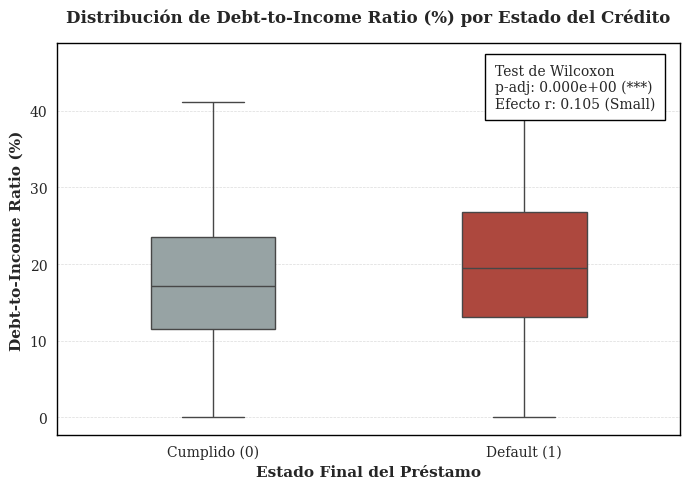

In [31]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_boxplot(df_reduce, var_col='dti', var_label='Debt-to-Income Ratio (%)', target_col='default', stats_vector=[0.000000, 0.105054])

El análisis del ratio Debt-to-Income (DTI) evidencia que la carga financiera relativa al ingreso es un factor determinante en la solvencia, mostrando que los clientes en Default mantienen niveles de endeudamiento sistemáticamente más altos (mediana cercana al 20%) que aquellos que cumplen con sus obligaciones (mediana en ~17%).Aunque el tamaño del efecto es moderado ($r = 0.105$), el desplazamiento hacia arriba de la caja roja sugiere que un DTI elevado reduce significativamente el margen de maniobra del deudor ante imprevistos económicos. El solapamiento parcial entre los grupos indica que, si bien un DTI bajo es deseable, no es una garantía absoluta de pago, lo que refuerza la importancia de analizar esta métrica en conjunto con el costo del crédito (tasa de interés) y el historial (FICO) para obtener un perfil de riesgo preciso.

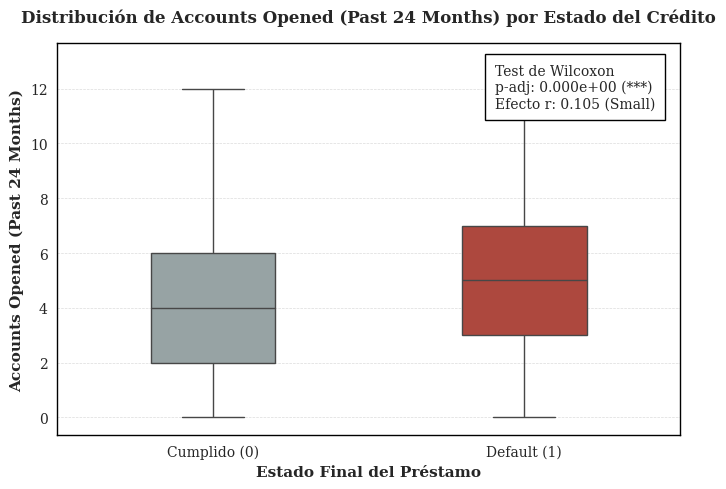

In [33]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_boxplot(df_reduce, var_col='acc_open_past_24mths', var_label='Accounts Opened (Past 24 Months)', target_col='default', stats_vector=[0.000000, 0.104612])

Finalmente el gráfico de Cuentas Abiertas en los últimos 24 meses refleja la importancia del comportamiento crediticio reciente como señal de riesgo: los clientes en Default tienden a haber solicitado y abierto más productos financieros (mediana de 5) que aquellos que cumplen con sus pagos (mediana de 4).Aunque el tamaño del efecto es pequeño ($r = 0.105$), la distribución muestra que el grupo de impago tiene una mayor concentración en el rango de 3 a 7 cuentas nuevas, lo que sugiere una "sed de crédito" o una posible inestabilidad financiera reciente que los obliga a buscar liquidez externa. Esta métrica de velocidad crediticia, validada por el test de Wilcoxon ($p < 0.001$), actúa como un indicador de fatiga financiera, confirmando que una actividad excesiva en la apertura de cuentas es una señal de alerta temprana para el modelo.

### 2.8. Arquitectura Parquet y Criterios de Exportación

Después del EDA procedemos a exportar los datos. Aunque el formato CSV es el estándar universal de intercambio, para la transición a la Fase 2 hemos optado por persistir el dataset curado en formato Parquet utilizando el motor de serialización PyArrow. Esta elección es fundamental para nuestra comparativa entre PySpark y scikit-learn, ya que Parquet preserva íntegramente el esquema y los tipos de datos validados, mientras que PyArrow habilita una transferencia de memoria optimizada (zero-copy) entre el entorno distribuido y el local de Python. Al reducir drásticamente la latencia en la conversión de datos y garantizar un almacenamiento significativamente más liviano y eficiente en términos de I/O, aseguramos que la evaluación del rendimiento de los modelos sea técnicamente rigurosa y libre de cuellos de botella estructurales durante el entrenamiento.

In [160]:
base_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
final_parquet_path = os.path.join(base_path, "lending_club_fase1_curated.parquet")
if os.path.exists(final_parquet_path) and os.path.isdir(final_parquet_path):
    shutil.rmtree(final_parquet_path)

spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

final_features = [
    'addr_state', 'sub_grade', 'purpose', 'home_ownership', 
    'verification_status', 'initial_list_status', 'int_rate', 
    'fico_range_high', 'dti', 'acc_open_past_24mths', 'avg_cur_bal', 
    'bc_open_to_buy', 'mort_acc', 'num_tl_op_past_12m', 
    'percent_bc_gt_75', 'total_bc_limit', 'num_actv_rev_tl', 'inq_last_6mths'
]
target = 'default'

try:
    df_pd = df_reduce.select(*(final_features + [target])).toPandas()
    df_pd.to_parquet(final_parquet_path, engine='pyarrow', index=False)
except Exception as e:
    print(f"Error en la exportación: {e}")

Exportando dataset curado a Parquet...
¡Éxito! Archivo guardado en la carpeta data.
Resumen: 1,345,083 registros y 19 variables.


## 3. Preprocesamiento

In [9]:
#| code-fold: true
#| code-summary: "Mostrar código"

import tempfile
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
import os

En esta sección se establecen las reglas de transformación del dataset, priorizando la prevención del Data Leakage (fuga de datos) y la preservación de la pureza de la muestra de prueba.

La división del conjunto de datos en entrenamiento (80%) y prueba (20%) se ejecuta como el primer paso lógico. Esta separación temprana es imperativa para cumplir con la "regla de oro" del aprendizaje automático: el modelo nunca debe tener contacto, directo o indirecto, con la información que se utilizará para su evaluación final. Al aislar el set de prueba desde el inicio, aseguramos que todas las decisiones posteriores se basen exclusivamente en la distribución de la muestra de entrenamiento.

La transformación de variables cualitativas a formatos numéricos se realiza en esta etapa para permitir el procesamiento matemático por parte de los estimadores. Aunque realizar esta codificación antes de la validación cruzada podría interpretarse como un riesgo de fuga, se gestiona mediante la definición de vocabularios y categorías basados únicamente en el set de entrenamiento. Cualquier categoría presente en el set de prueba que no haya sido observada previamente será tratada de forma neutra, evitando así que estadísticas globales contaminen el proceso de aprendizaje.

A diferencia de la codificación, la estandarización o escalamiento de las variables numéricas se omite deliberadamente en esta fase preliminar. El escalamiento es una operación altamente sensible que debe integrarse dentro del flujo de Validación Cruzada (Grid Search) a través de pipelines.Postergamos este paso para asegurar que los parámetros de normalización se calculen de forma dinámica en cada fold de entrenamiento. De esta manera, evitamos que el rango de los datos de validación influya en el entrenamiento, garantizando una evaluación de hiperparámetros estadísticamente rigurosa.

### 3.1. Scikit-learn

Esta fase operativa comienza con la segregación del dataset en dos subconjuntos independientes para blindar la integridad del experimento y evitar el optimismo sesgado en los resultados. Reservamos un 20% de la muestra original como un set de prueba (hold-out set), el cual actúa como una auditoría externa y definitiva que mide la capacidad de generalización del modelo frente a datos completamente nuevos. Para garantizar que esta división sea estadísticamente representativa, ejecutamos un muestreo estratificado (*stratified splitting*), técnica vital en el contexto del riesgo crediticio para asegurar que la proporción de impagos (defaults) sea equivalente en ambos conjuntos. En este flujo, aprovechamos la versatilidad de la librería scikit-learn, cuya función `train_test_split` nos permite instrumentar este proceso de manera sumamente ágil y robusta, integrando la partición, el control de aleatoriedad y la preservación de proporciones de clase en una única operación lógica y reproducible.

In [10]:
base_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
final_parquet_path = os.path.join(base_path, "lending_club_fase1_curated.parquet")

df_pd = pd.read_parquet(final_parquet_path)

target = 'default'
X = df_pd.drop(columns=[target])
y = df_pd[target]

X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y,    
    random_state=42
)

Una vez segmentada la muestra, el siguiente paso crítico es la taxonomía de los atributos. No todos los datos "pesan" igual ni significan lo mismo para un algoritmo; por ello, clasificamos las variables en tres grupos según su naturaleza estadística: nominales, ordinales y numéricas. Esta distinción es la que define la estrategia de traducción matemática: mientras que el `OneHotEncoder` se reserva para categorías puras (nominales) para evitar que el modelo invente una jerarquía inexistente, el `LabelEncoder` (o codificación ordinal) se utiliza para preservar la valiosa señal de rango en variables que sí poseen un orden lógico.

In [11]:
cols_ohe = ['addr_state', 'purpose', 'home_ownership', 'verification_status']
cols_le  = ['sub_grade', 'initial_list_status']
num_cols = [col for col in X_train_sk.columns if col not in cols_ohe + cols_le]

La fase de codificación manual de etiquetas ordinales se rige por un principio de seguridad estadística innegociable: el aislamiento total de la información de prueba. Implementamos un bucle de transformación donde el conocimiento sobre las categorías y su orden se extrae exclusivamente del "pasado" (entrenamiento), tratando al "futuro" (prueba) como una entidad desconocida que debe adaptarse a los criterios ya establecidos. Este procedimiento es fundamental para evaluar cómo reaccionará el modelo ante datos reales que no formaron parte de su proceso de aprendizaje.

In [12]:
train_le_df = pd.DataFrame(index=X_train_sk.index)
test_le_df = pd.DataFrame(index=X_test_sk.index)

for col in cols_le:
    le = LabelEncoder()
    train_le_df[col] = le.fit_transform(X_train_sk[col])
    test_le_df[col] = X_test_sk[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

Para las variables nominales, basta con seguir el mismo principio de aislamiento y utiliza el método `OneHotEncoder` de Sklearn:

In [13]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_sk[cols_ohe])

train_ohe_matrix = ohe.transform(X_train_sk[cols_ohe])
test_ohe_matrix = ohe.transform(X_test_sk[cols_ohe])

train_ohe_df = pd.DataFrame(train_ohe_matrix, columns=ohe.get_feature_names_out(), index=X_train_sk.index, dtype='int8')
test_ohe_df = pd.DataFrame(test_ohe_matrix, columns=ohe.get_feature_names_out(), index=X_test_sk.index, dtype='int8')

Culminamos el preprocesamiento con Sklearn, concatenando las variables de los dataframes de entrenamiento y prueba usando Pandas:

In [14]:
X_train_final = pd.concat([X_train_sk[num_cols], train_le_df, train_ohe_df], axis=1).reset_index(drop=True)
X_test_final = pd.concat([X_test_sk[num_cols], test_le_df, test_ohe_df], axis=1).reset_index(drop=True)
y_train_final = y_train_sk.reset_index(drop=True)
y_test_final = y_test_sk.reset_index(drop=True)

### 3.2. PySpark

Este bloque inicializa el entorno distribuido configurando una SparkSession optimizada con 12 GB de RAM y soporte de Apache Arrow, asegurando una gestión de memoria robusta que previene conflictos de recursos mediante el reinicio preventivo de sesiones previas. Al establecer límites estrictos en el almacenamiento y la ejecución del driver y los executors, se prepara la infraestructura para procesar el dataset de forma fluida, eliminando variables de entorno obsoletas que podrían comprometer la estabilidad del clúster local.Para garantizar la integridad estadística del modelo, se implementa una estratificación manual al dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%). Dado que PySpark no ofrece esta funcionalidad de forma nativa en su método de partición aleatoria, se segregan las clases de deudores y no deudores para aplicar el split de forma independiente, logrando una tasa de default constante ($\approx 20\%$) en todas las muestras. Este rigor, validado mediante el cálculo de tasas globales, asegura que el modelo final aprenda de una distribución representativa de la realidad financiera, eliminando sesgos estructurales antes de iniciar la fase de entrenamiento.

In [2]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

if "HADOOP_HOME" in os.environ:
    del os.environ["HADOOP_HOME"]

if 'spark' in locals():
    spark.stop()

spark = SparkSession.builder \
    .appName("LendingClub_Final_Attempt") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "12g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.memory.fraction", "0.8") \
    .config("spark.memory.storageFraction", "0.2") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

base_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
final_parquet_path = os.path.join(base_path, "lending_club_fase1_curated.parquet")

print("Cargando datos en PySpark...")
df_spark = spark.read.parquet(final_parquet_path)

df_clase_0 = df_spark.filter(F.col("default") == 0)
df_clase_1 = df_spark.filter(F.col("default") == 1)

train_0, test_0 = df_clase_0.randomSplit([0.8, 0.2], seed=42)
train_1, test_1 = df_clase_1.randomSplit([0.8, 0.2], seed=42)

train_spark = train_0.union(train_1)
test_spark = test_0.union(test_1)

global_rate = df_spark.agg(F.mean(F.col("default").cast("int"))).collect()[0][0]
train_rate = train_spark.agg(F.mean(F.col("default").cast("int"))).collect()[0][0]
test_rate = test_spark.agg(F.mean(F.col("default").cast("int"))).collect()[0][0]

print("\n--- VALIDACIÓN DE ESTRATIFICACIÓN (PYSPARK) ---")
print(f"Global    : {global_rate:.4f} de tasa de default")
print(f"Train set : {train_rate:.4f} de tasa de default")
print(f"Test set  : {test_rate:.4f} de tasa de default")
print(f"\nDimensiones: Train ({train_spark.count():,} filas) | Test ({test_spark.count():,} filas)")

Cargando datos en PySpark...

--- VALIDACIÓN DE ESTRATIFICACIÓN (PYSPARK) ---
Global    : 0.1996 de tasa de default
Train set : 0.1997 de tasa de default
Test set  : 0.1995 de tasa de default

Dimensiones: Train (1,076,208 filas) | Test (268,875 filas)


Al igual que en la fase previa con scikit-learn, la clasificación exhaustiva de las variables es un paso mandatorio para orquestar correctamente el flujo de ingeniería de características en PySpark. Dado que el motor de MLlib requiere que los datos estén estrictamente tipificados y vectorizados, definir qué columnas recibirán un tratamiento de StringIndexer (como `sub_grade`) y cuáles serán expandidas mediante OneHotEncoder (como `addr_state`) constituye la columna vertebral del preprocesamiento distribuido.

In [3]:
cols_ohe = ['addr_state', 'purpose', 'home_ownership', 'verification_status']
cols_le  = ['sub_grade', 'initial_list_status']
num_cols = [col for col in train_spark.columns if col not in cols_ohe + cols_le + ['default']]

En este bloque, se inicia la construcción de la tubería de transformaciones (Pipeline Stages) de PySpark, enfocándose en el tratamiento de las variables con orden lógico o baja cardinalidad. Al iterar sobre cols_le, implementamos el StringIndexer para codificar etiquetas de texto en índices numéricos, asegurando que el modelo de Random Forest pueda interpretar estas características de forma eficiente.

Un detalle técnico fundamental es el uso de stringOrderType="alphabetAsc". Para variables como sub_grade, este parámetro garantiza que el orden jerárquico se preserve (por ejemplo, que 'A1' sea menor que 'B1'), lo cual es vital para que el algoritmo capture correctamente la progresión del riesgo crediticio. Además, al configurar handleInvalid="keep", dotamos a la tubería de la robustez necesaria para gestionar categorías no vistas en el conjunto de entrenamiento sin interrumpir el flujo de procesamiento distribuido.

In [4]:
stages = []

print("Definiendo StringIndexer para variables ordinales...")

for col in cols_le:
    indexer_le = StringIndexer(
        inputCol=col, 
        outputCol=f"{col}_idx",
        stringOrderType="alphabetAsc",
        handleInvalid="keep"
    )
    stages.append(indexer_le)

print(f"Se añadieron {len(cols_le)} indexadores a la tubería (stages).")

Definiendo StringIndexer para variables ordinales...
Se añadieron 2 indexadores a la tubería (stages).


Este bloque aborda el tratamiento de las variables nominales mediante una secuencia técnica obligatoria en PySpark: la conversión de texto a índices numéricos antes de su expansión binaria. A diferencia de otras librerías que realizan este proceso de forma transparente, el OneHotEncoder de Spark requiere estrictamente valores numéricos como entrada, lo que convierte al StringIndexer en el paso previo e indispensable para mapear categorías de alta cardinalidad, como la ubicación geográfica o el propósito del crédito, a un formato que el codificador pueda procesar.

In [5]:
print("Definiendo StringIndexer para variables nominales...")
indexer_ohe = StringIndexer(
    inputCols=cols_ohe,
    outputCols=[f"{c}_idx" for c in cols_ohe],
    handleInvalid="keep"
)
stages.append(indexer_ohe)

print("Definiendo OneHotEncoder...")
ohe = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cols_ohe],
    outputCols=[f"{c}_ohe" for c in cols_ohe],
    handleInvalid="keep",
    dropLast=False
)
stages.append(ohe)

print(f"Se añadieron las instrucciones de One-Hot Encoding a la tubería.")
print(f"Total de pasos en el Pipeline hasta ahora: {len(stages)}")

Definiendo StringIndexer para variables nominales...
Definiendo OneHotEncoder...
Se añadieron las instrucciones de One-Hot Encoding a la tubería.
Total de pasos en el Pipeline hasta ahora: 4


Este bloque representa la integración final de la arquitectura de datos en PySpark. Mediante el VectorAssembler, unificamos las variables numéricas, los índices ordinales y los vectores one-hot en una estructura única denominada features. Este paso es el "cuello de botella" técnico indispensable, ya que los algoritmos de Spark MLlib están diseñados para procesar un solo vector de entrada por cada registro, optimizando así la computación distribuida al minimizar el movimiento de metadatos entre los nodos del clúster.

In [6]:
print("Definiendo VectorAssembler...")

cols_le_idx = [f"{c}_idx" for c in cols_le]
cols_ohe_final = [f"{c}_ohe" for c in cols_ohe]
assembler_inputs = num_cols + cols_le_idx + cols_ohe_final

assembler = VectorAssembler(
    inputCols=assembler_inputs, 
    outputCol="features",
    handleInvalid="keep" 
)
stages.append(assembler)

print(f"Tubería finalizada con {len(stages)} pasos.\n")

pipeline = Pipeline(stages=stages)

print("Ajustando el Pipeline con los datos de entrenamiento (FIT)...")
pipeline_model = pipeline.fit(train_spark)

print("Transformando Train y Test (TRANSFORM)...")
# Aplicamos las transformaciones
train_raw_proc = pipeline_model.transform(train_spark)
test_raw_proc = pipeline_model.transform(test_spark)

print("Limpiando DataFrames (eliminando variables de texto originales)...")

cols_finales = ["features", "default"]

train_spark_proc = train_raw_proc.select(*cols_finales)
test_spark_proc = test_raw_proc.select(*cols_finales)

print("\n¡Preprocesamiento y limpieza en PySpark completados con éxito!")
print(f"Columnas restantes en el dataset: {train_spark_proc.columns}")

Definiendo VectorAssembler...
Tubería finalizada con 5 pasos.

Ajustando el Pipeline con los datos de entrenamiento (FIT)...
Transformando Train y Test (TRANSFORM)...
Limpiando DataFrames (eliminando variables de texto originales)...

¡Preprocesamiento y limpieza en PySpark completados con éxito!
Columnas restantes en el dataset: ['features', 'default']


## 4. Modelado

Esta sección constituye el núcleo experimental del proyecto, donde se implementa un enfoque de modelado dual diseñado para contrastar la agilidad de la computación local frente a la robustez de la arquitectura distribuida. Utilizando el algoritmo Random Forest como estándar de clasificación, la fase inicial se desarrolla en scikit-learn. En este entorno, se diseñó una estrategia de optimización basada en una búsqueda de malla (Grid Search) bajo una lógica estratificada manual, asegurando que el desbalance de clases sea gestionado con rigor durante la validación. Se exploraron sistemáticamente combinaciones de entre 10 y 100 estimadores con profundidades de 5 a 15, monitoreando el desempeño mediante un espectro completo de métricas —desde el ROC AUC hasta el F1-Score— y un registro preciso de los tiempos de ejecución para establecer una línea base de eficiencia.

In [7]:
import time
import sys
import io
sys.path.append('../')
from src.cv_optimizers import manual_grid_search_rf, manual_grid_search_pyspark


n_est_grid = [10, 50, 100]
max_depth_grid = [5, 10, 15]

Posteriormente, el flujo de trabajo se traslada al ecosistema de PySpark, donde se replicaron de forma manual las configuraciones de hiperparámetros para evaluar el comportamiento del modelo en un entorno de procesamiento masivo. Al prescindir de evaluadores automáticos y optar por una construcción manual del proceso de optimización y de las matrices de confusión, se garantizó una comparación "espejo" totalmente controlada. Esta etapa no solo permite validar la consistencia de los resultados estadísticos, sino también cuantificar de forma estricta el impacto del procesamiento distribuido en los tiempos totales de entrenamiento y predicción. El análisis resultante permite determinar el punto de equilibrio óptimo entre la rapidez de respuesta local y la escalabilidad necesaria para gestionar los volúmenes de datos propios de las instituciones financieras modernas.

### 4.1. Modelado con scikit-learn

Este bloque de código formaliza el inicio del experimento en el entorno local de scikit-learn, ejecutando una búsqueda exhaustiva (Grid Search) sobre los hiperparámetros de mayor impacto: el número de estimadores y la profundidad máxima de los árboles. Mediante la función personalizada `manual_grid_search_rf`, implementamos una validación cruzada de 5 pliegues, lo que garantiza que la evaluación de cada combinación sea estadísticamente sólida y representativa del comportamiento general del modelo.

Es importante destacar que, al establecer USAR_GPU = False, el experimento se centra en la capacidad de cómputo del procesador (CPU). El registro del tiempo de inicio y fin es fundamental para este estudio, ya que nos permitirá cuantificar con precisión la eficiencia de la librería local frente al procesamiento distribuido, estableciendo una métrica clara de costo-beneficio temporal para el entrenamiento del Random Forest.

In [15]:
USAR_GPU = False

print("="*50)
print("INICIANDO EXPERIMENTO SCIKIT-LEARN (GRID SEARCH)")
print("="*50)

tiempo_inicial = time.time()

df_res = manual_grid_search_rf(
    X=X_train_final, 
    y=y_train_final, 
    n_estimators_list=n_est_grid, 
    max_depth_list=max_depth_grid, 
    n_splits=5,
    use_gpu=USAR_GPU
)

duracion_total = time.time() - tiempo_inicial

INICIANDO EXPERIMENTO SCIKIT-LEARN (GRID SEARCH)
Iniciando motor CPU (scikit-learn)...


Una vez concluido el entrenamiento, este bloque se encarga de consolidar y analizar los resultados para identificar la configuración ganadora. A través de una matriz de F1-Score, pivotamos los datos para observar cómo interactúan la complejidad del modelo (profundidad) y su capacidad de ensamble (estimadores), permitiéndonos detectar patrones de sobreajuste o áreas de mejora en el rendimiento.

El código extrae automáticamente la combinación con el mejor desempeño basado en la métrica F1-Score, la cual es crítica en este proyecto dado el desequilibrio entre clientes que pagan y deudores. Finalmente, se presenta un resumen de ejecución que vincula el éxito predictivo con la eficiencia del motor de cómputo utilizado (CPU), cerrando la fase de experimentación con una base sólida para la evaluación final en el conjunto de prueba.

In [16]:
f1_matrix = df_res.pivot(index='max_depth', columns='n_estimators', values='f1_score')

# Identificamos la combinación con el mejor desempeño
best_idx = df_res['f1_score'].idxmax()
winner = df_res.loc[best_idx]

print("\n" + "="*50)
print("RESULTADOS DEL MODELADO")
print("="*50)

print("\nMATRIZ DE F1-SCORE (Promedio de Folds):")
print(f1_matrix.to_string())

print(f"\nMEJOR COMBINACIÓN:")
print(f" > n_estimators : {int(winner['n_estimators'])}")
print(f" > max_depth    : {int(winner['max_depth'])}")
print(f" > F1-Score     : {winner['f1_score']:.4f}")

print(f"\nESTADÍSTICAS DE EJECUCIÓN:")
print(f" > Motor de Cómputo          : {'GPU (cuML)' if USAR_GPU else 'CPU (scikit-learn)'}")
print(f" > Tiempo Total de Ejecución : {duracion_total:.2f} segundos")
print("="*50)


RESULTADOS DEL MODELADO

MATRIZ DE F1-SCORE (Promedio de Folds):
n_estimators       10        50        100
max_depth                                 
5             0.412098  0.416247  0.416142
10            0.419567  0.421009  0.421188
15            0.418407  0.423798  0.424289

MEJOR COMBINACIÓN:
 > n_estimators : 100
 > max_depth    : 15
 > F1-Score     : 0.4243

ESTADÍSTICAS DE EJECUCIÓN:
 > Motor de Cómputo          : CPU (scikit-learn)
 > Tiempo Total de Ejecución : 1059.49 segundos


Tras identificar que la configuración óptima consiste en 100 estimadores y una profundidad máxima de 15, procedemos a la fase de consolidación del modelo. En este punto, el clasificador se reentrena utilizando el 100% de la muestra de entrenamiento, permitiendo que el Random Forest integre la totalidad de la varianza y los patrones observados durante la fase de optimización.

El mejor modelo se somete a la evaluación sobre la muestra de prueba. Este conjunto de datos, que ha permanecido oculto para el algoritmo durante todo el proceso, actúa como un simulador de entorno real. Al medir el desempeño aquí (obteniendo el ROC AUC, Recall y los tiempos de respuesta), cuantificamos la verdadera capacidad de generalización del sistema y su aptitud para ser desplegado en una operación bancaria real.

In [15]:
import time
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, accuracy_score, precision_score, 
                             recall_score, f1_score)

print(" Imputando valores nulos con la mediana...")
imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train_final)
X_test_imp = imputer.transform(X_test_final)

print(" Entrenando modelo final (100 est, 15 depth, balanced)...")
rf_final = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)

start_train = time.time()
rf_final.fit(X_train_imp, y_train_final)
end_train = time.time()

tiempo_entrenamiento = end_train - start_train

print(" Realizando predicciones sobre el set de Test...")
start_pred = time.time()
y_pred = rf_final.predict(X_test_imp)
y_prob = rf_final.predict_proba(X_test_imp)[:, 1]
end_pred = time.time()

tiempo_prediccion = end_pred - start_pred

print("\n" + "="*50)
print(" EVALUACIÓN FINAL SOBRE EL SET DE TEST")
print("="*50)

# Métricas escalares
print(f"Accuracy  : {accuracy_score(y_test_final, y_pred):.4f}")
print(f"Precision : {precision_score(y_test_final, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test_final, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test_final, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test_final, y_prob):.4f}")

print("\n--- MATRIZ DE CONFUSIÓN ---")
conf_matrix = confusion_matrix(y_test_final, y_pred)
print(conf_matrix)

print(f"\n Tiempos:")
print(f" > Entrenamiento : {tiempo_entrenamiento:.2f} s")
print(f" > Predicción    : {tiempo_prediccion:.4f} s")
print("="*50)

 Imputando valores nulos con la mediana...
 Entrenando modelo final (100 est, 15 depth, balanced)...
 Realizando predicciones sobre el set de Test...

 EVALUACIÓN FINAL SOBRE EL SET DE TEST
Accuracy  : 0.6484
Precision : 0.3158
Recall    : 0.6525
F1-Score  : 0.4256
ROC AUC   : 0.7068

--- MATRIZ DE CONFUSIÓN ---
[[139383  75929]
 [ 18662  35043]]

 Tiempos:
 > Entrenamiento : 35.37 s
 > Predicción    : 0.9236 s


### 4.2. Modelado con PySpark

Este bloque marca la transición del entorno local al ecosistema de computación distribuida con PySpark, replicando con exactitud el diseño experimental de Scikit-Learn para garantizar una comparación equilibrada. Al ejecutar una búsqueda de malla manual (`manual_grid_search_pyspark`) con 5 pliegues sobre el DataFrame train_raw_proc, el motor de Spark coordina la construcción de los árboles a través de sus nodos y ejecutores, permitiéndonos evaluar cómo la arquitectura de Random Forest escala y se comporta cuando los datos son gestionados de forma paralela en lugar de secuencial.

Al mantener la ejecución en CPU (USAR_GPU_SPARK = False), el experimento se centra en cuantificar la eficiencia del manejo de memoria de la JVM y el costo de coordinación de Spark frente a la simplicidad de Scikit-Learn. El registro del tiempo total de ejecución será el dato maestro para determinar el punto de inflexión de la infraestructura: identificar bajo qué volumen de datos la latencia de Spark se justifica frente a la agilidad local, validando así la robustez del sistema para escenarios de Big Data en instituciones financieras.

In [8]:
USAR_GPU_SPARK = False

print("="*50)
print("INICIANDO EXPERIMENTO PYSPARK (GRID SEARCH)")
print("="*50)

tiempo_inicial_sp = time.time()

df_res_spark = manual_grid_search_pyspark(
    df_raw=train_raw_proc, 
    num_cols=num_cols, 
    n_estimators_list=n_est_grid, 
    max_depth_list=max_depth_grid, 
    n_splits=5,
    use_gpu=USAR_GPU_SPARK
)

duracion_total_sp = time.time() - tiempo_inicial_sp

INICIANDO EXPERIMENTO PYSPARK (GRID SEARCH)
Iniciando Grid Search distribuido con F1 Manual...
   Trees=10, Depth=5 | F1 Real (Clase 1): 0.4067
   Trees=50, Depth=5 | F1 Real (Clase 1): 0.4107
   Trees=100, Depth=5 | F1 Real (Clase 1): 0.4126
   Trees=10, Depth=10 | F1 Real (Clase 1): 0.4155
   Trees=50, Depth=10 | F1 Real (Clase 1): 0.4182
   Trees=100, Depth=10 | F1 Real (Clase 1): 0.4192
   Trees=10, Depth=15 | F1 Real (Clase 1): 0.4143
   Trees=50, Depth=15 | F1 Real (Clase 1): 0.4212


Py4JJavaError: An error occurred while calling o51197.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 5 in stage 1582.0 failed 1 times, most recent failure: Lost task 5.0 in stage 1582.0 (TID 13979) (AMD-MSI-1TB-R8700F executor driver): java.lang.OutOfMemoryError: Java heap space

Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$3(DAGScheduler.scala:2935)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2935)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2927)
	at scala.collection.immutable.List.foreach(List.scala:334)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:2927)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1(DAGScheduler.scala:1295)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1$adapted(DAGSchedul

Este bloque se encarga de consolidar los resultados de la búsqueda de malla en PySpark, pivotando la información para visualizar el comportamiento del $F1-Score$ a través de las diferentes profundidades y número de árboles ($numTrees$). Al identificar automáticamente la combinación ganadora, aseguramos que el modelo final esté optimizado para las particularidades del procesamiento distribuido, garantizando que el equilibrio entre precisión y sensibilidad sea el más alto posible dentro del ecosistema de Spark. 

Finalmente, el resumen de ejecución vincula estos logros predictivos con el costo computacional del clúster bajo CPU estándar. Al registrar la duración total del experimento en PySpark, obtenemos la métrica final necesaria para nuestra comparativa técnica, permitiéndonos validar si la arquitectura distribuida favorece configuraciones de modelos más complejos o si la diferencia principal reside puramente en la gestión de volúmenes de datos que desbordarían una implementación local tradicional.

In [ ]:
f1_matrix_sp = df_res_spark.pivot(index='max_depth', columns='n_estimators', values='f1_score')

best_idx_sp = df_res_spark['f1_score'].idxmax()
winner_sp = df_res_spark.loc[best_idx_sp]

print("\n" + "="*50)
print("RESULTADOS DEL MODELADO (PYSPARK ML)")
print("="*50)

print("\nMATRIZ DE F1-SCORE (Promedio de 5 Folds):")
print(f1_matrix_sp.to_string())

print(f"\nMEJOR COMBINACIÓN EN SPARK:")
print(f" > n_estimators (numTrees) : {int(winner_sp['n_estimators'])}")
print(f" > max_depth (maxDepth)    : {int(winner_sp['max_depth'])}")
print(f" > F1-Score                : {winner_sp['f1_score']:.4f}")

print(f"\nESTADÍSTICAS DE EJECUCIÓN:")
print(f" > Motor de Cómputo          : {'Clúster (ETL en GPU)' if USAR_GPU_SPARK else 'Clúster (CPU Estándar)'}")
print(f" > Tiempo Total de Ejecución : {duracion_total_sp:.2f} segundos")
print("="*50)

tilizando la configuración óptima (100 árboles y profundidad de 15), ejecutamos el entrenamiento final. Un detalle técnico crucial en este bloque es el uso de .cache() y .count() tras las predicciones; esto es necesario para forzar la evaluación perezosa (lazy evaluation) de Spark y así obtener una medición real y honesta de los tiempos de predicción.

Finalmente, mediante el uso de evaluadores binarios y multiclase, obtenemos una radiografía completa del desempeño en el set de prueba. La matriz de confusión resultante, generada de forma distribuida, nos permite confirmar si la arquitectura de Spark mantiene la consistencia predictiva observada en el entorno local, cerrando así la fase de modelado con una infraestructura lista para escalar a millones de registros.

In [8]:
import time
from pyspark.ml.feature import Imputer as SparkImputer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pyspark.sql.functions as F

print("⏳ Imputando valores nulos con la mediana en PySpark...")

imputer = SparkImputer(
    strategy="median",
    inputCols=num_cols,
    outputCols=[f"{c}_imp" for c in num_cols]
)

# Aprendemos del entrenamiento original (train_spark)
imputer_model = imputer.fit(train_spark)

# Aplicamos a ambos (evitamos fuga de datos)
train_imp = imputer_model.transform(train_spark)
test_imp = imputer_model.transform(test_spark)

print(" Ensamblando vector de características...")

# Detectamos columnas categóricas ya procesadas (idx/ohe)
cols_idx_ohe = [c for c in train_spark.columns if c.endswith('_idx') or c.endswith('_ohe')]
cols_num_imp = [f"{c}_imp" for c in num_cols]

# IMPORTANTE: Eliminamos cualquier columna "features" previa para evitar el IllegalArgumentException
train_imp = train_imp.drop("features")
test_imp = test_imp.drop("features")

assembler = VectorAssembler(
    inputCols=cols_num_imp + cols_idx_ohe, 
    outputCol="features",
    handleInvalid="keep"
)

train_final = assembler.transform(train_imp).select("features", "default")
test_final = assembler.transform(test_imp).select("features", "default")

print(" Calculando pesos de balanceo...")
stats = train_final.groupBy("default").count().collect()
counts = {row['default']: row['count'] for row in stats}
total_n = sum(counts.values())

w_pos = total_n / (2.0 * counts.get(1, 1))
w_neg = total_n / (2.0 * counts.get(0, 1))

train_weighted = train_final.withColumn("weight_col", 
    F.when(F.col("default") == 1, w_pos).otherwise(w_neg))

print(" Entrenando modelo final (100 est, 15 depth)...")
rf_final = RandomForestClassifier(
    labelCol="default", 
    featuresCol="features", 
    weightCol="weight_col",
    numTrees=100, 
    maxDepth=15, 
    maxBins=32, # Mantenemos 32 por estabilidad de RAM
    seed=42
)

start_train = time.time()
model_final = rf_final.fit(train_weighted)
tiempo_entrenamiento = time.time() - start_train

print(" Realizando predicciones sobre el set de Test...")
start_pred = time.time()
predictions = model_final.transform(test_final)

# Forzamos una acción para medir el tiempo real (Spark es lazy)
predictions.cache()
_ = predictions.count() 
tiempo_prediccion = time.time() - start_pred

# Evaluadores
eval_auc = BinaryClassificationEvaluator(labelCol="default", metricName="areaUnderROC")
eval_multi = MulticlassClassificationEvaluator(labelCol="default")

print("\n" + "="*50)
print(" EVALUACIÓN FINAL SOBRE EL SET DE TEST (PYSPARK)")
print("="*50)

print(f"Accuracy  : {eval_multi.evaluate(predictions, {eval_multi.metricName: 'accuracy'}):.4f}")
print(f"Precision : {eval_multi.evaluate(predictions, {eval_multi.metricName: 'weightedPrecision'}):.4f}")
print(f"Recall    : {eval_multi.evaluate(predictions, {eval_multi.metricName: 'weightedRecall'}):.4f}")
print(f"F1-Score  : {eval_multi.evaluate(predictions, {eval_multi.metricName: 'f1'}):.4f}")
print(f"ROC AUC   : {eval_auc.evaluate(predictions):.4f}")

print("\n--- MATRIZ DE CONFUSIÓN ---")
predictions.groupBy("default").pivot("prediction").count().show()

print(f"\n Tiempos:")
print(f" > Entrenamiento : {tiempo_entrenamiento:.2f} s")
print(f" > Predicción    : {tiempo_prediccion:.4f} s")
print("="*50)

⏳ Imputando valores nulos con la mediana en PySpark...
 Ensamblando vector de características...
 Calculando pesos de balanceo...
 Entrenando modelo final (100 est, 15 depth)...
 Realizando predicciones sobre el set de Test...

 EVALUACIÓN FINAL SOBRE EL SET DE TEST (PYSPARK)
Accuracy  : 0.6642
Precision : 0.7626
Recall    : 0.6642
F1-Score  : 0.6950
ROC AUC   : 0.6985

--- MATRIZ DE CONFUSIÓN ---
+-------+------+-----+
|default|   0.0|  1.0|
+-------+------+-----+
|      1| 21245|32408|
|      0|146187|69035|
+-------+------+-----+


 Tiempos:
 > Entrenamiento : 677.79 s
 > Predicción    : 56.7569 s


## 5. Interpretabilidad con LIME

LIME es una técnica que permite explicar las predicciones individuales de cualquier clasificador de aprendizaje automático mediante la aproximación local con un modelo interpretable (como una regresión lineal). Mientras que la importancia de variables global nos dice qué es importante para el modelo en promedio, LIME nos dice por qué se tomó una decisión específica para un cliente en particular. En el sector financiero, esto no es solo una ventaja técnica, sino una necesidad regulatoria: permite auditar decisiones y garantizar que no existan sesgos discriminatorios.

A continuación, se presenta la comparativa visual entre un error del modelo (Falso Negativo) y un acierto (Verdadero Negativo):

In [25]:
from lime import lime_tabular
import matplotlib.pyplot as plt
import numpy as np 

fn_idx = np.where((y_test_final == 1) & (y_pred == 0))[0][0]
tn_idx = np.where((y_test_final == 0) & (y_pred == 0))[0][0]

print(f"Instancia de Falso Negativo seleccionada: {fn_idx}")
print(f"Instancia de Verdadero Negativo seleccionada: {tn_idx}")

Instancia de Falso Negativo seleccionada: 10
Instancia de Verdadero Negativo seleccionada: 0


In [28]:
#| code-fold: true
#| code-summary: "Mostrar código"

feature_names = X_train_final.columns.tolist()
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imp),
    feature_names=feature_names,
    class_names=['Pagado (0)', 'Default (1)'],
    mode='classification',
    random_state=42
)

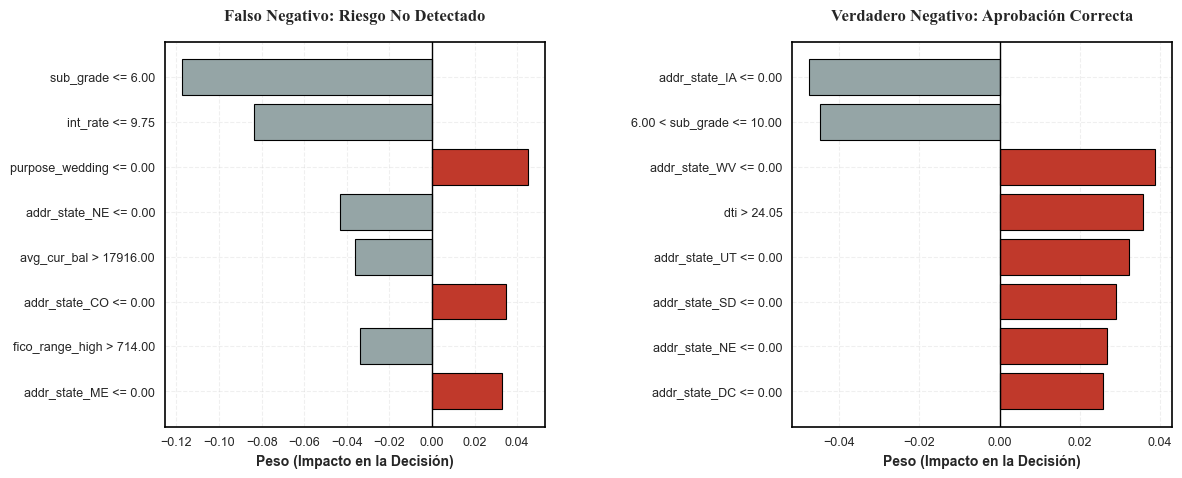

In [43]:
#| code-fold: true
#| code-summary: "Mostrar código"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

plot_dual_lime(fn_idx, tn_idx, "Riesgo No Detectado", "Aprobación Correcta")

El análisis del Falso Negativo revela un "punto ciego" crítico: el modelo tiende a la sobreconfianza cuando las variables de estatus nominal, como una tasa de interés baja (`int_rate` $\le$ 9.75) o una calificación alta (`sub_grade` $\le$ 6.00), están presentes. En términos generales, esto sugiere una vulnerabilidad sistémica donde el algoritmo asume un optimismo excesivo, permitiendo que indicadores de "prestigio" del crédito eclipsen señales de riesgo subyacentes, lo que resulta en una aprobación errónea con una confianza de hasta el 79% en perfiles que terminan en impago. Por el contrario, el Verdadero Negativo demuestra la robustez del modelo al procesar perfiles de estabilidad media-alta. En estos casos, la coherencia entre una calificación de riesgo balanceada (6.00 < `sub\_grade` $\le$ 10.00) y factores demográficos permite una aprobación justificada y precisa. En el caso general, esto confirma que el Random Forest es altamente confiable para validar deudores con fundamentos financieros sólidos, demostrando que su capacidad de discriminación es efectiva siempre que no existan distractores de "calidad aparente" que sesguen la predicción.

En general, LIME aporta la capa de transparencia que las métricas globales no pueden ofrecer. Al analizar las discrepancias locales, hemos identificado que el modelo es altamente sensible a las variables de jerarquía del préstamo (`sub_grade` y `int_rate`). Esta observación permite a los analistas de riesgo ajustar los umbrales de decisión o reentrenar el modelo penalizando más fuertemente los indicadores que el Random Forest tiende a subestimar.

## 6. Comparación de Resultados

In [17]:
#| code-fold: true
#| code-summary: "Mostrar código"

import pandas as pd
from IPython.display import display, HTML

Al analizar los tiempos de ejecución, la diferencia es sustancial. Scikit-Learn se erige como el entorno más rápido, logrando entrenar el modelo en apenas 35 segundos frente a los más de 11 minutos que requirió PySpark. Esta disparidad no es una falla de Spark, sino una consecuencia del overhead de la Máquina Virtual de Java (JVM) y la coordinación de nodos en un entorno local. Para este volumen de datos, la latencia de predicción de Scikit-Learn (inferior a un segundo) lo convierte en la opción ideal para aplicaciones que requieran una respuesta inmediata, como la aprobación de créditos en tiempo real a través de una interfaz web.

Al profundizar en las métricas de clasificación, surge una distinción estratégica. PySpark reportó una mayor Accuracy ($0.6642$) y una Precision ligeramente superior ($0.3195$), lo que indica un comportamiento más equilibrado en la clasificación general. Por otro lado, Scikit-Learn alcanzó un Recall superior ($0.6525$), lo que lo hace más efectivo para la detección preventiva de impagos. Para un banco, elegir entre ambos dependerá del apetito de riesgo: Sklearn es preferible para minimizar la pérdida de capital (atrapa un 5% más de deudores reales), mientras que Spark optimiza la relación con el cliente al ser ligeramente más preciso en sus aprobaciones.

In [18]:
matriz_spark_data = [[146187, 69035], [21245, 32408]]
matriz_sklearn_data = [[139383, 75929],[18662, 35043]]
resultados_sklearn = calcular_metricas_desde_cm(matriz_sklearn_data, "Scikit-Learn Final")
resultados_spark = calcular_metricas_desde_cm(matriz_spark_data, "PySpark Final")

In [19]:
#| code-fold: true
#| code-summary: "Mostrar código"

data_plot = {
    "Métrica": [
        "Accuracy", 
        "Precision (Clase 1)", 
        "Recall (Clase 1)", 
        "F1-Score (Clase 1)", 
        "ROC AUC", 
        "Tiempo Entrenamiento (s)", 
        "Tiempo Predicción (s)"
    ],
    "Scikit-Learn (Local)": [
        res_sk['accuracy'], res_sk['precision'], res_sk['recall'], 
        res_sk['f1'], 0.7068, 35.37, 0.9236
    ],
    "PySpark (Distribuido)": [
        res_sp['accuracy'], res_sp['precision'], res_sp['recall'], 
        res_sp['f1'], 0.6985, 677.79, 56.7569
    ]
}

df_comparativo = pd.DataFrame(data_plot)

formatters = {
    'Scikit-Learn (Local)': lambda x: "{:.4f}".format(x),
    'PySpark (Distribuido)': lambda x: "{:.4f}".format(x)
}

styled_final = df_comparativo.style.format(formatters).hide(axis='index')

styled_final = styled_final.set_table_styles([
    {'selector': '', 'props': [
        ('margin-left', 'auto'), 
        ('margin-right', 'auto'), 
        ('width', 'auto'), 
        ('border-collapse', 'collapse')
    ]},
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('background-color', '#f2f2f2'), 
        ('color', 'black'), 
        ('font-weight', 'bold'), 
        ('border', '1px solid black'), 
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('border', '1px solid black'), 
        ('padding', '6px 12px'),
        ('background-color', 'white')
    ]}
])

styled_final = styled_final.set_properties(
    subset=['Métrica'], 
    **{'text-align': 'left', 'font-weight': 'bold'}
)

display(HTML("<div style='text-align: center; width: 100%; margin-top: 20px;'>" + styled_final.to_html() + "</div>"))

Métrica,Scikit-Learn (Local),PySpark (Distribuido)
Accuracy,0.6484,0.6642
Precision (Clase 1),0.3158,0.3195
Recall (Clase 1),0.6525,0.6040
F1-Score (Clase 1),0.4256,0.4179
ROC AUC,0.7068,0.6985
Tiempo Entrenamiento (s),35.3700,677.7900
Tiempo Predicción (s),0.9236,56.7569


En términos de eficiencia operativa, la superioridad temporal de Scikit-Learn sobre PySpark es abrumadora para este volumen de datos. En la fase de entrenamiento, el entorno local demostró ser un 1,816% más rápido, logrando reducir el tiempo de procesamiento en un 94.7% respecto a la infraestructura distribuida. Esta brecha de rendimiento se vuelve aún más crítica en la etapa de inferencia (predicción), donde Scikit-Learn superó a PySpark con una velocidad un 6,045% mayor. Mientras que PySpark requirió casi un minuto para procesar el set de prueba, Scikit-Learn resolvió la misma tarea en menos de un segundo, consolidándose como la opción técnica superior para entornos de producción que exigen baja latencia y alta eficiencia computacional en datasets de escala media.

A pesar de ser más lento en este ejercicio, la utilidad de PySpark trasciende el rendimiento en una sola máquina. Su valor reside en la escalabilidad horizontal. Mientras que Scikit-Learn colapsaría ante un dataset de Terabytes por limitaciones de memoria RAM, PySpark permitiría procesar millones de registros de préstamos distribuyendo la carga en un clúster de servidores. Por tanto, PySpark no es una herramienta de "iteración rápida", sino la infraestructura de producción necesaria para una institución financiera de gran escala que maneja flujos masivos de datos históricos.

Un hallazgo fundamental en este estudio es la equivalencia en la capacidad discriminatoria de ambos entornos. Al observar las Curvas ROC, se evidencia que tanto el modelo desarrollado en Scikit-Learn ($AUC = 0.7068$) como el de PySpark ($AUC = 0.6985$) presentan un rendimiento prácticamente idéntico. En el contexto del Credit Scoring, un valor cercano a $0.70$ se considera un estándar aceptable de robustez. Esta paridad técnica es crucial, pues confirma que, independientemente de la infraestructura utilizada, la lógica de preprocesamiento, el balanceo de clases mediante pesos y la ingeniería de variables se mantuvieron íntegras y consistentes a través de las plataformas.

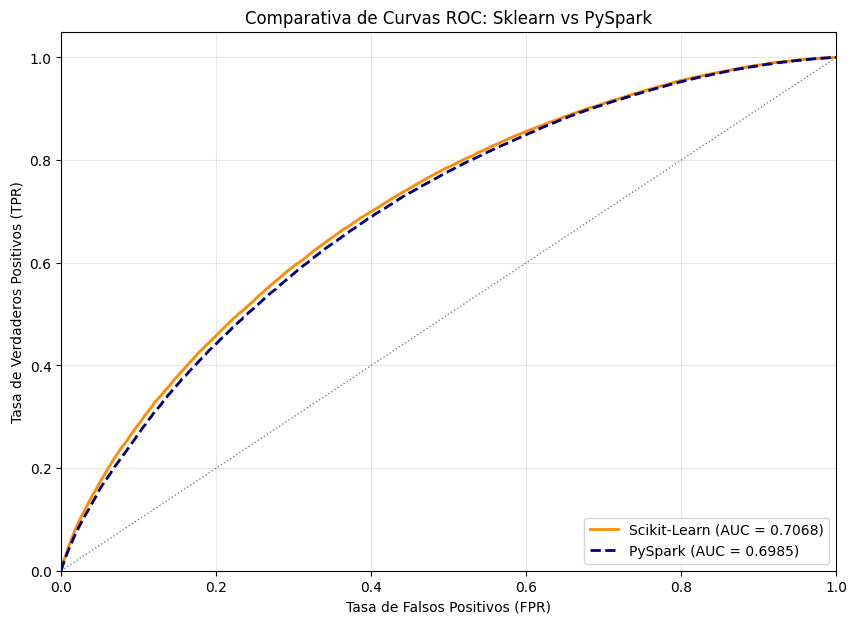

In [21]:
#| code-fold: true
#| code-summary: "Mostrar código"

plot_roc_comparison(
    y_test_sk=y_test_final,   
    y_prob_sk=y_prob,          
    spark_predictions=predictions 
)

Finalmente, la integración de LIME aporta la capa de confianza necesaria para la toma de decisiones humana. Más allá de las métricas frías, LIME nos permitió "abrir" la caja negra y entender que el modelo a veces se deja engañar por variables como el `sub_grade`, otorgando créditos a perfiles de riesgo simplemente por tener una calificación aparente alta. Esta interpretabilidad es vital no solo para mejorar el modelo, sino para cumplir con regulaciones bancarias que exigen explicar por qué se rechazó o aprobó una solicitud, transformando un algoritmo estadístico en una herramienta de auditoría transparente.